<img src="https://www.epfl.ch/about/overview/wp-content/uploads/2020/07/logo-epfl-1024x576.png" style="padding-right:10px;width:140px;float:left">

<h1 style="white-space: nowrap;">Neural Signals and Signal Processing (NX-421)</h1>
<h2>Miniproject 2 — Fall 2025</h2>

<p><strong>Project title:</strong> EMG Signals Decoding for Prosthetic and Assistive Technologies</p>
<p><strong>Group X Team Members:</strong> Changlan Chen; Davide Micheletti; Gianmarco Placì; Vincenzo Rivieccio; Pasquale Scognamiglio </p>

<hr style="clear:both">

This Notebook contains the code required to perform EMG analysis and visualization, feature extraction, classification of movements, assessment of classification, feature selection within and across subjects, and regression for joint angles.

# Part 1: Single subject classification (subject 2)

In this first part, the aim is to use the [NinaPro Dataset 1](https://ninapro.hevs.ch/instructions/DB1.html) to visualize and preprocess the data from Subject 2 (only using the first exercise set:
S2_A1_E1 with 12 actions), so to extract relevant features and build a reliable model that could predict the action of the sole Subject 2 based on the EMG signals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #sets the matplotlib style to seaborn style

from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch
import pandas as pd
import math

np.random.seed(42)

In [2]:
# Run the following code having the .ipynb file in the same folder as the 'data' folder, containing the s1, s2... s27 subject folders all having the .mat files inside them
# For this first part, we are only interested in loading the data of subject 2, S2_A1_E1.mat
emg_data_S2 = loadmat('data/s2/S2_A1_E1.mat')
# analyze the structure of the loaded .mat file
emg_data_S2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'subject', 'exercise', 'stimulus', 'emg', 'glove', 'restimulus', 'repetition', 'rerepetition'])

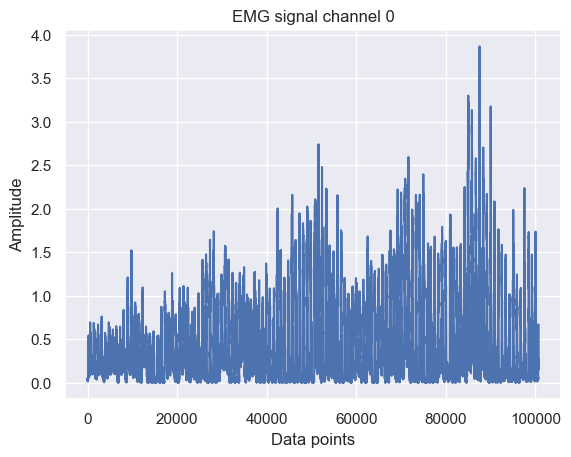

In [3]:
# Extract the relevant fields from the loaded .mat file
subject_number = emg_data_S2["subject"].item()
exercise_number = emg_data_S2["exercise"].item()

# stimulus, restimulus, repetition, rerepetition
stimulus_labels_S2 = emg_data_S2["stimulus"].squeeze().astype(int)
restimulus_S2 = emg_data_S2["restimulus"].squeeze().astype(int)
repetition_S2 = emg_data_S2["repetition"].squeeze().astype(int)
rerepetition_S2 = emg_data_S2["rerepetition"].squeeze().astype(int)

# List of unique stimulus and restimulus labels
stimulus_labels_set = np.sort(np.unique(stimulus_labels_S2)).astype(int).tolist()
restimulus_labels_set = np.sort(np.unique(restimulus_S2)).astype(int).tolist()
repetitions_labels_set = np.sort(np.unique(repetition_S2)).astype(int).tolist()
rerepetitions_labels_set = np.sort(np.unique(rerepetition_S2)).astype(int).tolist()

# EMG data
emg_S2 = emg_data_S2["emg"] #shape (n_samples, n_channels)
n_samples = emg_S2.shape[0]
t = np.arange(n_samples)
n_channels = emg_S2.shape[1]

# glove
glove = emg_data_S2["glove"]
n_sensors_glove = glove.shape[1]

# Plot the first channel to get a sense of the data
EMG_channel = 0 # or choose another channel index
fig, ax = plt.subplots()
ax.plot(emg_S2[:, EMG_channel])
ax.set_title(f"EMG signal channel {EMG_channel}")
ax.set_xlabel("Data points")
ax.set_ylabel("Amplitude")
plt.show()

The first exercise set being used only contains 12 actions being performed. Overall, the summation of all the conditions should lead to a number of movements equal to 52 (all repeated 10 times), but we are only going to focus on 12 stimulus types contained in the first exercise session. Here's a visualization of how the signals for the 12 different stimulus look across the whole registration:

**Plot of the time series with the restimulus segment marked in the whole time series (visualization of the different restimulus in the whole exercise, with their different rerepetition blocks)**

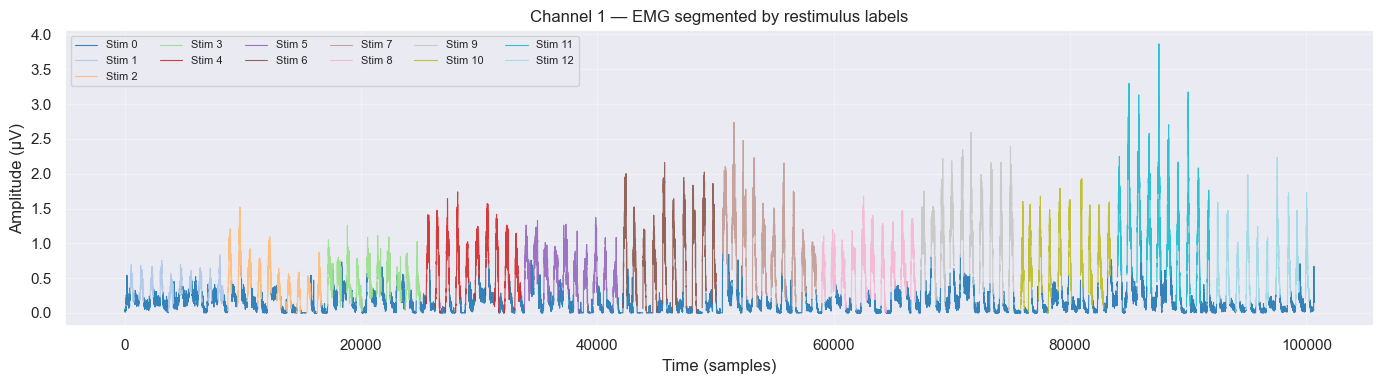

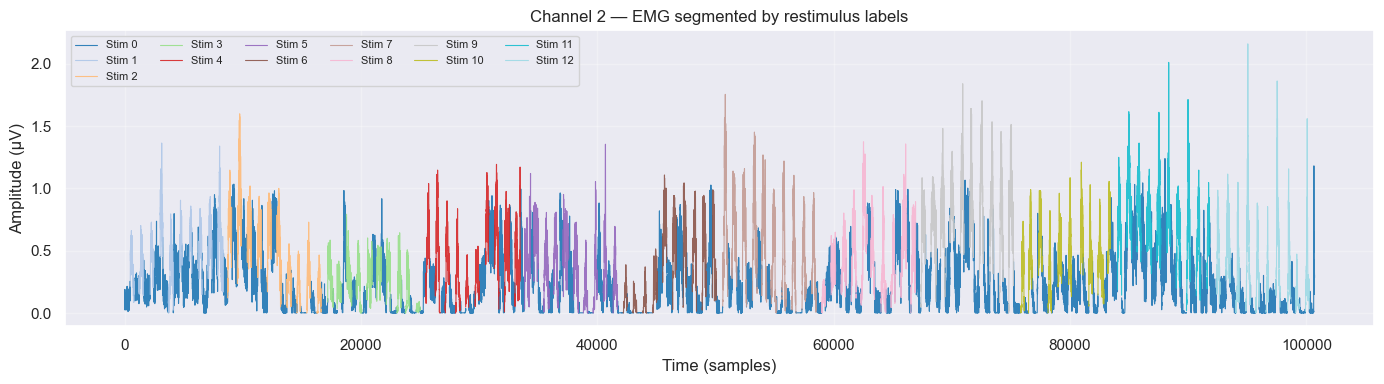

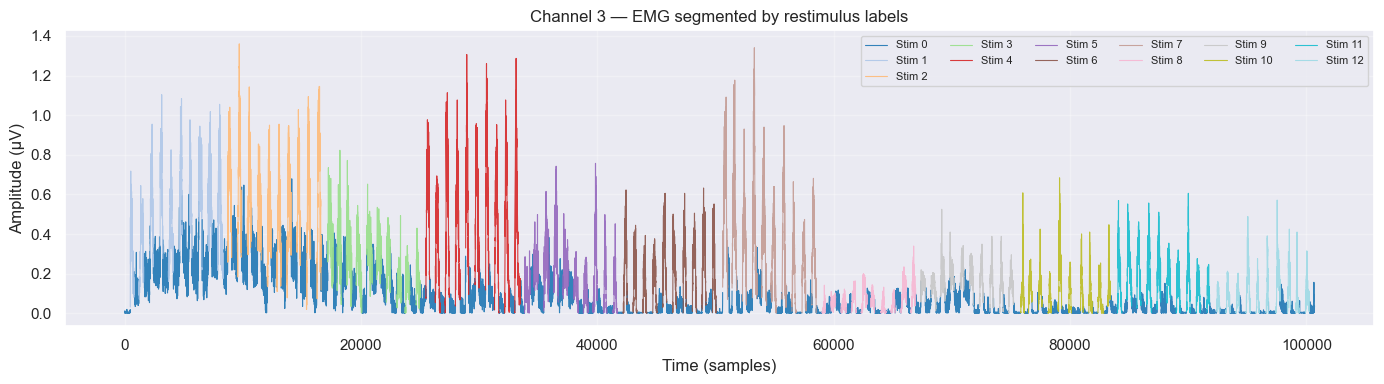

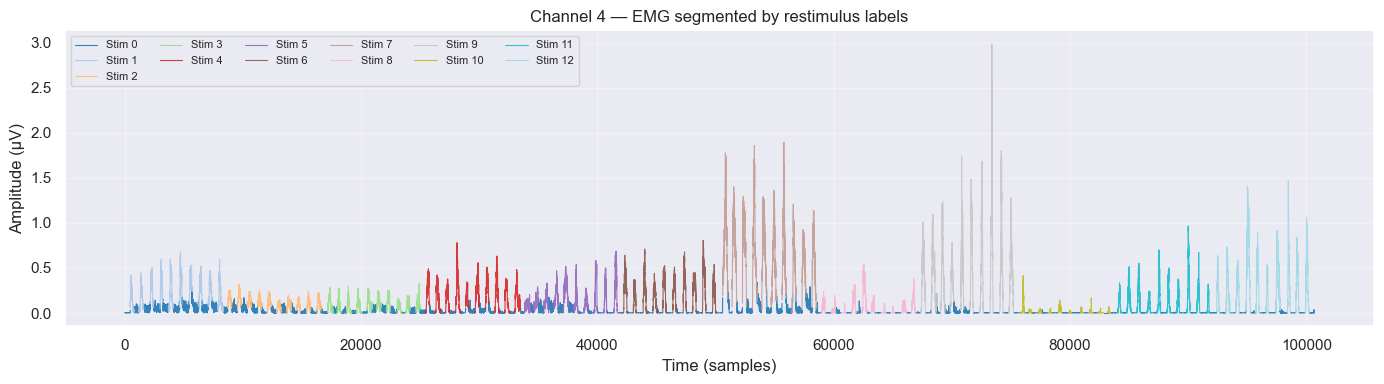

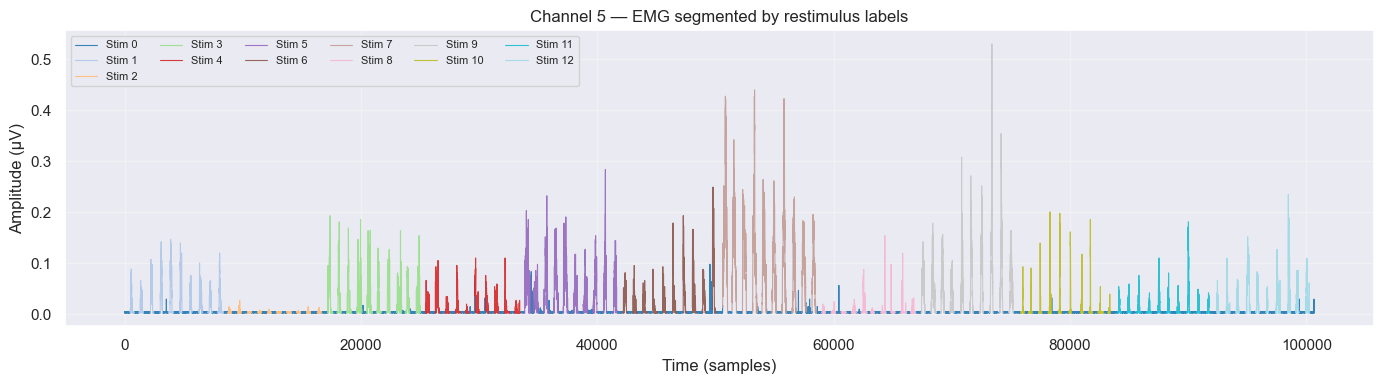

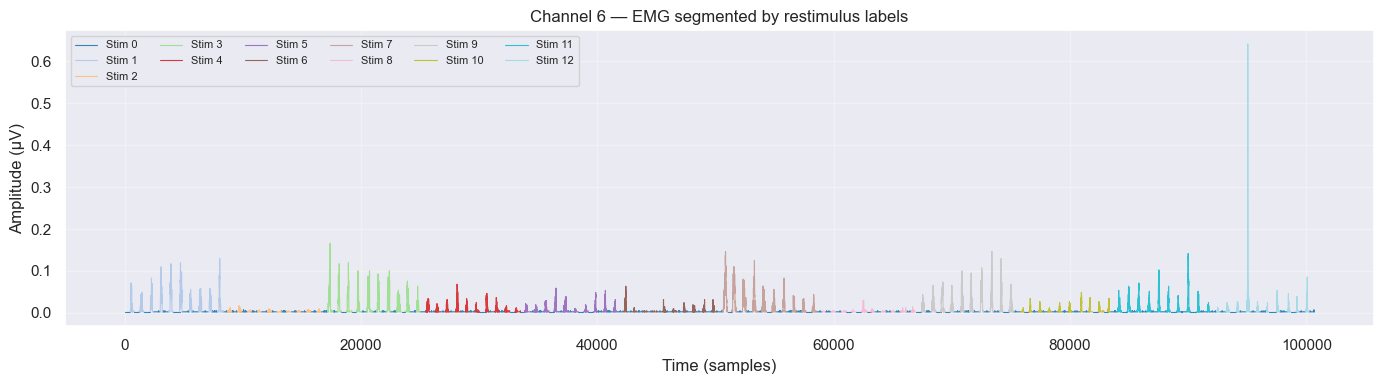

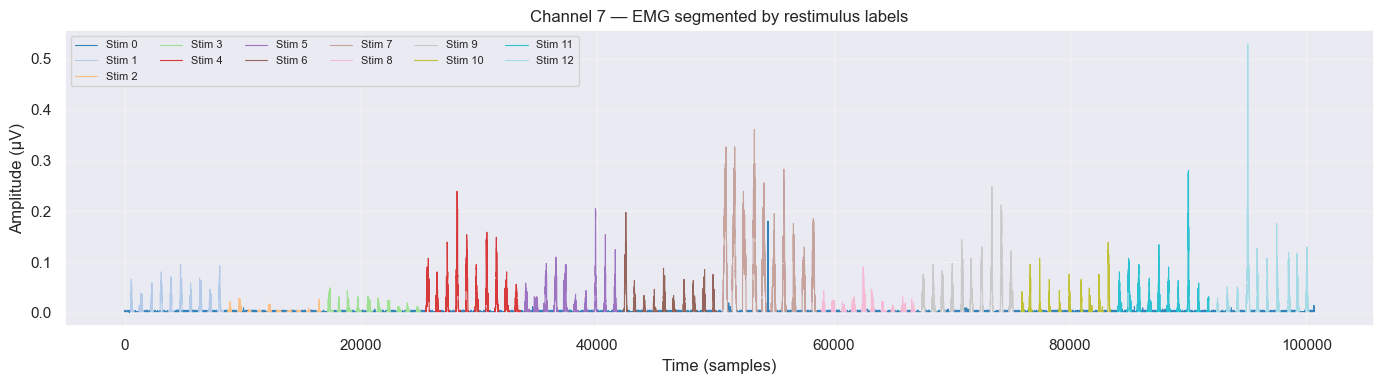

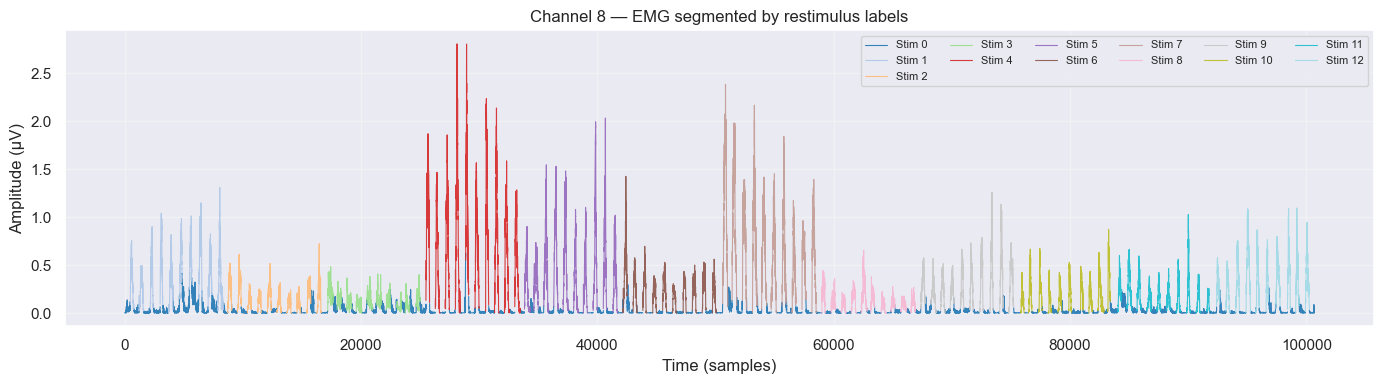

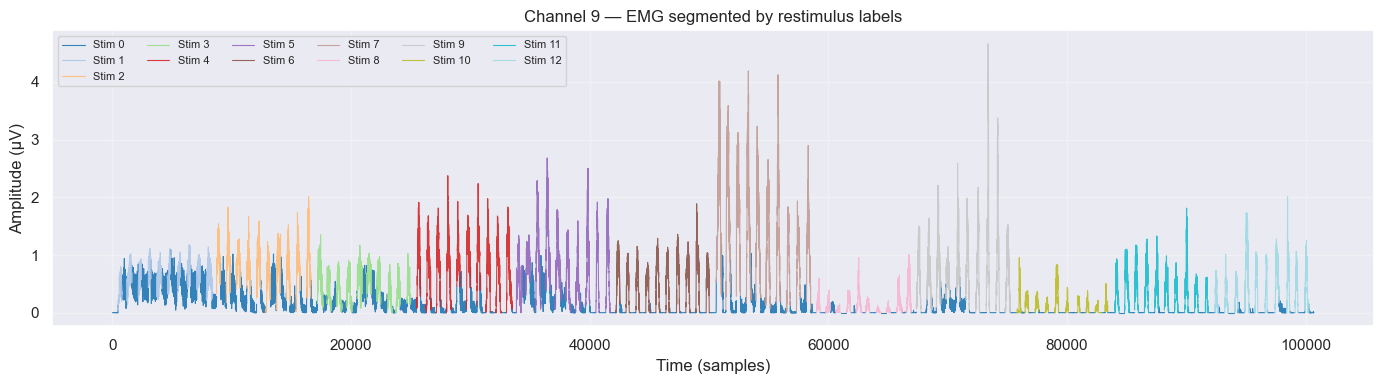

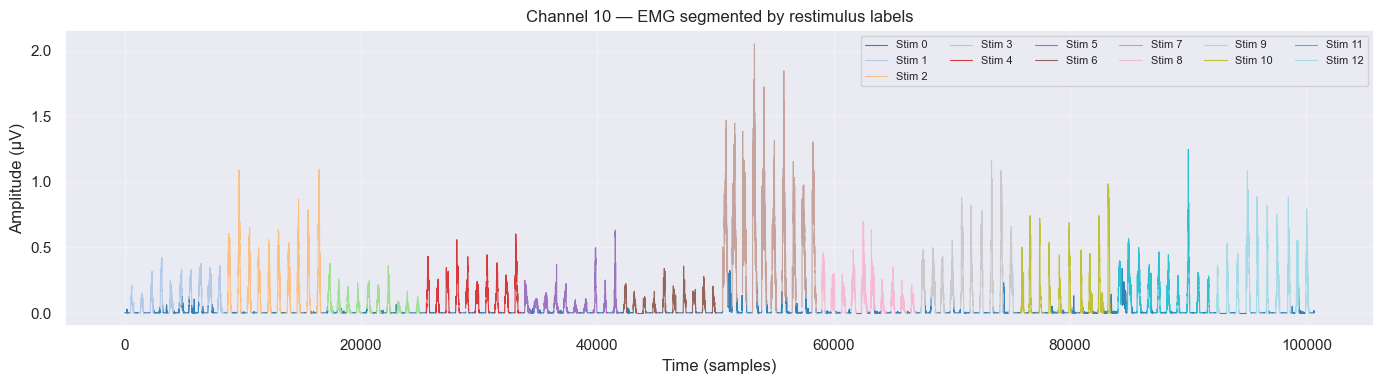

In [4]:
# Create color map for the diverse stimulus conditions
colors = plt.cm.tab20(np.linspace(0, 1, len(stimulus_labels_set)))
color_map = {label: colors[i] for i, label in enumerate(stimulus_labels_set)}

for ch in range(n_channels):
    fig, ax = plt.subplots(figsize=(14, 4))

    for label in stimulus_labels_set:

        mask = (restimulus_S2 == label)
        idx = np.where(mask)[0]

        if len(idx) == 0:
            continue
        # Find breaks in the contiguous indices
        breaks = np.where(np.diff(idx) != 1)[0]
        # Start and end indices of each contiguous block
        starts = np.r_[idx[0], idx[breaks + 1]]
        ends   = np.r_[idx[breaks], idx[-1]] + 1

        # Plot each block of restimulus
        for start, end in zip(starts, ends):
            ax.plot(
                t[start:end],
                emg_S2[start:end, ch],
                color=color_map[label],
                linewidth=0.8,
                alpha=0.9,
                label=f"Stim {label}" if start == starts[0] else None
            )

    ax.set_title(f"Channel {ch+1} — EMG segmented by restimulus labels")
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Amplitude (µV)")
    ax.grid(True, alpha=0.3)

    # legend
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8, ncol=6)

    plt.tight_layout()
    plt.show()

**Plot of the separate rerepetition conditions divided by restimulus**

This following plot is meant to visualize if, among the different rerepetitions of the same restimulus, there are rerepetitions that look quite different and should thus probably be excluded:

Plotting STIMULUS 1


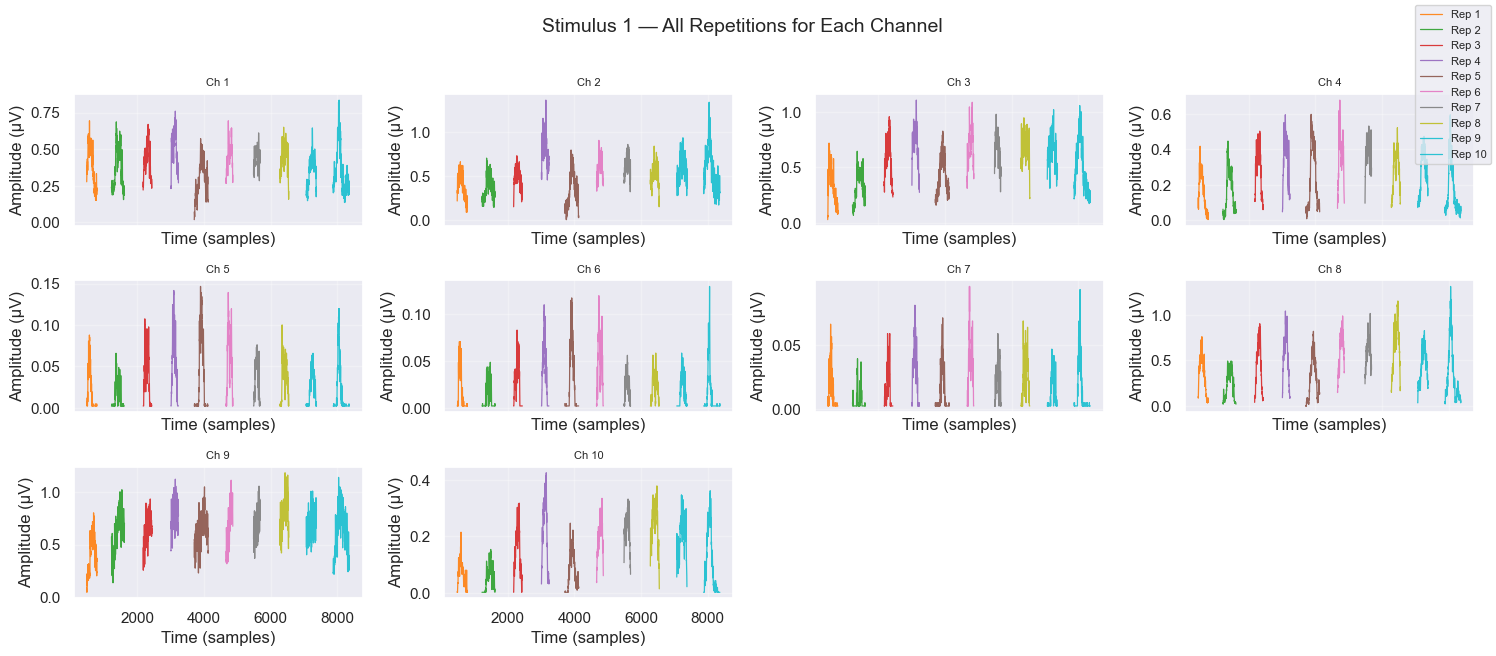

Plotting STIMULUS 2


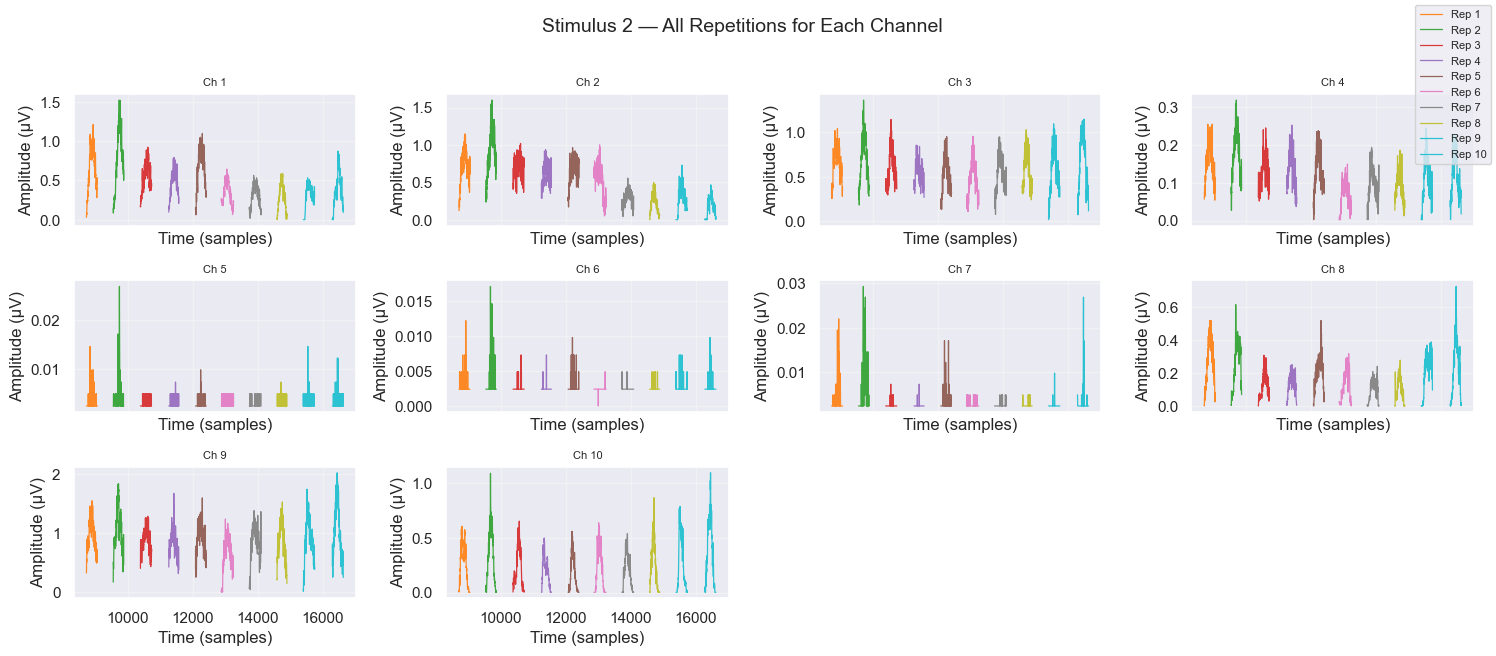

Plotting STIMULUS 3


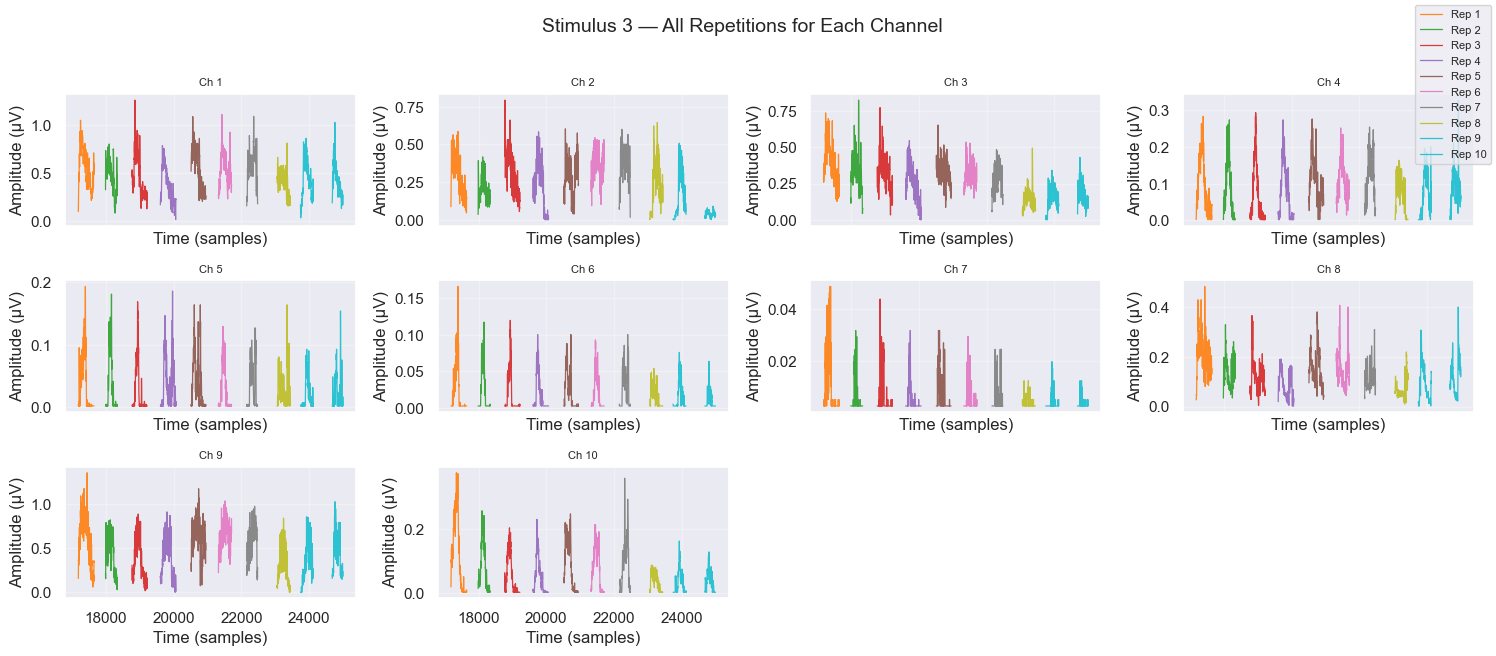

Plotting STIMULUS 4


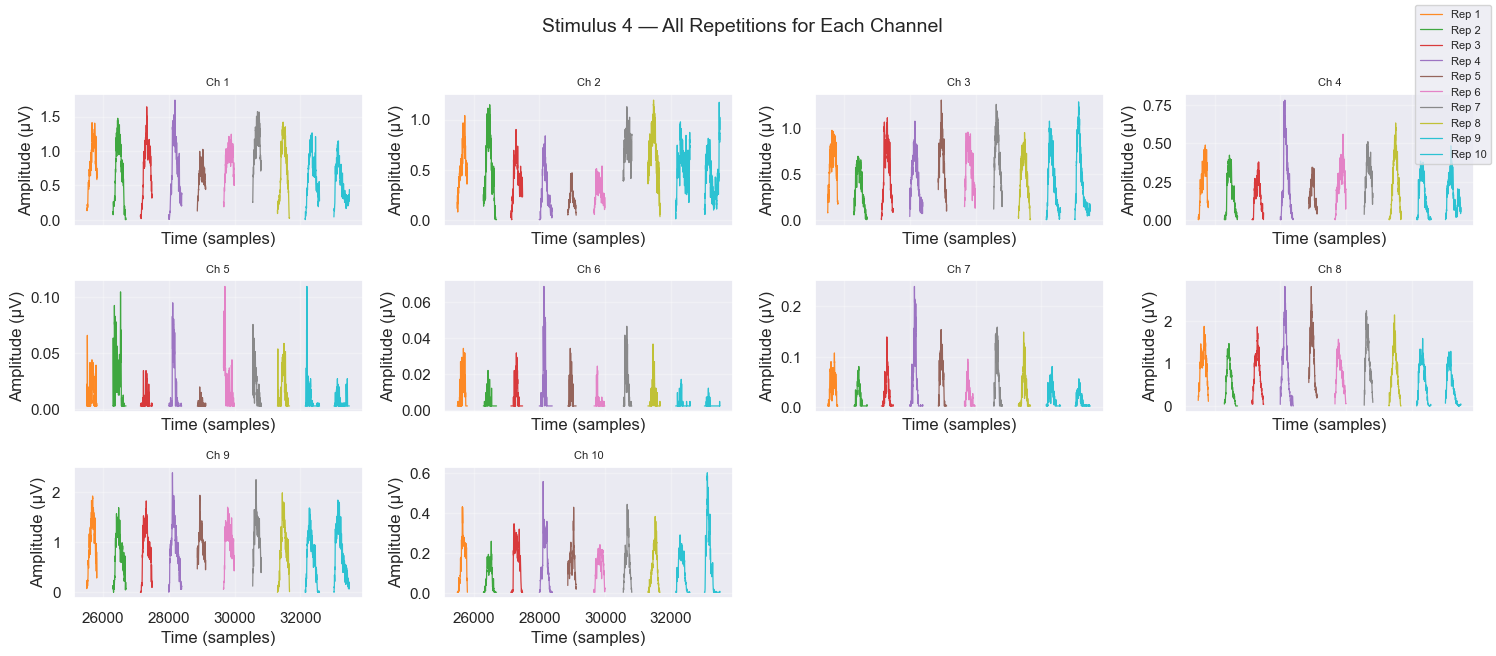

Plotting STIMULUS 5


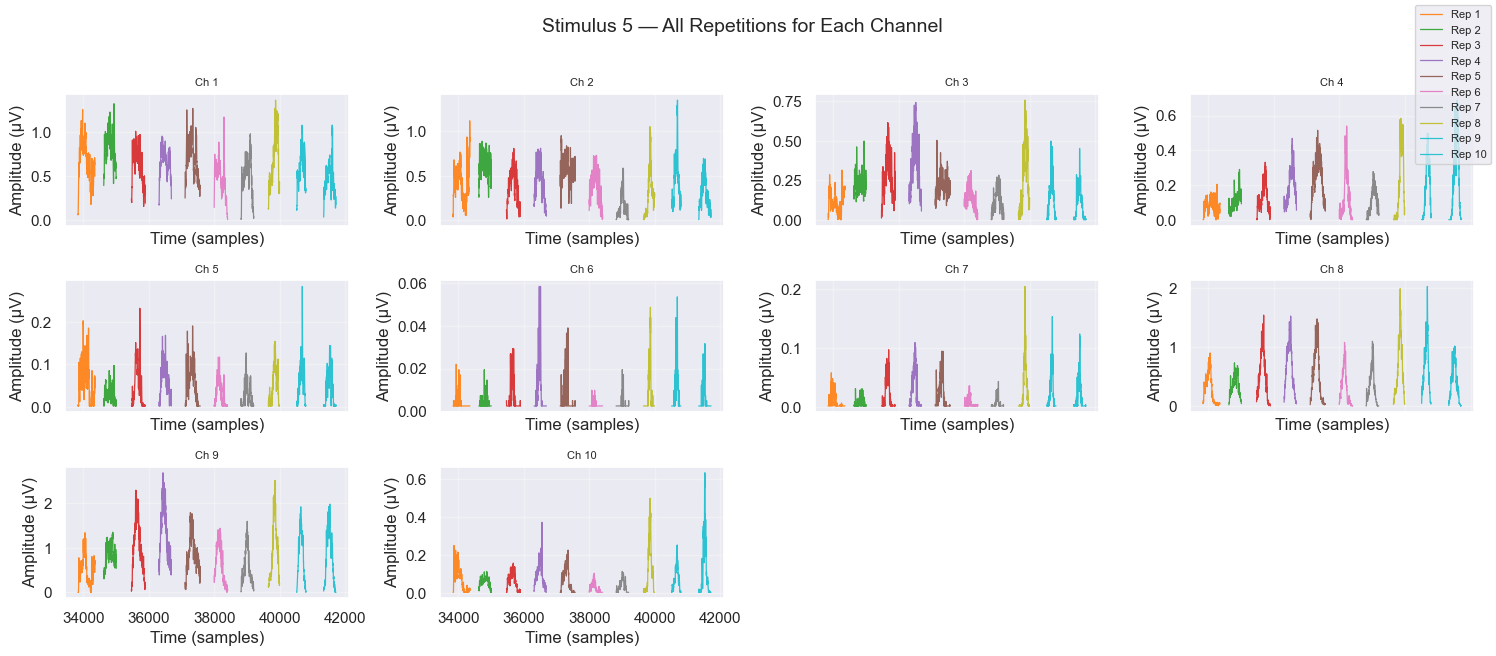

Plotting STIMULUS 6


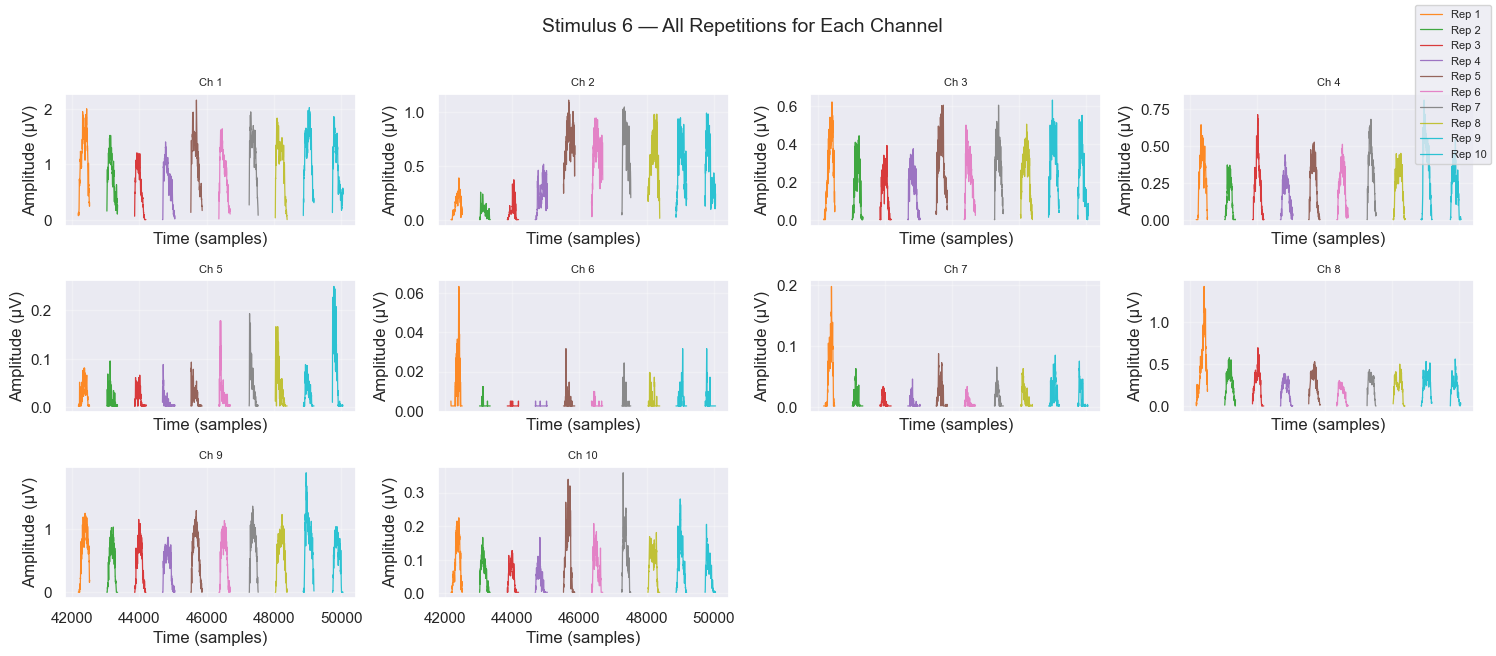

Plotting STIMULUS 7


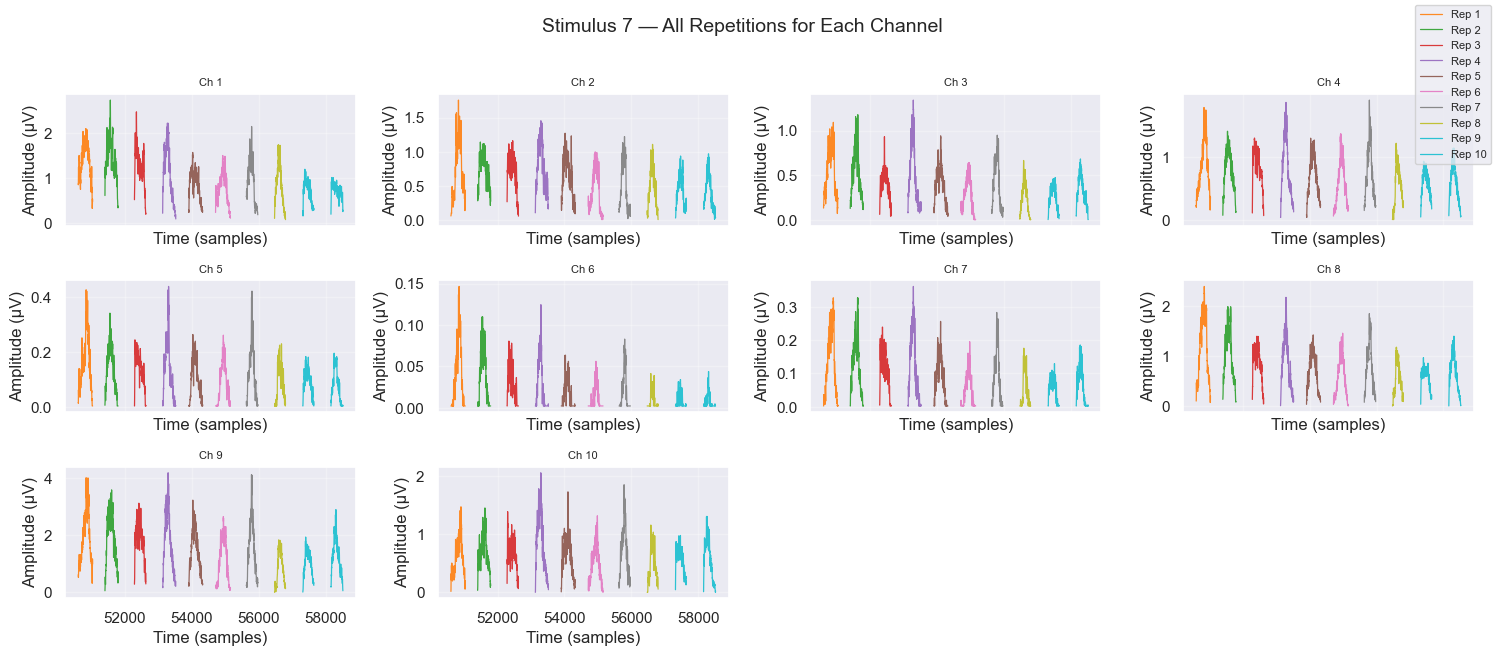

Plotting STIMULUS 8


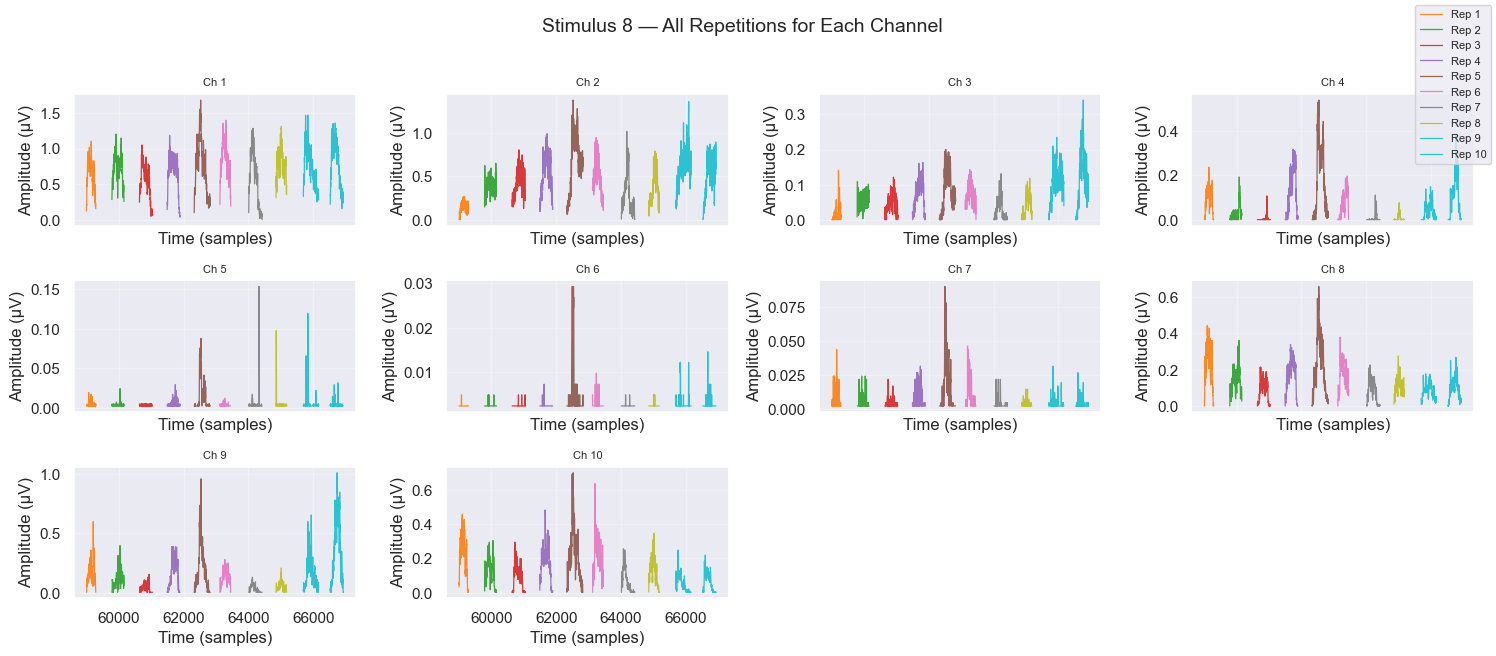

Plotting STIMULUS 9


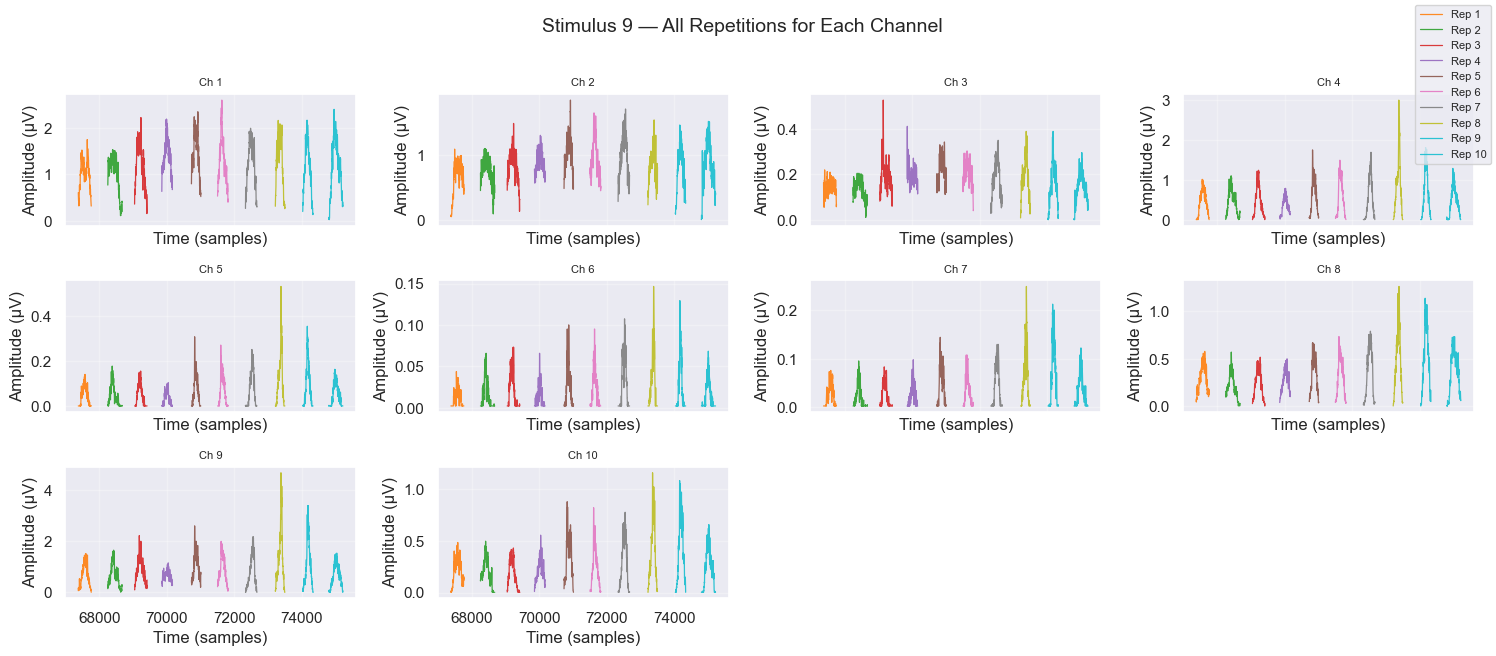

Plotting STIMULUS 10


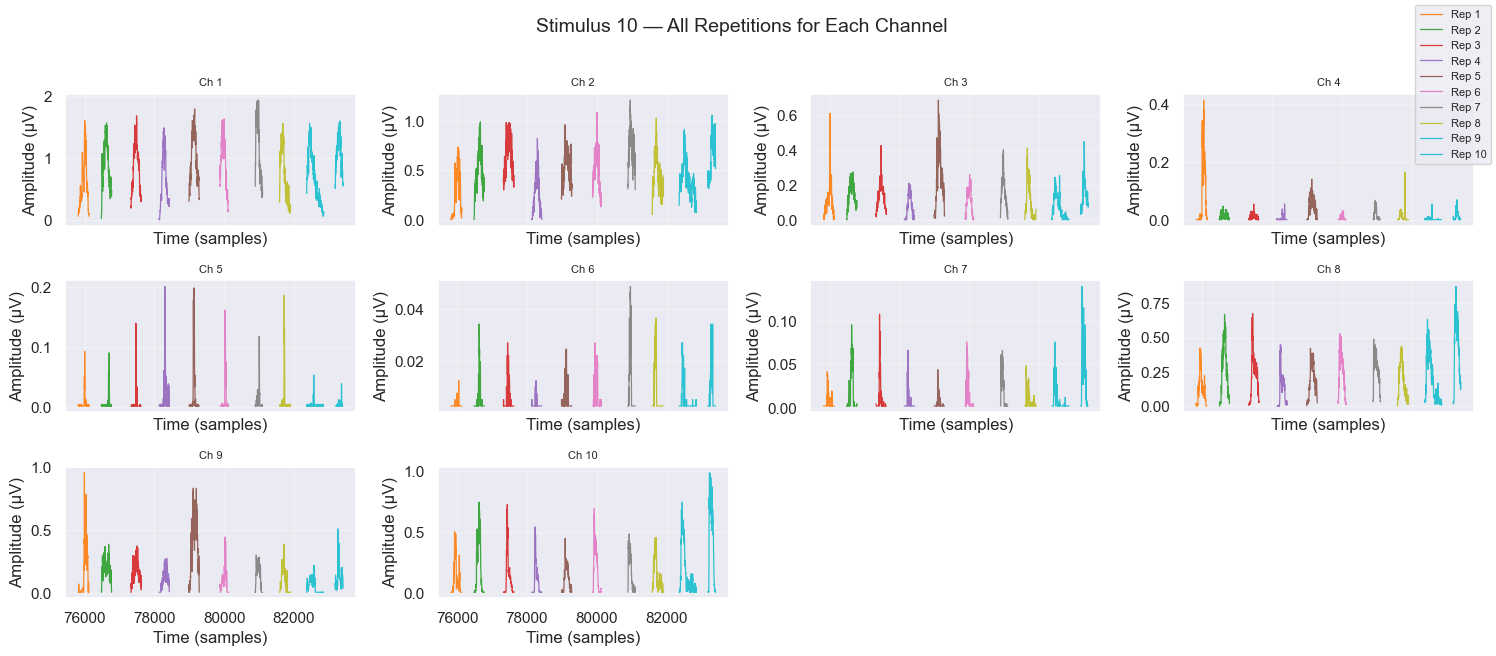

Plotting STIMULUS 11


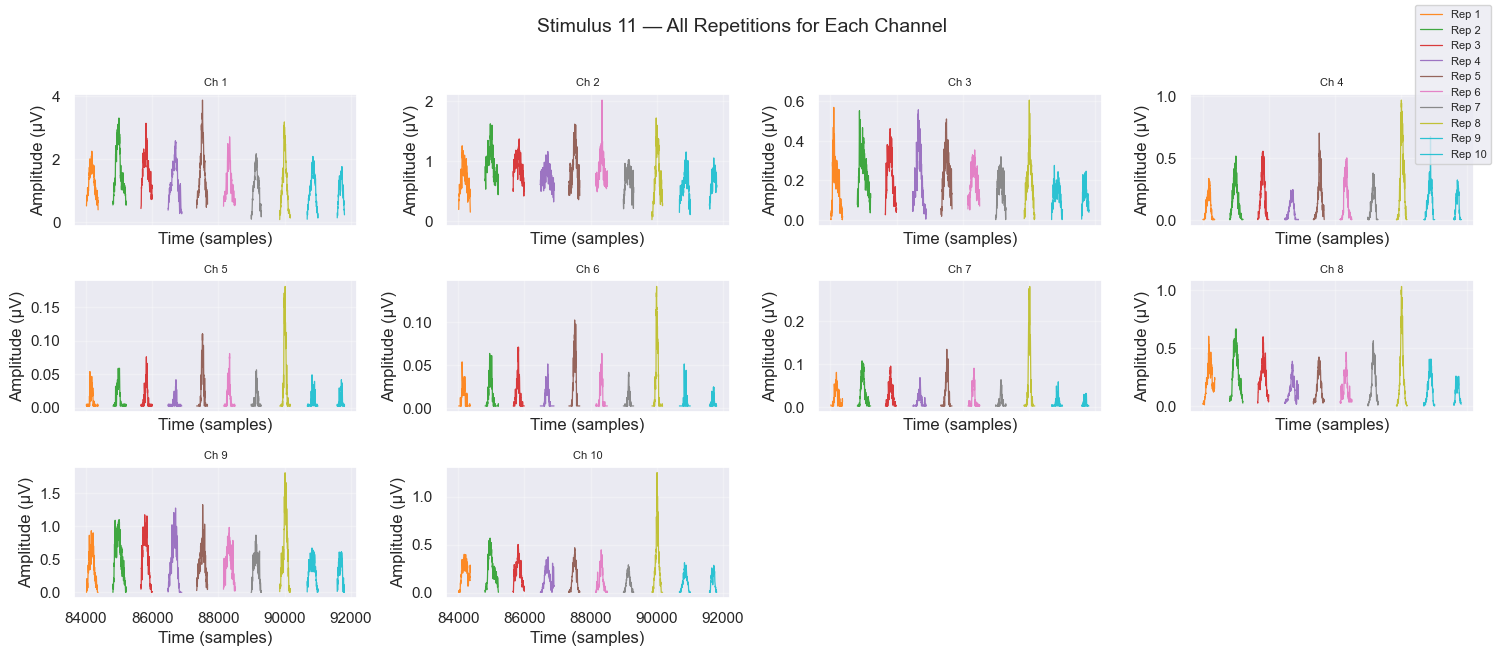

Plotting STIMULUS 12


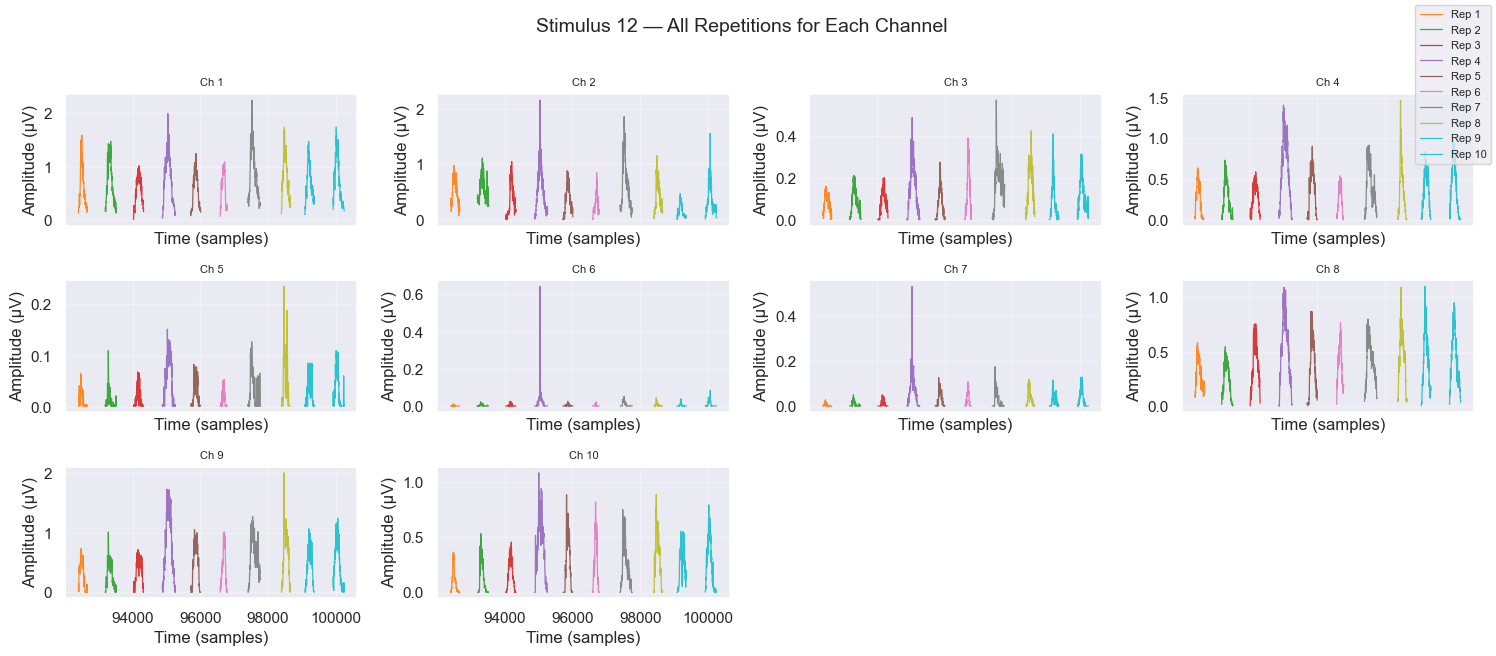

In [5]:
# Choose a set of colors for repetitions
rep_colors = plt.cm.tab10(np.linspace(0, 1, len(rerepetitions_labels_set)))   # all 10 reps

for label in stimulus_labels_set:
    if label == 0:
        continue  # skip stimulus 0 (= rest condition) for trial inspection

    print(f"Plotting STIMULUS {label}")

    reps = rerepetitions_labels_set

    # Grid of channels
    n_cols = 4
    n_rows = int(np.ceil(n_channels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.2 * n_rows), sharex=True)
    axes = axes.flatten()

    for ch in range(n_channels):
        ax = axes[ch]

        for i, rep in enumerate(reps):
            mask = (restimulus_S2 == label) & (rerepetition_S2 == rep)
            idx = np.where(mask)[0]
            if len(idx) == 0:
                continue

            start, end = idx[0], idx[-1] + 1

            ax.plot(
                t[start:end],
                emg_S2[start:end, ch],
                color=rep_colors[i % len(rep_colors)],
                linewidth=0.9,
                alpha=0.9,
                label=f"Rep {rep}" if ch == 0 else None
            )

        ax.set_title(f"Ch {ch+1}", fontsize=8)
        ax.set_xlabel("Time (samples)")
        ax.set_ylabel("Amplitude (µV)")
        ax.grid(True, alpha=0.3)

    # remove empty panels
    for ax in axes[n_channels:]:
        ax.axis("off")

    # Legend only on top-right subplot
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper right", fontsize=8)

    fig.suptitle(f"Stimulus {label} — All Repetitions for Each Channel", fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

**EMG data preprocessing**

These sensors already include internal amplification, rectification and low-pass filtering performed in hardware, and the output is natively sampled at 100 Hz. For this reason, no additional band-pass or notch filtering is required. However, applying a light high-pass filter (1 Hz) is useful to remove the baseline drift while preserving the usable content of the signal. We don't apply a moving average because the rectified version of the EMG already gives a good idea of patterns of muscle contraction, and this operation would likely cause a reduction in the complexity captured by the features to be extracted.

In [6]:
def highpass_filter(emg, fs=100, cutoff=1.0, order=4):
    """
    Apply a light high-pass filter to remove DC offset and slow drifts
    in NinaPro DB1 EMG signals.

    Parameters
    ----------
    emg : array (N_samples, N_channels)
        Raw EMG signal after DC removal.
    fs : int
        Sampling frequency. For DB1, fs = 100 Hz.
    cutoff : float
        High-pass cutoff frequency. 1 Hz is recommended.
    order : int
        Order of the Butterworth filter.

    Returns
    -------
    emg_hp : array
        High-pass filtered EMG signal.
    """

    sos = butter(order, cutoff, btype='highpass', fs=fs, output='sos')
    emg_hp = sosfiltfilt(sos, emg, axis=0)
    return emg_hp

In [7]:


# sampling frequency (from NinaPro DB2 documentation)
fs = 100
# remove DC offset
emg_dc = emg_S2 - emg_S2.mean(axis=0)
# apply a light high-pass filter at 1 Hz
emg_hp = highpass_filter(emg_dc, fs, cutoff=1.0)

Plotting STIMULUS 1


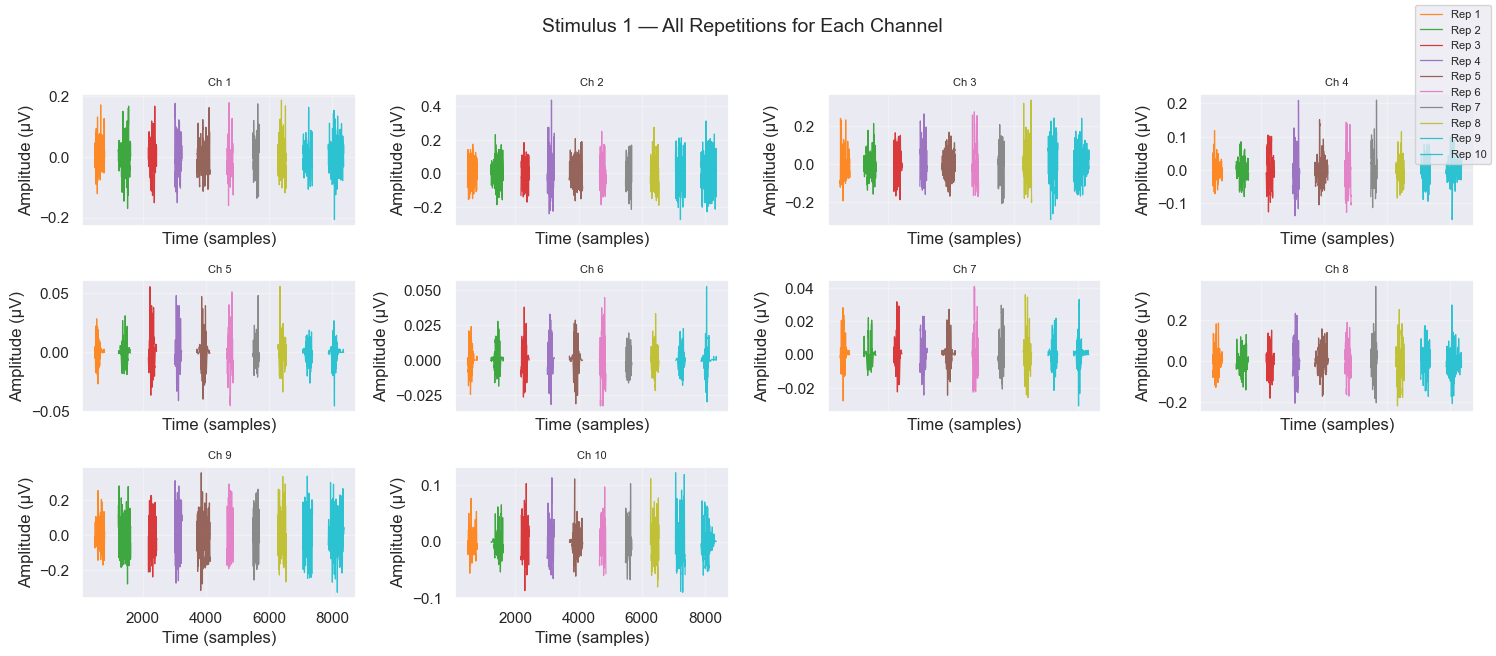

Plotting STIMULUS 2


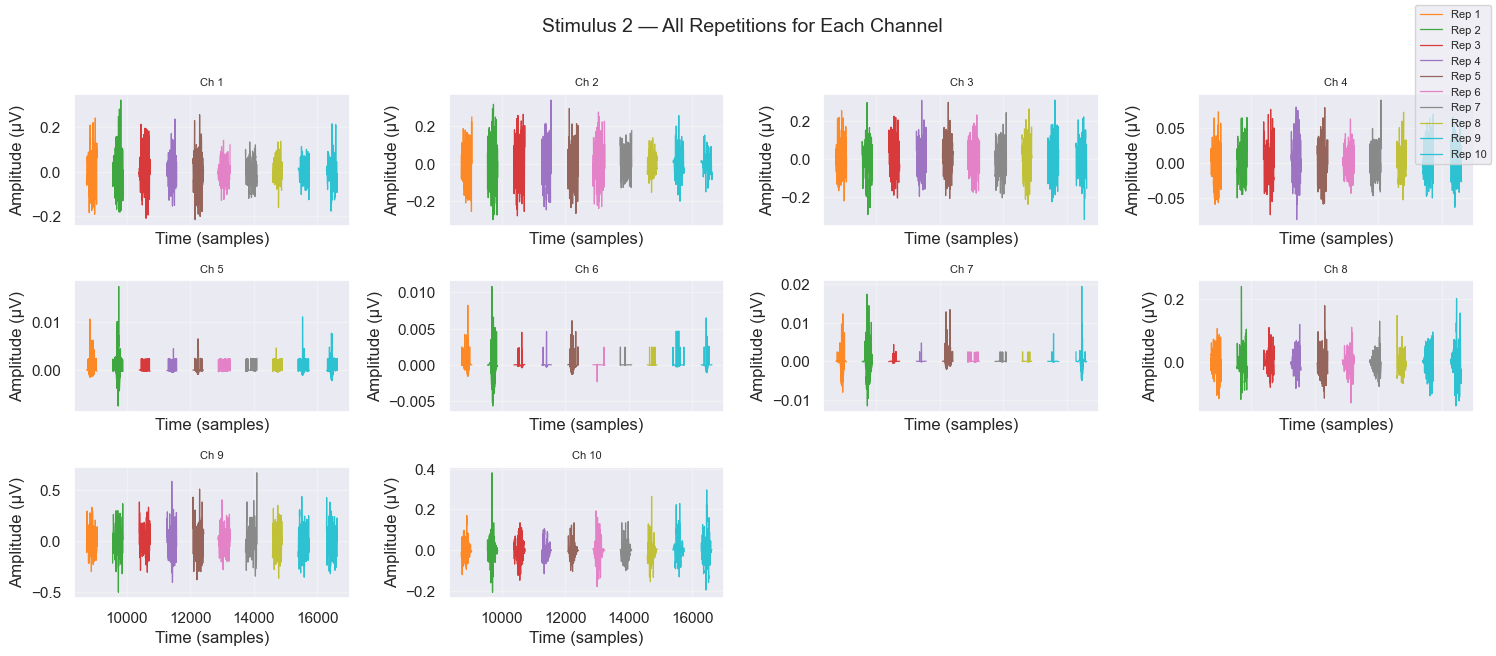

Plotting STIMULUS 3


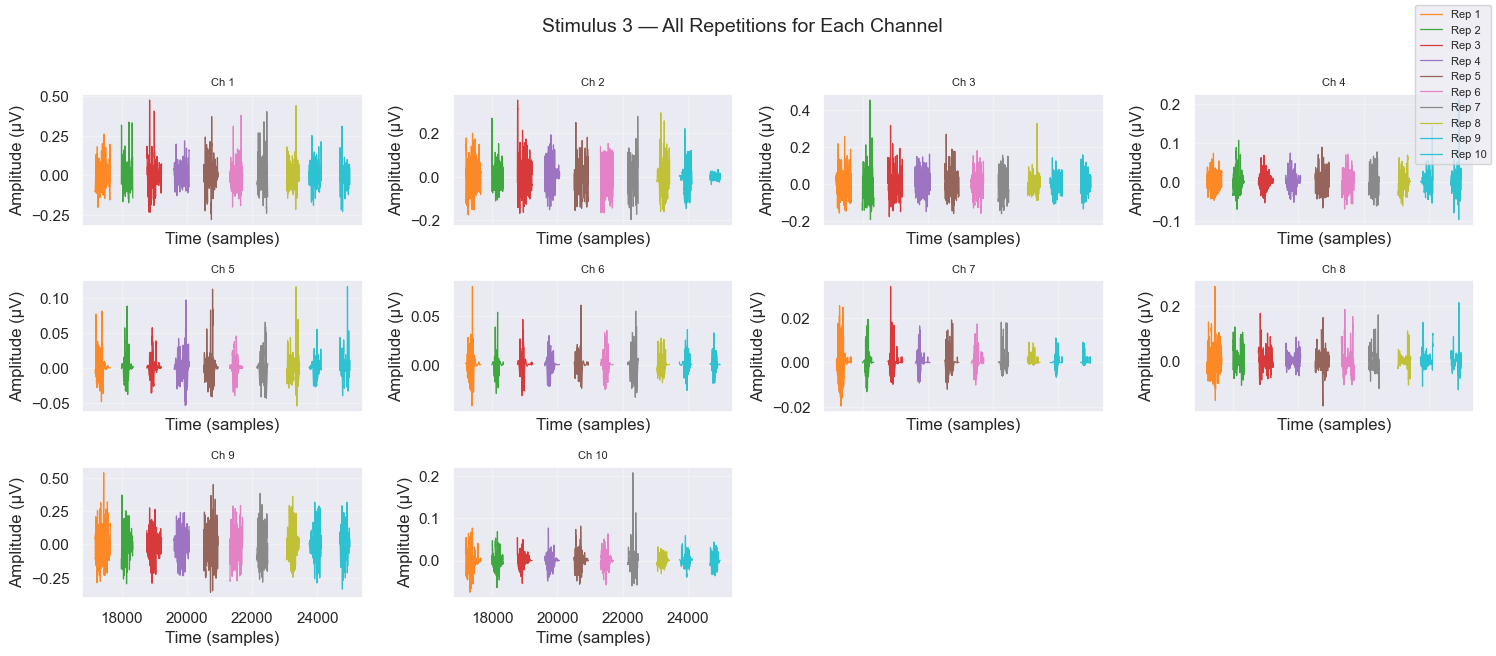

Plotting STIMULUS 4


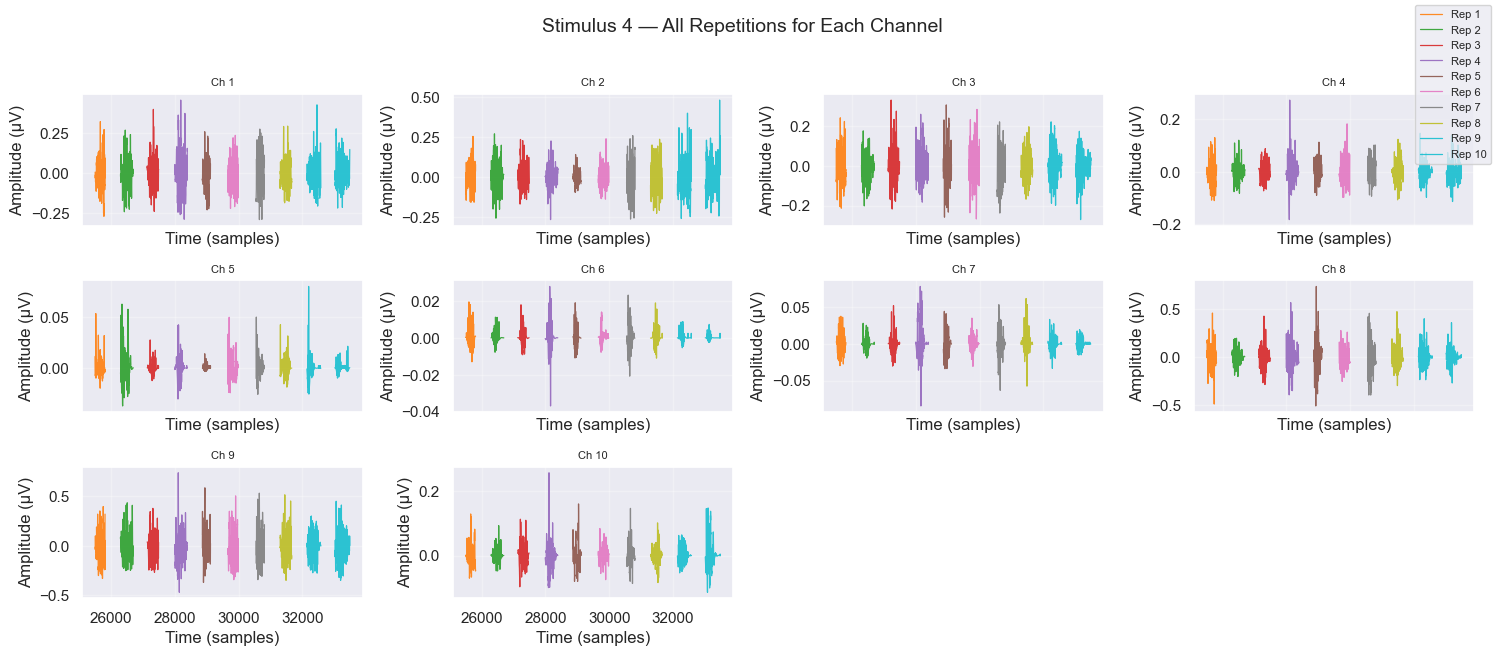

Plotting STIMULUS 5


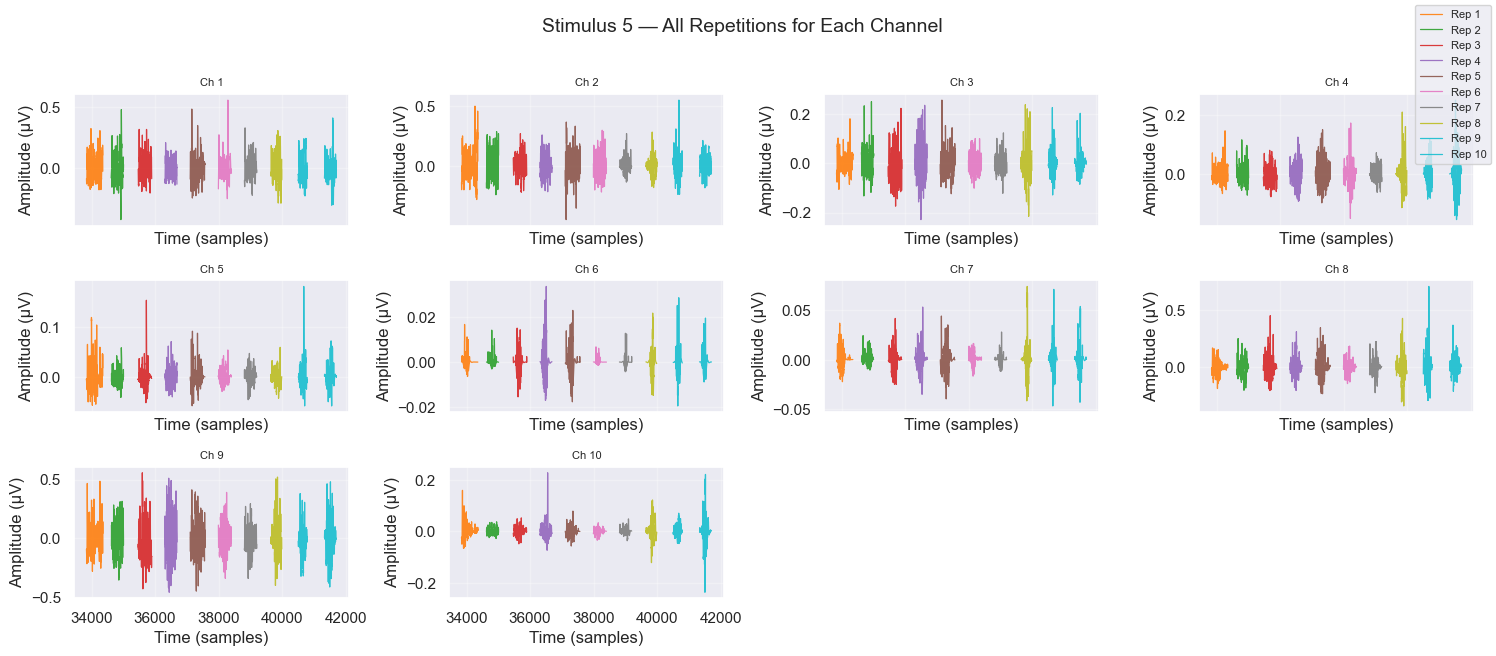

Plotting STIMULUS 6


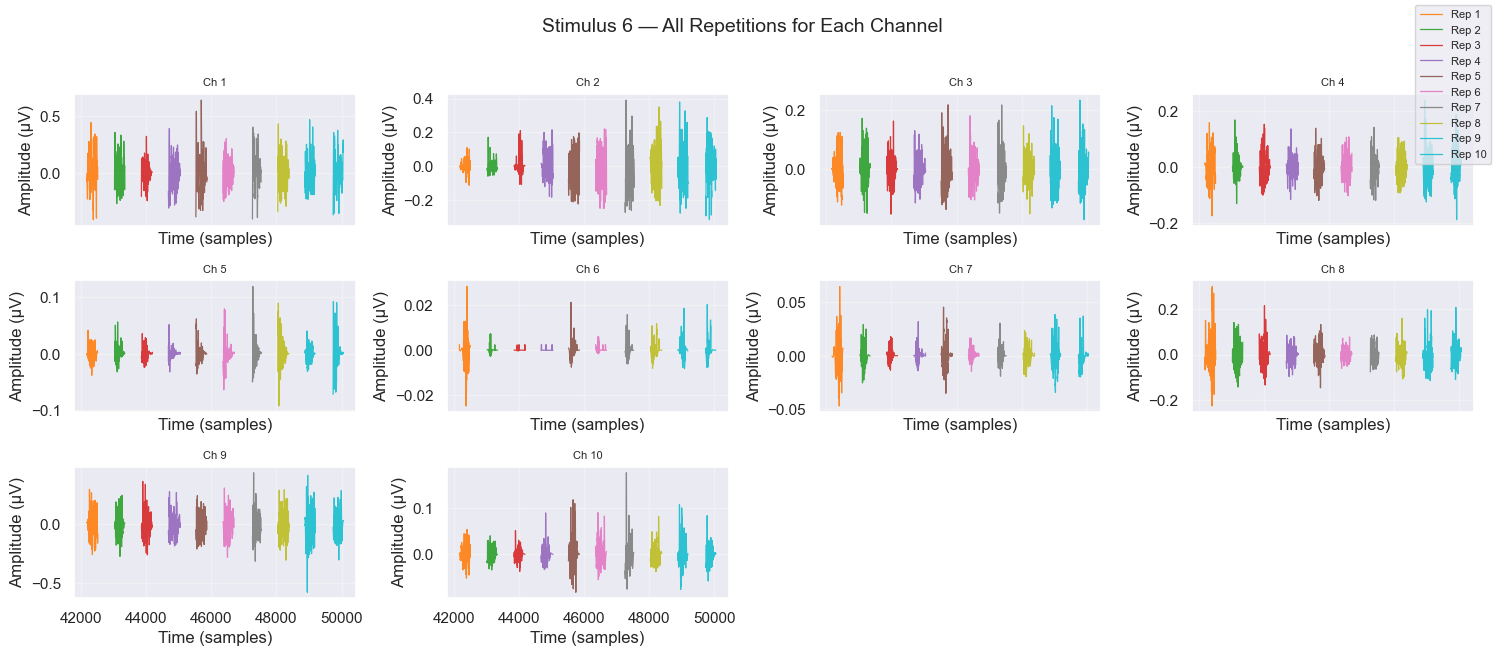

Plotting STIMULUS 7


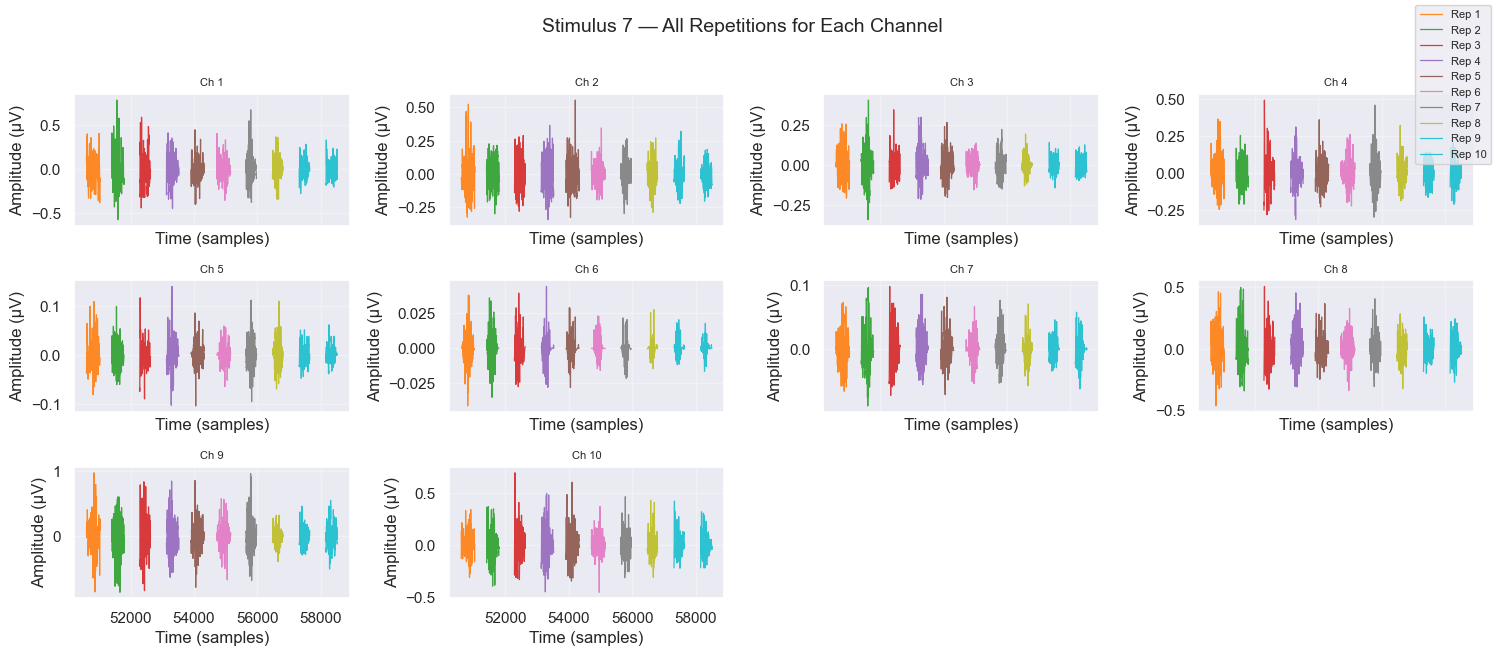

Plotting STIMULUS 8


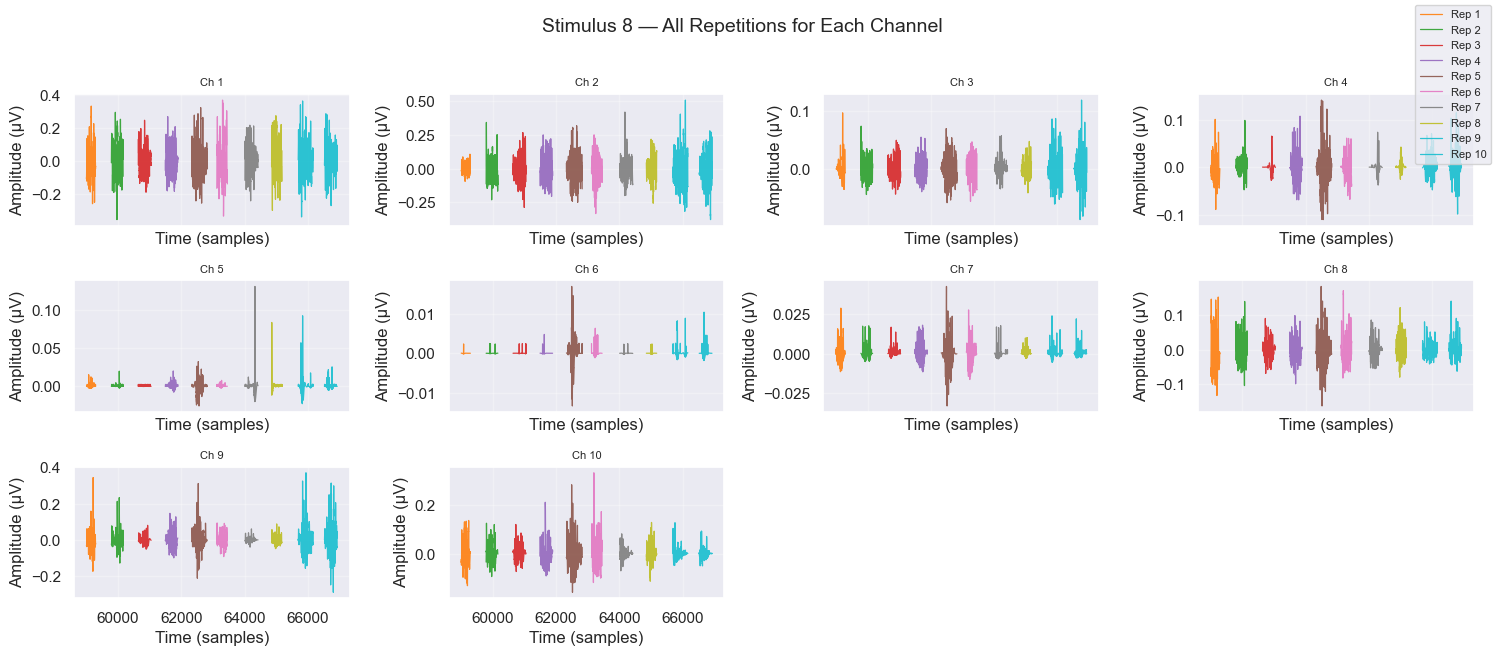

Plotting STIMULUS 9


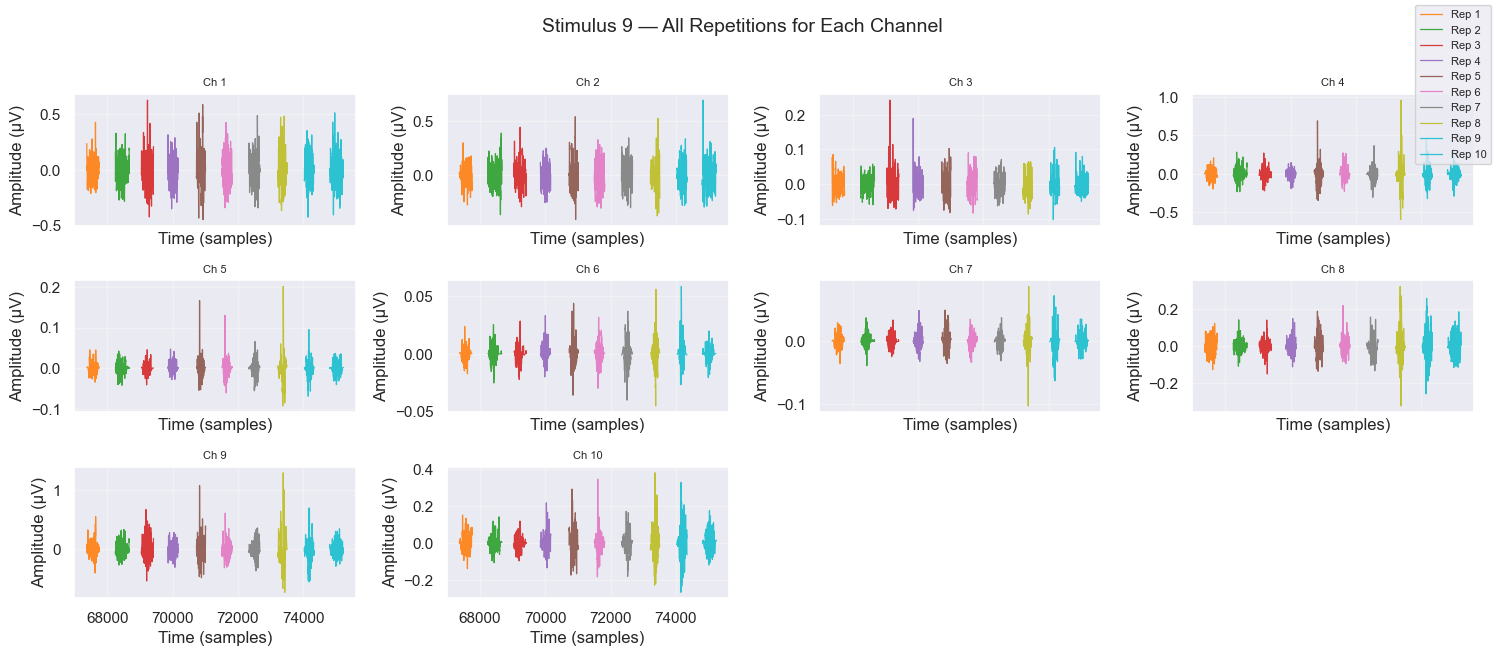

Plotting STIMULUS 10


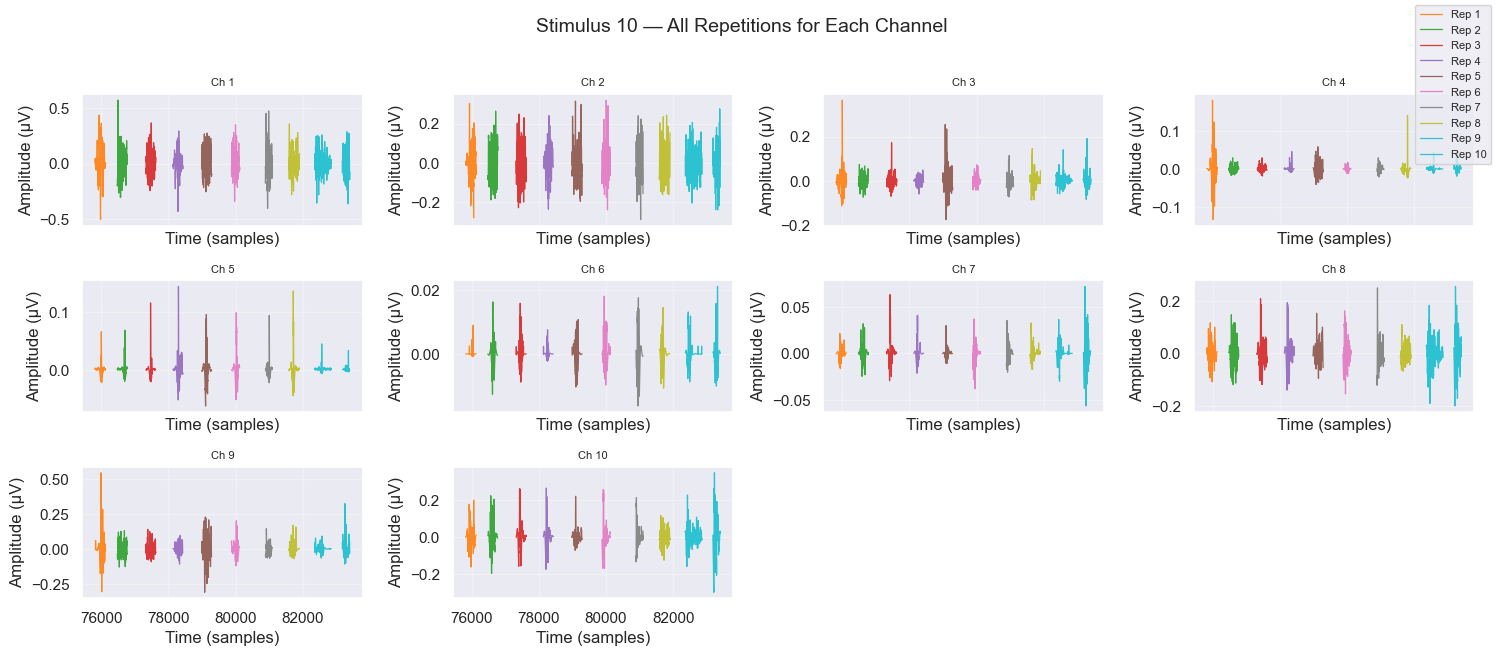

Plotting STIMULUS 11


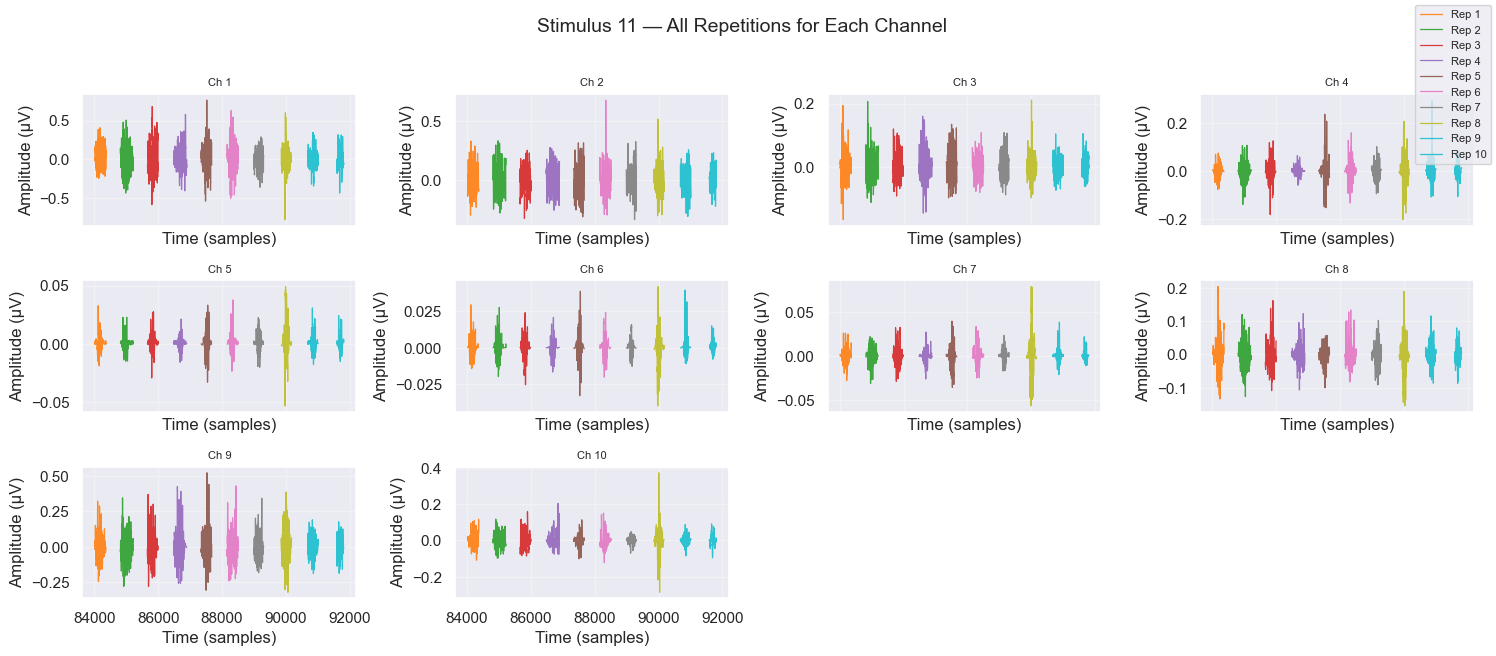

Plotting STIMULUS 12


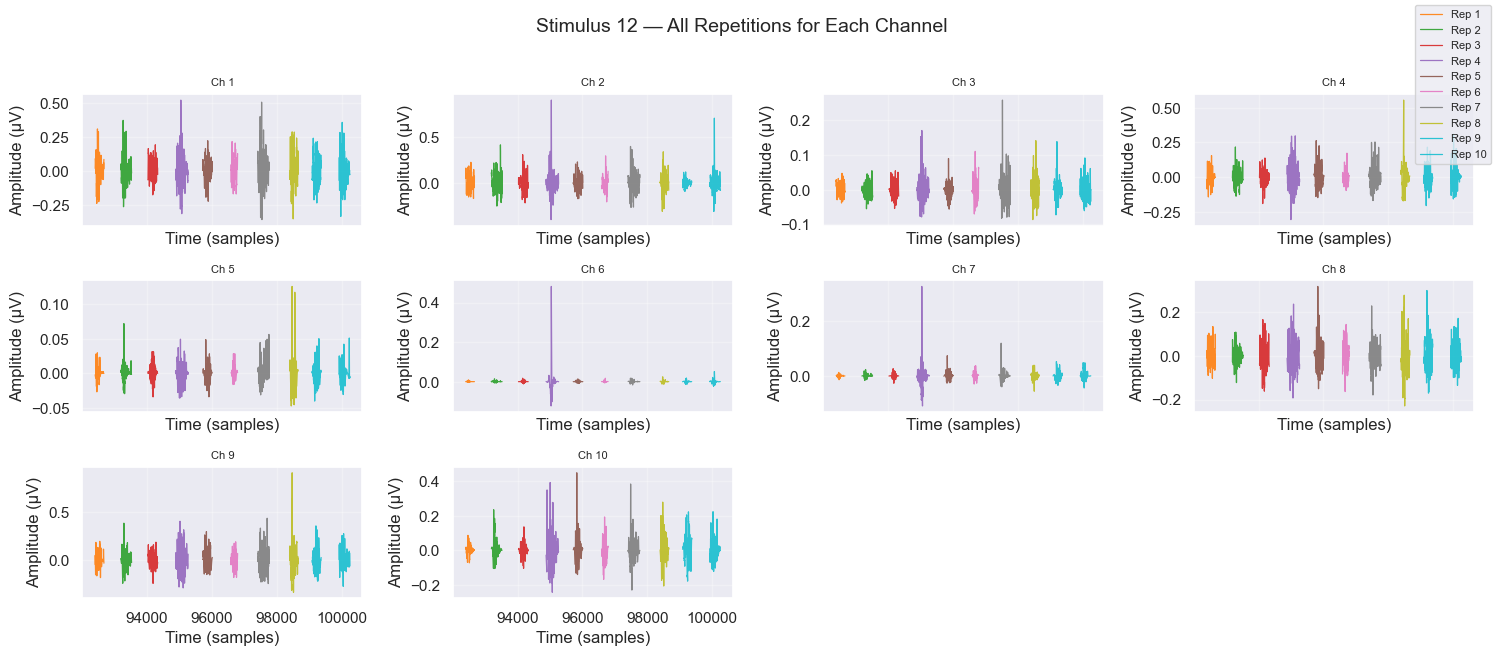

In [8]:
emg_S2 = emg_hp
# Choose a set of colors for repetitions
rep_colors = plt.cm.tab10(np.linspace(0, 1, len(rerepetitions_labels_set)))   # all 10 reps

for label in stimulus_labels_set:
    if label == 0:
        continue  # skip the 'rest' condition (stimulus label = 0) for trial visualization

    print(f"Plotting STIMULUS {label}")

    reps = rerepetitions_labels_set
    # Grid of channels
    n_cols = 4
    n_rows = int(np.ceil(n_channels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.2 * n_rows), sharex=True)
    axes = axes.flatten()

    for ch in range(n_channels):
        ax = axes[ch]

        for i, rep in enumerate(reps):
            mask = (restimulus_S2 == label) & (rerepetition_S2 == rep)
            idx = np.where(mask)[0]
            if len(idx) == 0:
                continue

            start, end = idx[0], idx[-1] + 1

            ax.plot(
                t[start:end],
                emg_S2[start:end, ch],
                color=rep_colors[i % len(rep_colors)],
                linewidth=0.9,
                alpha=0.9,
                label=f"Rep {rep}" if ch == 0 else None
            )

        ax.set_title(f"Ch {ch+1}", fontsize=8)
        ax.set_xlabel("Time (samples)")
        ax.set_ylabel("Amplitude (µV)")
        ax.grid(True, alpha=0.3)

    # remove empty panels
    for ax in axes[n_channels:]:
        ax.axis("off")

    # Legend only on top-right subplot
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper right", fontsize=8)

    fig.suptitle(f"Stimulus {label} — All Repetitions for Each Channel", fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

**Exploratory data analysis: inspection and selection of bad trials**

After high-pass filtering that removed slow drifts, bad trials needed to be identified so that only clean repetitions would be used for machine learning. For each stimulus, repetition and channel, we computed the standard deviation of the signal and detected outliers based on percentile thresholds, outside 5th–95th range. We considered as bad trial those trials that are flagged as abnormal in at least 5 channels. Such identified corrupted repetitions were excluded before creating the train/validation/test sets to avoid data leakage.

In [9]:
# Compute std for each trial (stimulus, rep, channel)
records = []

for label in stimulus_labels_set:
    if label == 0:
        continue  # skip rest condition

    reps = rerepetitions_labels_set
    
    for rep in reps:
        # mask selecting only indices belonging to this trial
        mask = (restimulus_S2 == label) & (rerepetition_S2 == rep)
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue
        
        start, end = idx[0], idx[-1] + 1
        
        for ch in range(n_channels):
            trial_data = emg_S2[start:end, ch]
            trial_std = np.std(trial_data)

            records.append({
                "stimulus": label,
                "rep": rep,
                "channel": ch,
                "std": trial_std
            })

df_std = pd.DataFrame(records)

# Outlier detection per stimulus and per channel
df_std["is_outlier"] = False

for label in stimulus_labels_set:
    if label == 0:
        continue

    for ch in range(n_channels):
        # std values only for this stimulus and channel
        vals = df_std[(df_std["stimulus"] == label) &
                       (df_std["channel"] == ch)]["std"].values
        
        low = np.percentile(vals, 1)
        high = np.percentile(vals, 99)

        # mask of trials outlier for this stimulus and channel
        mask_out = (
            (df_std["stimulus"] == label) &
            (df_std["channel"] == ch) &
            ((df_std["std"] < low) | (df_std["std"] > high))
        )

        df_std.loc[mask_out, "is_outlier"] = True


# Count how many outlier channels for each trial
trial_bad = (
    df_std.groupby(["stimulus", "rep"])["is_outlier"]
          .sum()
          .reset_index(name="n_bad_channels")
)

# Define threshold for bad trials and use >= 3 bad channels to exclude highly noisy trial
CHANNEL_THRESHOLD = 5 # choose 5to be more conservative and see how performance of prediction changes
trial_bad["bad_trial"] = trial_bad["n_bad_channels"] >= CHANNEL_THRESHOLD

# Extract list of bad trials
bad_trials = trial_bad[trial_bad["bad_trial"] == True]
bad_trials_list = [(int(stim), int(rep)) 
                   for stim, rep in bad_trials[["stimulus", "rep"]].values]

print("Trials marked as bad (stimulus, repetition):")
print(bad_trials_list)

Trials marked as bad (stimulus, repetition):
[(1, 6), (2, 2), (4, 4), (5, 7), (7, 9), (9, 8), (11, 8)]


Now we discard the annotated trials in correspondance to every stimulus, getting ready for the selection of the best quality data for train, validation and test of the machine learning model

In [10]:
#bad_trials_list
bad_trials_set = set(bad_trials_list)
good_trials = []
for stim in stimulus_labels_set:
    if stim == 0:
        continue
    for rep in rerepetitions_labels_set:
        if (stim, rep) not in bad_trials_set:
            good_trials.append((stim, rep))

# now define the trials_dict
trials_dict = {}
for stim, rep in good_trials:
    mask = (restimulus_S2 == stim) & (rerepetition_S2 == rep)
    idx = np.where(mask)[0]
    
    if len(idx) == 0:
        continue
    start, end = idx[0], idx[-1] + 1
    trials_dict[(stim, rep)] = emg_S2[start:end, :]

# trials_dict is structured as with elements like: (stimulus_label, repetition_label): corresponding emg data array)

In [11]:
# decomment for debugging to look the diverse emg recordings that correspond to each selected trial and stimulus
#trials_dict

In [12]:
# features definitions
rms = lambda x: np.sqrt(np.mean(x**2, axis=0)) # measure of signal power, related to muscle contraction
rms.__name__ = "rms"
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0) # waveform length, related to signal complexity
wl.__name__ = "wl"
mav = lambda x: np.mean(np.abs(x), axis=0) # mean absolute value
mav.__name__ = "mav"
ssc = lambda x: np.sum(((np.diff(x, axis=0)[:-1] 
                           * np.diff(x, axis=0)[1:]) < 0).astype(int), axis=0) # slope sign changes, related to signal frequency
ssc.__name__ = "ssc"
zc = lambda x: np.sum(((x[:-1] * x[1:]) < 0).astype(int), axis=0) # zero crossings, related to signal frequency
zc.__name__ = "zc"

# other features that could be used
std_f = lambda x: np.std(x, axis=0) # standard deviation
std_f.__name__ = "std"
maxav = lambda x: np.max(np.abs(x), axis=0) # maximum absolute value
maxav.__name__ = "maxav"
logvar = lambda x: np.log(np.var(x, axis=0) + 1e-12) # log-variance
logvar.__name__ = "logvar"
mnf = lambda x, fs=fs: (
    (np.fft.rfftfreq(x.shape[0], 1/fs)[:,None] *
    (np.abs(np.fft.rfft(x, axis=0))**2 / x.shape[0])
    ).sum(axis=0)
    /
    ((np.abs(np.fft.rfft(x, axis=0))**2 / x.shape[0]).sum(axis=0) + 1e-12)
) # mean frequency
mnf.__name__ = "mnf"
spec_entropy = lambda x, fs=fs: (
    -(lambda p: (p * np.log(p + 1e-12)).sum(axis=0))
    ((np.abs(np.fft.rfft(x, axis=0))**2 / x.shape[0]) /
     ((np.abs(np.fft.rfft(x, axis=0))**2 / x.shape[0]).sum(axis=0) + 1e-12)
    )
) # spectral entropy, related to signal complexity
spec_entropy.__name__ = "spec_entropy"

feature_list = [rms, wl, mav, logvar, spec_entropy]
# best combination so far: [rms, wl, mav, logvar, spec_entropy]

In [ ]:
def build_dataset_from_trials_dict(trials_dict, feature_list):
    """
    Convert trials_dict into a machine learning dataset.
    
    Parameters:
    trials_dict : dict
        Keys are (stim, rep), values are EMG segments (T × n_channels).
    feature_list : list of callables
        Each feature function takes an array (T × n_channels) and returns (n_channels,).
    
    Returns:
    X : ndarray, shape (n_trials, n_features_total)
        Feature matrix.
    y : ndarray, shape (n_trials,)
        Labels (stimulus type).
    trial_keys : list of tuples
        The (stim, rep) order used for rows in X and y.
    """
    trial_keys = sorted(trials_dict.keys())
    n_trials = len(trial_keys)

    first_trial = trials_dict[trial_keys[0]]
    _, n_channels = first_trial.shape

    n_features = len(feature_list) * n_channels

    X = np.zeros((n_trials, n_features))
    y = np.zeros(n_trials, dtype=int)

    for i, (stim, rep) in enumerate(trial_keys):
        segment = trials_dict[(stim, rep)]
        feature_vector = []

        for feat in feature_list:
            vals = feat(segment).reshape(-1)
            feature_vector.extend(vals)

        feature_vector = np.array(feature_vector)
        if feature_vector.size != n_features:
            raise ValueError(f"Wrong feature length: expected {n_features}, got {feature_vector.size}")

        X[i, :] = feature_vector
        y[i] = stim

    return X, y, trial_keys

In [14]:
X, y, trial_order = build_dataset_from_trials_dict(trials_dict, feature_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Example trial order (stimulus type and its repetition in the protocol):", trial_order[:5])

X shape: (113, 50)
y shape: (113,)
Example trial order (stimulus type and its repetition in the protocol): [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5)]


**Features visualization**

In [15]:
# boxplot of features per class

def plot_feature_distributions(X, y, feature_list, n_channels):
    """
    Create clean boxplots for each feature across stimulus classes.
    
    X : array (n_trials, n_features)
    y : array (n_trials,)
    feature_list : list of callable feature functions
    n_channels : number of EMG channels
    """

    # feature names
    feature_names = []
    for f in feature_list:
        feature_names.extend([f"{f.__name__}_ch{ch}" for ch in range(n_channels)])
        print(feature_names)
        
    n_features = len(feature_names)

    # subplot
    n_cols = 4
    n_rows = math.ceil(n_features / n_cols)

    plt.figure(figsize=(6*n_cols, 5*n_rows))

    classes = np.unique(y)

    for i in range(n_features):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        
        # Prepare data for each class
        data = [X[y == c, i] for c in classes]

        # Boxplot
        bp = ax.boxplot(data, patch_artist=True)

        # Beautiful colors
        colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        # Titles and labels
        ax.set_title(feature_names[i], fontsize=9)
        ax.set_xticks(range(1, len(classes) + 1))
        ax.set_xticklabels(classes, fontsize=8)
        ax.set_xlabel("Stimulus", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)

    plt.tight_layout()
    plt.show()



['rms_ch0', 'rms_ch1', 'rms_ch2', 'rms_ch3', 'rms_ch4', 'rms_ch5', 'rms_ch6', 'rms_ch7', 'rms_ch8', 'rms_ch9']
['rms_ch0', 'rms_ch1', 'rms_ch2', 'rms_ch3', 'rms_ch4', 'rms_ch5', 'rms_ch6', 'rms_ch7', 'rms_ch8', 'rms_ch9', 'wl_ch0', 'wl_ch1', 'wl_ch2', 'wl_ch3', 'wl_ch4', 'wl_ch5', 'wl_ch6', 'wl_ch7', 'wl_ch8', 'wl_ch9']
['rms_ch0', 'rms_ch1', 'rms_ch2', 'rms_ch3', 'rms_ch4', 'rms_ch5', 'rms_ch6', 'rms_ch7', 'rms_ch8', 'rms_ch9', 'wl_ch0', 'wl_ch1', 'wl_ch2', 'wl_ch3', 'wl_ch4', 'wl_ch5', 'wl_ch6', 'wl_ch7', 'wl_ch8', 'wl_ch9', 'mav_ch0', 'mav_ch1', 'mav_ch2', 'mav_ch3', 'mav_ch4', 'mav_ch5', 'mav_ch6', 'mav_ch7', 'mav_ch8', 'mav_ch9']
['rms_ch0', 'rms_ch1', 'rms_ch2', 'rms_ch3', 'rms_ch4', 'rms_ch5', 'rms_ch6', 'rms_ch7', 'rms_ch8', 'rms_ch9', 'wl_ch0', 'wl_ch1', 'wl_ch2', 'wl_ch3', 'wl_ch4', 'wl_ch5', 'wl_ch6', 'wl_ch7', 'wl_ch8', 'wl_ch9', 'mav_ch0', 'mav_ch1', 'mav_ch2', 'mav_ch3', 'mav_ch4', 'mav_ch5', 'mav_ch6', 'mav_ch7', 'mav_ch8', 'mav_ch9', 'logvar_ch0', 'logvar_ch1', 'logvar_

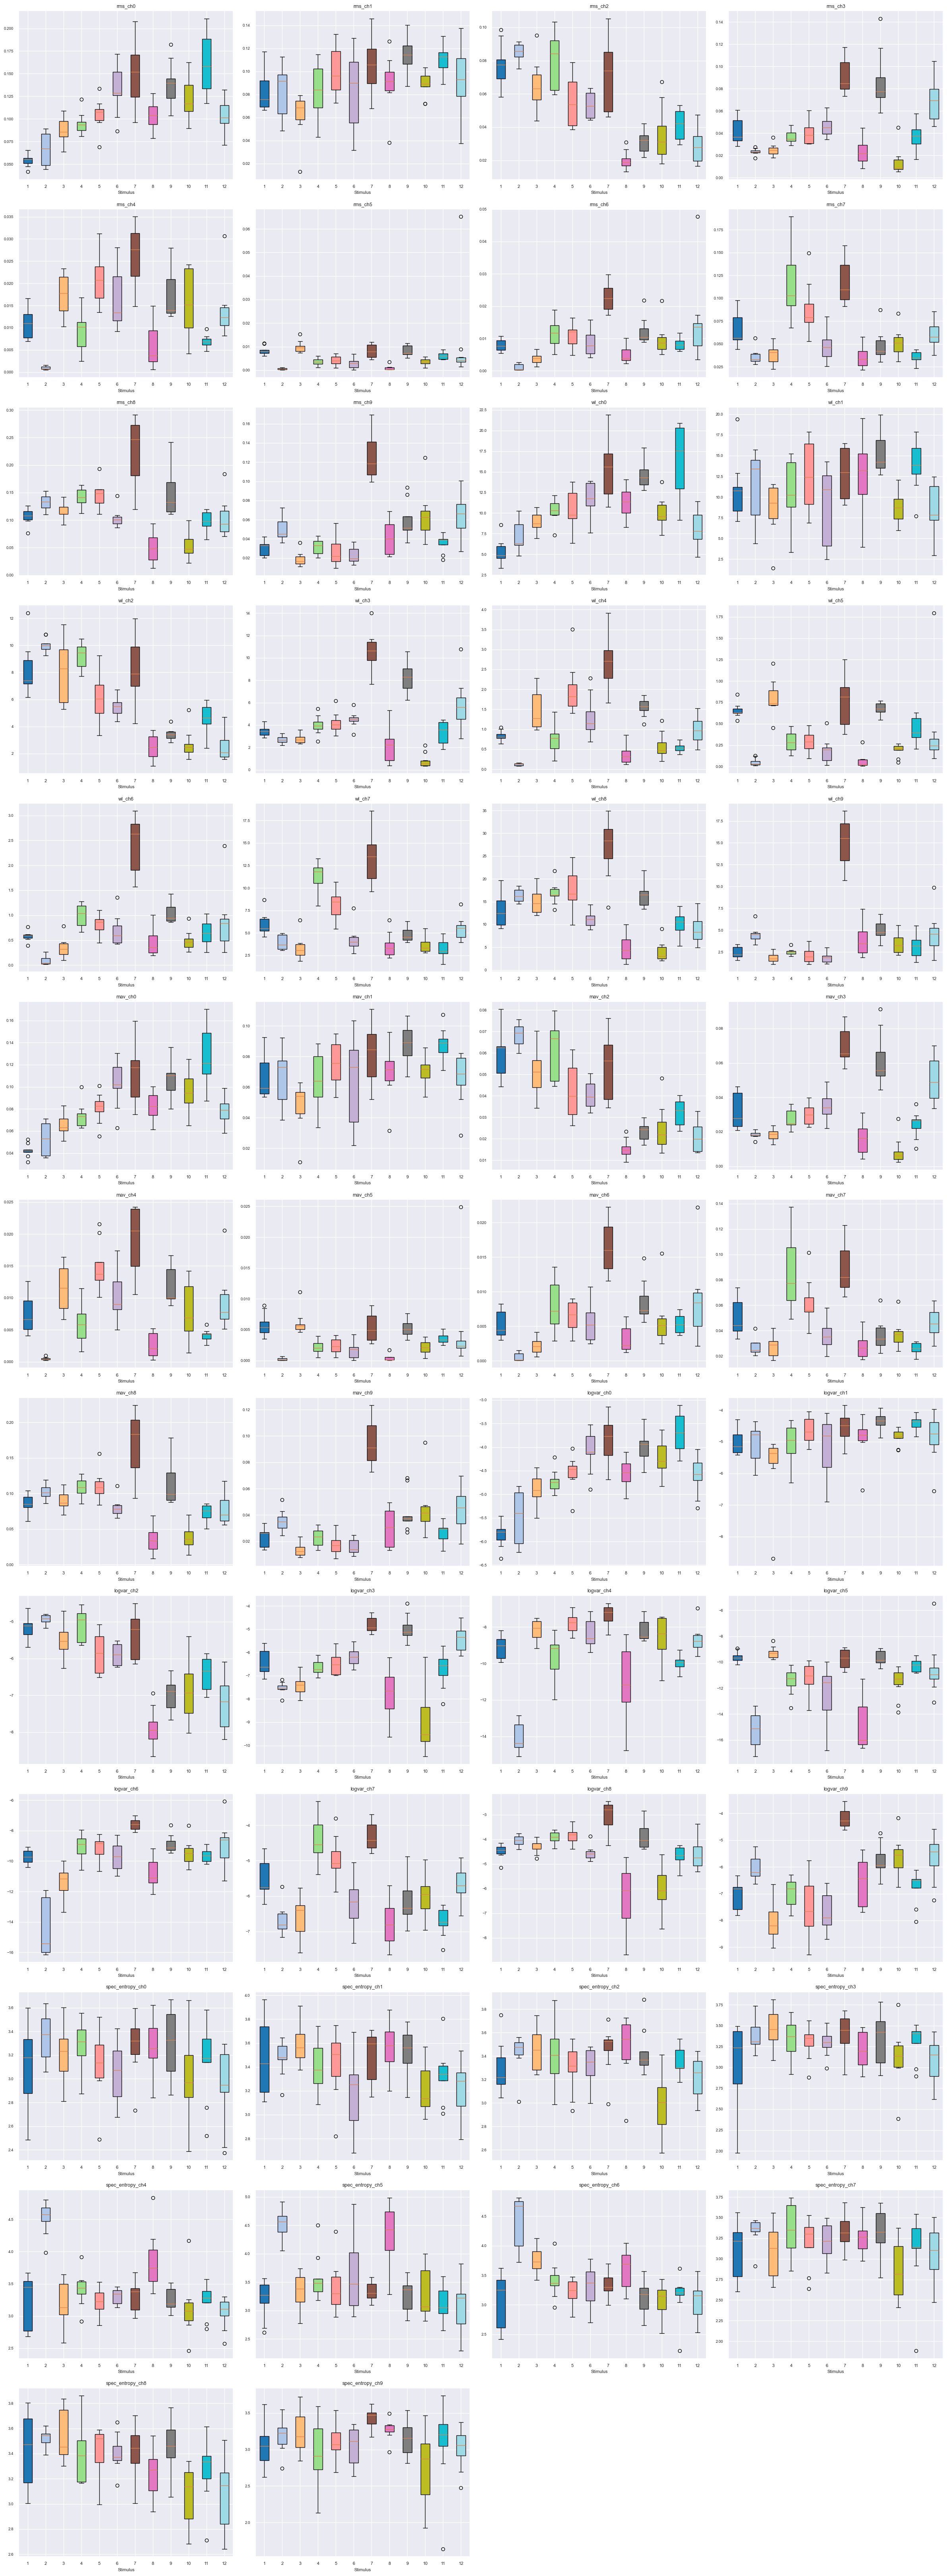

In [16]:
# visualization of the selected features to have a feeling of their distributions and see if indeed
# they could be informative for classification purpuses
plot_feature_distributions(X, y, feature_list, n_channels=10)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV

In [18]:
# split in train and test sets, and instead of using a validation set, use cross-validation during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (90, 50)
Test shape: (23, 50)


In [19]:
# scaling
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_test_z  = scaler.transform(X_test)

In [20]:
# Define model and perform hyperparameter tuning with GridSearchCV
gb = GradientBoostingClassifier()

# Parameter grid for tuning
param_grid = {
    "n_estimators": [45, 50, 55],
    "learning_rate": [0.15, 0.2, 0.25],
    "max_depth": [3, 4, 5],
}

# Weighted F1 score as scoring metric
scorer = make_scorer(f1_score, average="weighted")

# Cross-validation search with gradient boosting on the hyperparameters defined with split on the training set
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring=scorer,
    cv=5, # 5-fold cross validation
    n_jobs=-1
)

print("\n WAIT, performing GridSearchCV...")
grid.fit(X_train_z, y_train)

print("\nBest hyperparameters:", grid.best_params_)
print("Best CV score (weighted F1):", grid.best_score_)


 WAIT, performing GridSearchCV...

Best hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
Best CV score (weighted F1): 0.6292592592592594


In [21]:
#retain best model and fit on the training set
best_gb = grid.best_estimator_
best_gb.fit(X_train_z, y_train)

# evaluate on test set
y_pred = best_gb.predict(X_test_z)


FINAL TEST PERFORMANCE
Test Accuracy: 0.7826
Test Weighted F1: 0.7540


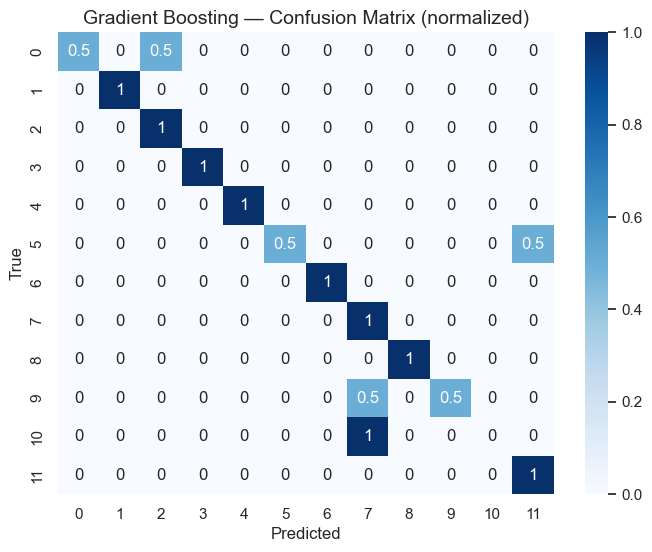

In [22]:
# evaluation of performance of the model
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nFINAL TEST PERFORMANCE")
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Weighted F1: {:.4f}".format(test_f1))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")#, fmt=".2f")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Gradient Boosting — Confusion Matrix (normalized)", fontsize=14)
plt.show()

**Perform feature selection and dimensionality reduction**

**Method 1: Feature importance**

In [23]:
feature_names = []
for f in feature_list:
    for ch in range(n_channels):
        feature_names.append(f"{f.__name__}_ch{ch+1}")
        
len(feature_names), feature_names[:10]

(50,
 ['rms_ch1',
  'rms_ch2',
  'rms_ch3',
  'rms_ch4',
  'rms_ch5',
  'rms_ch6',
  'rms_ch7',
  'rms_ch8',
  'rms_ch9',
  'rms_ch10'])

In [24]:
# use mutual info classif to determine the importance of each feature
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_z, y_train, random_state=42)
# Sort by importance
mi_sorted_idx = np.argsort(mi)[::-1]
print("\nTop 10 features by mutual information:")
for i in mi_sorted_idx[:20]:
    print(f"{feature_names[i]:30s} → MI = {mi[i]:.4f}")


Top 10 features by mutual information:
wl_ch4                         → MI = 1.0219
wl_ch5                         → MI = 0.9360
mav_ch4                        → MI = 0.8548
rms_ch4                        → MI = 0.8343
logvar_ch4                     → MI = 0.8337
rms_ch10                       → MI = 0.7606
wl_ch6                         → MI = 0.7602
logvar_ch10                    → MI = 0.7494
wl_ch3                         → MI = 0.7492
wl_ch9                         → MI = 0.7453
mav_ch10                       → MI = 0.7125
wl_ch8                         → MI = 0.6837
mav_ch3                        → MI = 0.6711
mav_ch5                        → MI = 0.6695
rms_ch3                        → MI = 0.6481
wl_ch7                         → MI = 0.6480
logvar_ch3                     → MI = 0.6410
logvar_ch5                     → MI = 0.6287
mav_ch9                        → MI = 0.6261
rms_ch6                        → MI = 0.6122


In [25]:
from sklearn.feature_selection import SelectKBest
k = 20  # select top k features
selector = SelectKBest(mutual_info_classif, k=k)
selector.fit(X_train_z, y_train)

X_train_best = selector.transform(X_train_z)
X_test_best = selector.transform(X_test_z)

In [26]:
# redo cross-validation with only the selected features
gb_best_best_features = GradientBoostingClassifier()
grid_best_features = GridSearchCV(
    estimator=gb_best_best_features,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)
print("\n WAIT, performing GridSearchCV with selected features...")
grid_best_features.fit(X_train_best, y_train)
print("\nBest hyperparameters with selected features:", grid_best_features.best_params_)
print("Best CV score (weighted F1) with selected features:", grid_best_features.best_score_)


 WAIT, performing GridSearchCV with selected features...

Best hyperparameters with selected features: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 55}
Best CV score (weighted F1) with selected features: 0.5799999999999998



PERFORMANCE WITH SELECTED FEATURES
Test Accuracy: 0.8261
Weighted F1:  0.8174


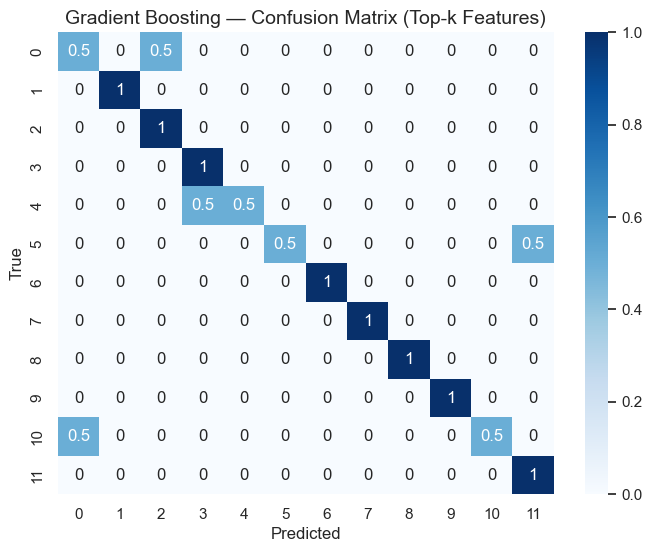

In [27]:
# performance on selected features
y_pred_reduced = grid_best_features.predict(X_test_best)

# evaluation
test_accuracy_best_features = accuracy_score(y_test, y_pred_reduced)
test_f1_best_features = f1_score(y_test, y_pred_reduced, average="weighted")

print("\nPERFORMANCE WITH SELECTED FEATURES")
print("Test Accuracy: {:.4f}".format(test_accuracy_best_features))
print("Weighted F1:  {:.4f}".format(test_f1_best_features))

# Confusion matrix for reduced-feature model 
cm = confusion_matrix(y_test, y_pred_reduced, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Gradient Boosting — Confusion Matrix (Top-k Features)", fontsize=14)
plt.show()

**Perform feature selection and dimensionality reduction**

**Method 2: PCA**

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pipe = Pipeline([
    ("pca", PCA()),
    ("gb", GradientBoostingClassifier())
])

param_grid_PCA = {
    "pca__n_components": [14, 15, 16],
    "gb__n_estimators": [40, 50, 60],
    "gb__learning_rate": [0.1, 0.15, 0.2, 0.25, 0.3],
    "gb__max_depth": [1, 2, 3, 4]
}

grid_PCA = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_PCA,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

grid_PCA.fit(X_train_z, y_train)

print("Best params:", grid_PCA.best_params_)
print("Best CV score:", grid_PCA.best_score_)

Best params: {'gb__learning_rate': 0.2, 'gb__max_depth': 1, 'gb__n_estimators': 50, 'pca__n_components': 15}
Best CV score: 0.6322222222222222



FINAL TEST PERFORMANCE (PCA Model)
Test Accuracy: 0.7826
Weighted F1:  0.7797


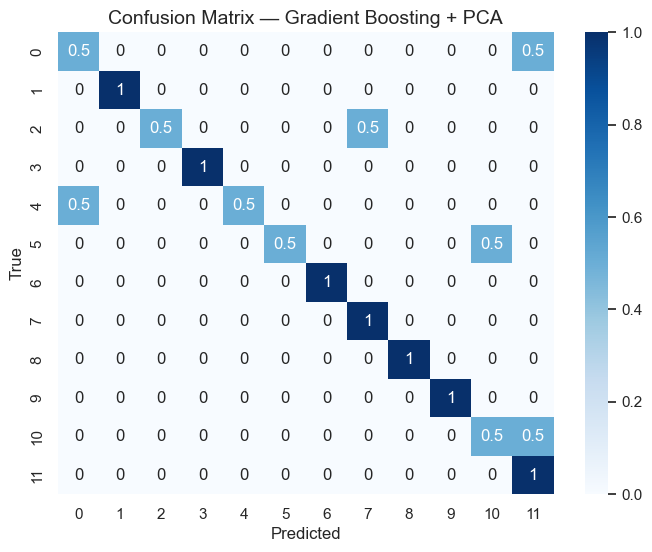

In [29]:
best_model_PCA = grid_PCA.best_estimator_
best_model_PCA.fit(X_train_z, y_train)
y_pred_pca = best_model_PCA.predict(X_test_z)

test_accuracy_pca = accuracy_score(y_test, y_pred_pca)
test_f1_pca = f1_score(y_test, y_pred_pca, average="weighted")

print("\nFINAL TEST PERFORMANCE (PCA Model)")
print("Test Accuracy: {:.4f}".format(test_accuracy_pca))
print("Weighted F1:  {:.4f}".format(test_f1_pca))

# CONFUSION MATRIX for PCA model
cm_pca = confusion_matrix(y_test, y_pred_pca, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm_pca, annot=True, cmap="Blues")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix — Gradient Boosting + PCA", fontsize=14)
plt.show()

# Part 2: Generalization across subjects

For this part, we wil focus on all the subjects to observe if training the model on data from a group of individuals improves performance on new subjects. We will consider all 27 subjects, only the first exercise for each subject. The same preprocessing pipeline used in part 1 will be followed.

In [30]:
# Compute std for each trial (stimulus, rep, channel)
def bad_trials_detection(emg_S2, restimulus_S2, rerepetition_S2, stimulus_labels_set, rerepetitions_labels_set, n_channels):
    records = []
    for label in stimulus_labels_set:
        if label == 0:
            continue  # skip rest condition

        reps = rerepetitions_labels_set
        
        for rep in reps:
            # mask selecting only indices belonging to this trial
            mask = (restimulus_S2 == label) & (rerepetition_S2 == rep)
            idx = np.where(mask)[0]
            if len(idx) == 0:
                continue
            
            start, end = idx[0], idx[-1] + 1
            
            for ch in range(n_channels):
                trial_data = emg_S2[start:end, ch]
                trial_std = np.std(trial_data)

                records.append({
                    "stimulus": label,
                    "rep": rep,
                    "channel": ch,
                    "std": trial_std
                })

    df_std = pd.DataFrame(records)

    # Outlier detection per stimulus and per channel
    df_std["is_outlier"] = False

    for label in stimulus_labels_set:
        if label == 0:
            continue

        for ch in range(n_channels):
            # std values only for this stimulus and channel
            vals = df_std[(df_std["stimulus"] == label) &
                        (df_std["channel"] == ch)]["std"].values
            
            low = np.percentile(vals, 1)
            high = np.percentile(vals, 99)

            # mask of trials outlier for this stimulus and channel
            mask_out = (
                (df_std["stimulus"] == label) &
                (df_std["channel"] == ch) &
                ((df_std["std"] < low) | (df_std["std"] > high))
            )

            df_std.loc[mask_out, "is_outlier"] = True


    # Count how many outlier channels for each trial
    trial_bad = (
        df_std.groupby(["stimulus", "rep"])["is_outlier"]
            .sum()
            .reset_index(name="n_bad_channels")
    )

    # Define threshold for bad trials and use >= 5 bad channels to exclude highly noisy trial
    CHANNEL_THRESHOLD = 5 # choose 5 to be more conservative and see how performance of prediction changes
    trial_bad["bad_trial"] = trial_bad["n_bad_channels"] >= CHANNEL_THRESHOLD

    # Extract list of bad trials
    bad_trials = trial_bad[trial_bad["bad_trial"] == True]
    bad_trials_list = [(int(stim), int(rep)) 
                    for stim, rep in bad_trials[["stimulus", "rep"]].values]

    print("Trials marked as bad (stimulus, repetition):")
    print(bad_trials_list)
    return bad_trials_list



In [34]:
from pathlib import Path
data_folder = Path('data')
subject_numbers = range(1, 28)
all_subjects_data = {}

for sub_num in subject_numbers:
    print(f"\nProcessing Subject {sub_num}...")
    target_filename = f's{sub_num}/S{sub_num}_A1_E1.mat'
    file_path = data_folder / target_filename
    emg_data = loadmat(file_path)

    # Extract the relevant fields from the loaded .mat file
    subject_number = emg_data["subject"].item()
    exercise_number = emg_data["exercise"].item()

    # stimulus, restimulus, repetition, rerepetition
    stimulus_labels = emg_data["stimulus"].squeeze().astype(int)
    restimulus = emg_data["restimulus"].squeeze().astype(int)
    repetition = emg_data["repetition"].squeeze().astype(int)
    rerepetition = emg_data["rerepetition"].squeeze().astype(int)

    # EMG data
    emg = emg_data["emg"] #shape (n_samples, n_channels)
    n_samples = emg.shape[0]
    t = np.arange(n_samples)
    n_channels = emg.shape[1]

    # glove
    glove = emg_data["glove"]
    n_sensors_glove = glove.shape[1]

    #high-pass filtering 
    fs = 100
    emg_dc = emg - emg.mean(axis=0)
    emg_hp = highpass_filter(emg_dc, fs, cutoff=1.0)

    #finding and eliminating bad trials
    bad_trials_list = bad_trials_detection(emg_hp, restimulus, rerepetition, stimulus_labels_set, rerepetitions_labels_set, n_channels)

    bad_trials_set = set(bad_trials_list)
    good_trials = []
    for stim in stimulus_labels_set:
        if stim == 0:
            continue
        for rep in rerepetitions_labels_set:
            if (stim, rep) not in bad_trials_set:
                good_trials.append((stim, rep))

    # now define the trials_dict
    trials_dict = {}
    for stim, rep in good_trials:
        mask = (restimulus == stim) & (rerepetition == rep)
        idx = np.where(mask)[0]
        
        if len(idx) == 0:
            continue
        start, end = idx[0], idx[-1] + 1
        trials_dict[(stim, rep)] = emg_hp[start:end, :]

    X, y, trial_order = build_dataset_from_trials_dict(trials_dict, feature_list)
    #Saving the data
    all_subjects_data[f'S{sub_num}'] = {
        'exercise': exercise_number,
        'emg': emg_hp,
        'stimulus_labels': stimulus_labels,
        'restimulus': restimulus,
        'repetition': repetition,
        'rerepetition': rerepetition,
        'glove': glove,
        'trials_dict': trials_dict,
        'X': X,
        'y': y,
        'trial_order': trial_order,
    }

    
print("\n--- Processing Complete ---")
print(f"Processed data for {len(all_subjects_data)} subjects.")


Processing Subject 1...
Trials marked as bad (stimulus, repetition):
[(1, 4), (2, 7), (5, 1), (6, 1), (7, 5), (8, 2), (8, 10), (9, 9), (10, 1), (10, 3), (11, 4), (11, 9)]

Processing Subject 2...
Trials marked as bad (stimulus, repetition):
[(1, 6), (2, 2), (4, 4), (5, 7), (7, 9), (9, 8), (11, 8)]

Processing Subject 3...
Trials marked as bad (stimulus, repetition):
[(1, 5), (3, 3), (3, 7), (4, 8), (6, 4), (6, 9), (7, 2), (7, 6), (8, 1), (8, 6), (9, 1), (10, 8), (12, 3), (12, 9)]

Processing Subject 4...
Trials marked as bad (stimulus, repetition):
[(1, 1), (1, 9), (2, 1), (2, 4), (3, 2), (3, 9), (4, 2), (4, 10), (5, 6), (6, 2), (6, 3), (6, 10), (7, 9), (7, 10), (9, 2), (9, 10), (11, 3), (11, 10), (12, 1)]

Processing Subject 5...
Trials marked as bad (stimulus, repetition):
[(1, 5), (2, 2), (3, 5), (4, 2), (5, 5), (5, 9), (7, 2), (8, 8), (9, 1), (10, 8), (11, 1), (12, 6), (12, 9)]

Processing Subject 6...
Trials marked as bad (stimulus, repetition):
[(1, 2), (2, 4), (2, 9), (3, 1), (

Now let's choose the same features as before, and let's observe if there are any differences across subject. We will show the graphics for only one channel per subject.

In [35]:
def plot_feature_per_subject(all_subjects_data, feature_list, channel=0):
    """
    Create boxplots for each feature (for a given channel) across stimulus classes,
    for all subjects.
    """

    first_key = list(all_subjects_data.keys())[0]
    n_channels = all_subjects_data[first_key]['X'].shape[1] // len(feature_list)

    # feature names
    feature_names = []
    for f in feature_list:
        feature_names.append(f"{f.__name__}_ch{channel}")
        
    n_cols = 4
    n_subjects = len(all_subjects_data)
    n_rows = math.ceil(n_subjects / n_cols)

    for i in range(len(feature_list)):
        plt.figure(figsize=(6*n_cols, 5*n_rows))

        col_idx = i * n_channels + channel

        for j in range(n_subjects):
            subj_key = f"S{j+1}"
            classes = np.unique(all_subjects_data[subj_key]['y'])
            ax = plt.subplot(n_rows, n_cols, j + 1)
        
            # Prepare data for each class
            data = [
                all_subjects_data[subj_key]['X'][
                    all_subjects_data[subj_key]['y'] == c, col_idx
                ]
                for c in classes
            ]

            # Boxplot
            bp = ax.boxplot(data, patch_artist=True)

            colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
            
            # Titles and labels
            ax.set_title(feature_names[i] + f"_S{j+1}", fontsize=9)
            ax.set_xticks(range(1, len(classes) + 1))
            ax.set_xticklabels(classes, fontsize=8)
            ax.set_xlabel("Stimulus", fontsize=8)
            ax.tick_params(axis="y", labelsize=7)

        plt.tight_layout()
        plt.show()



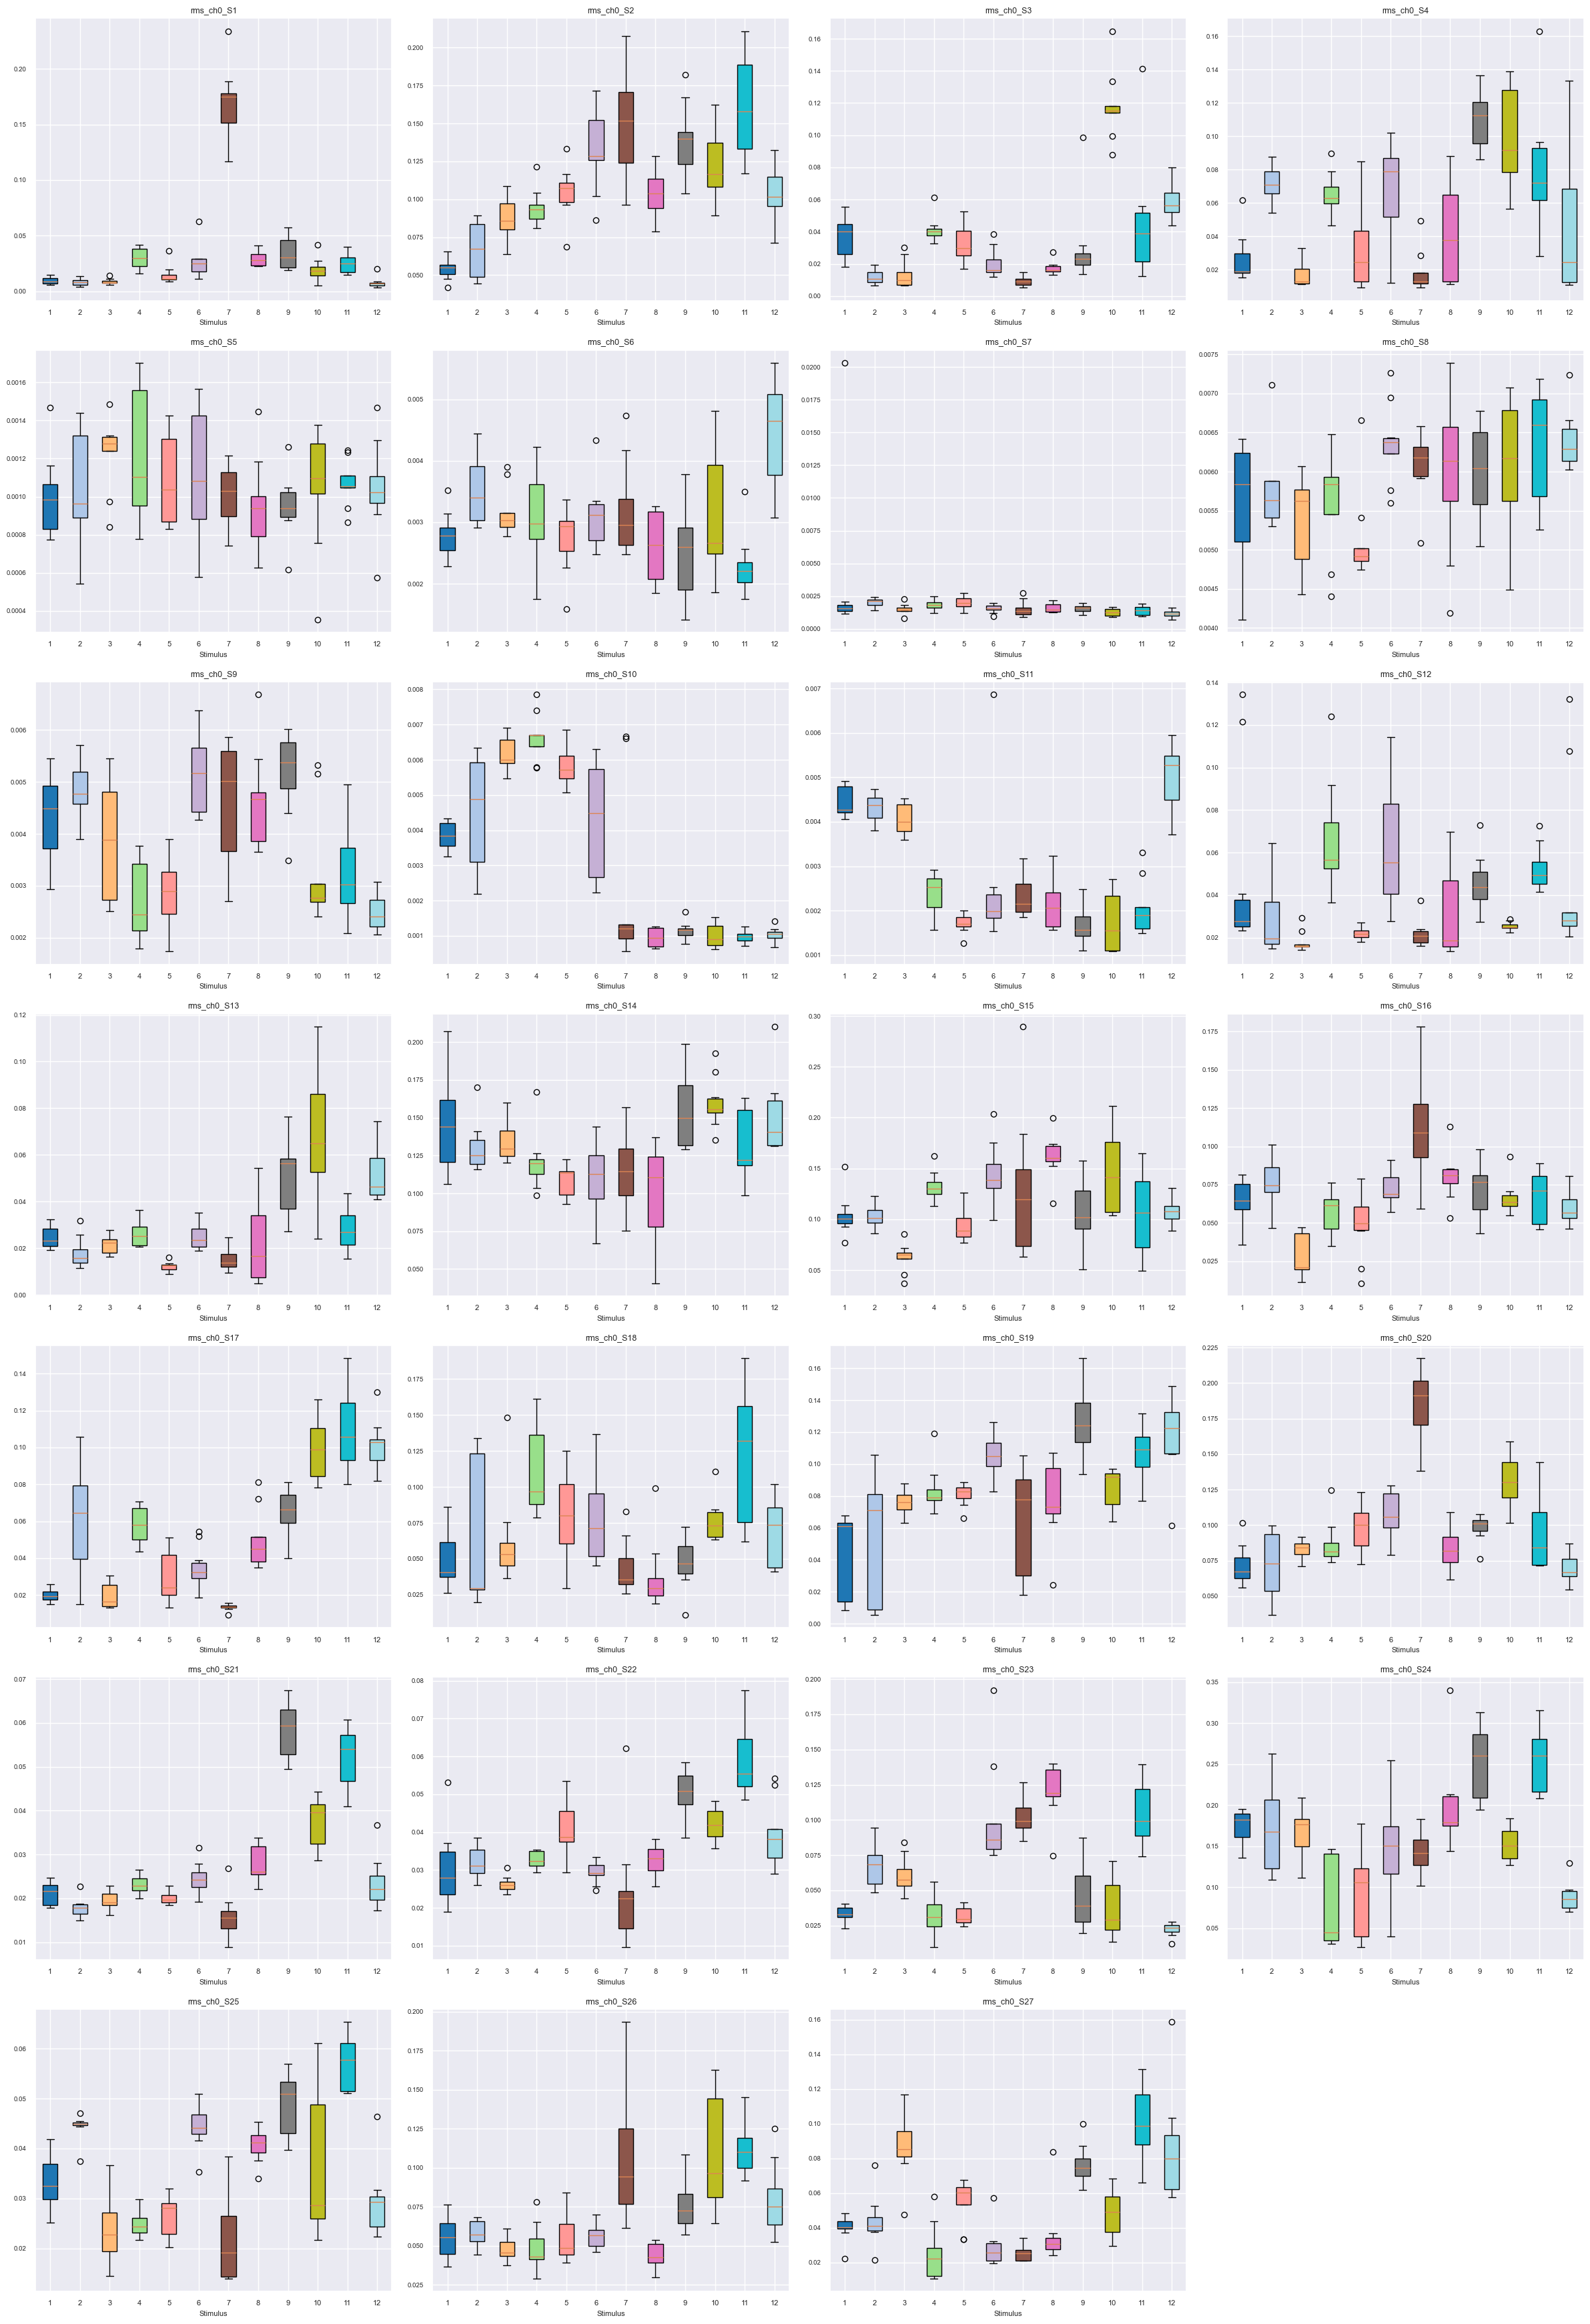

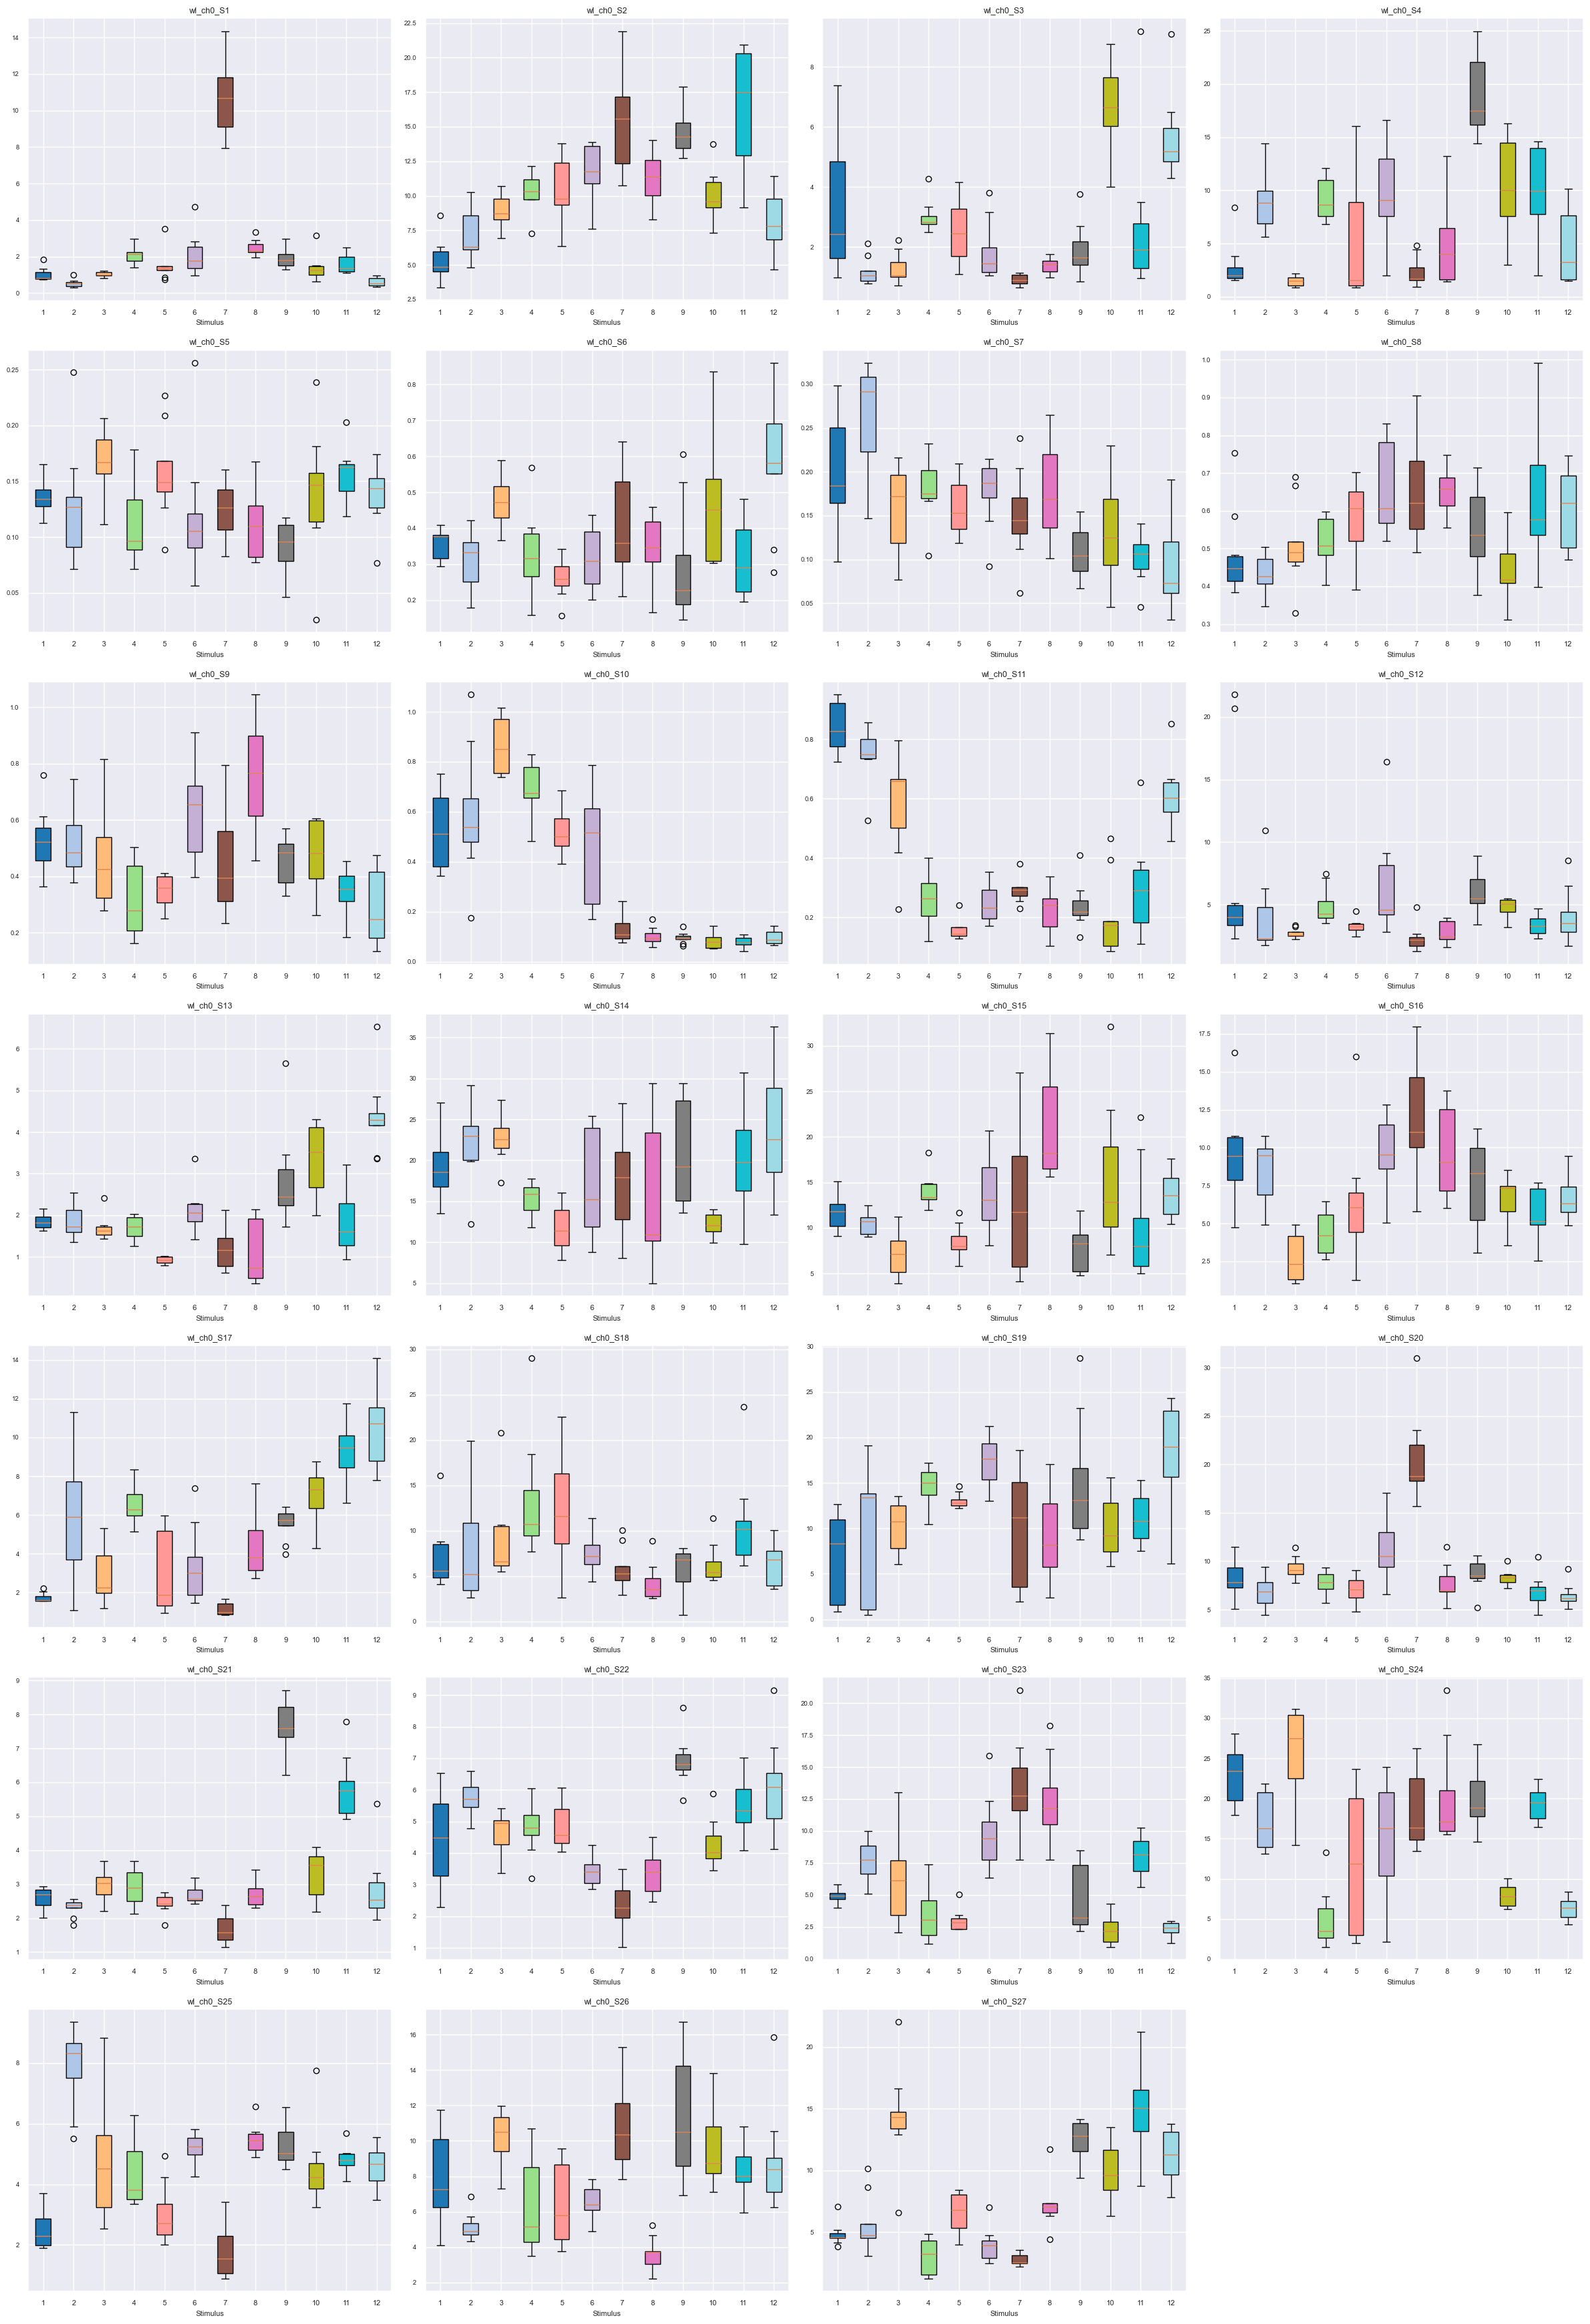

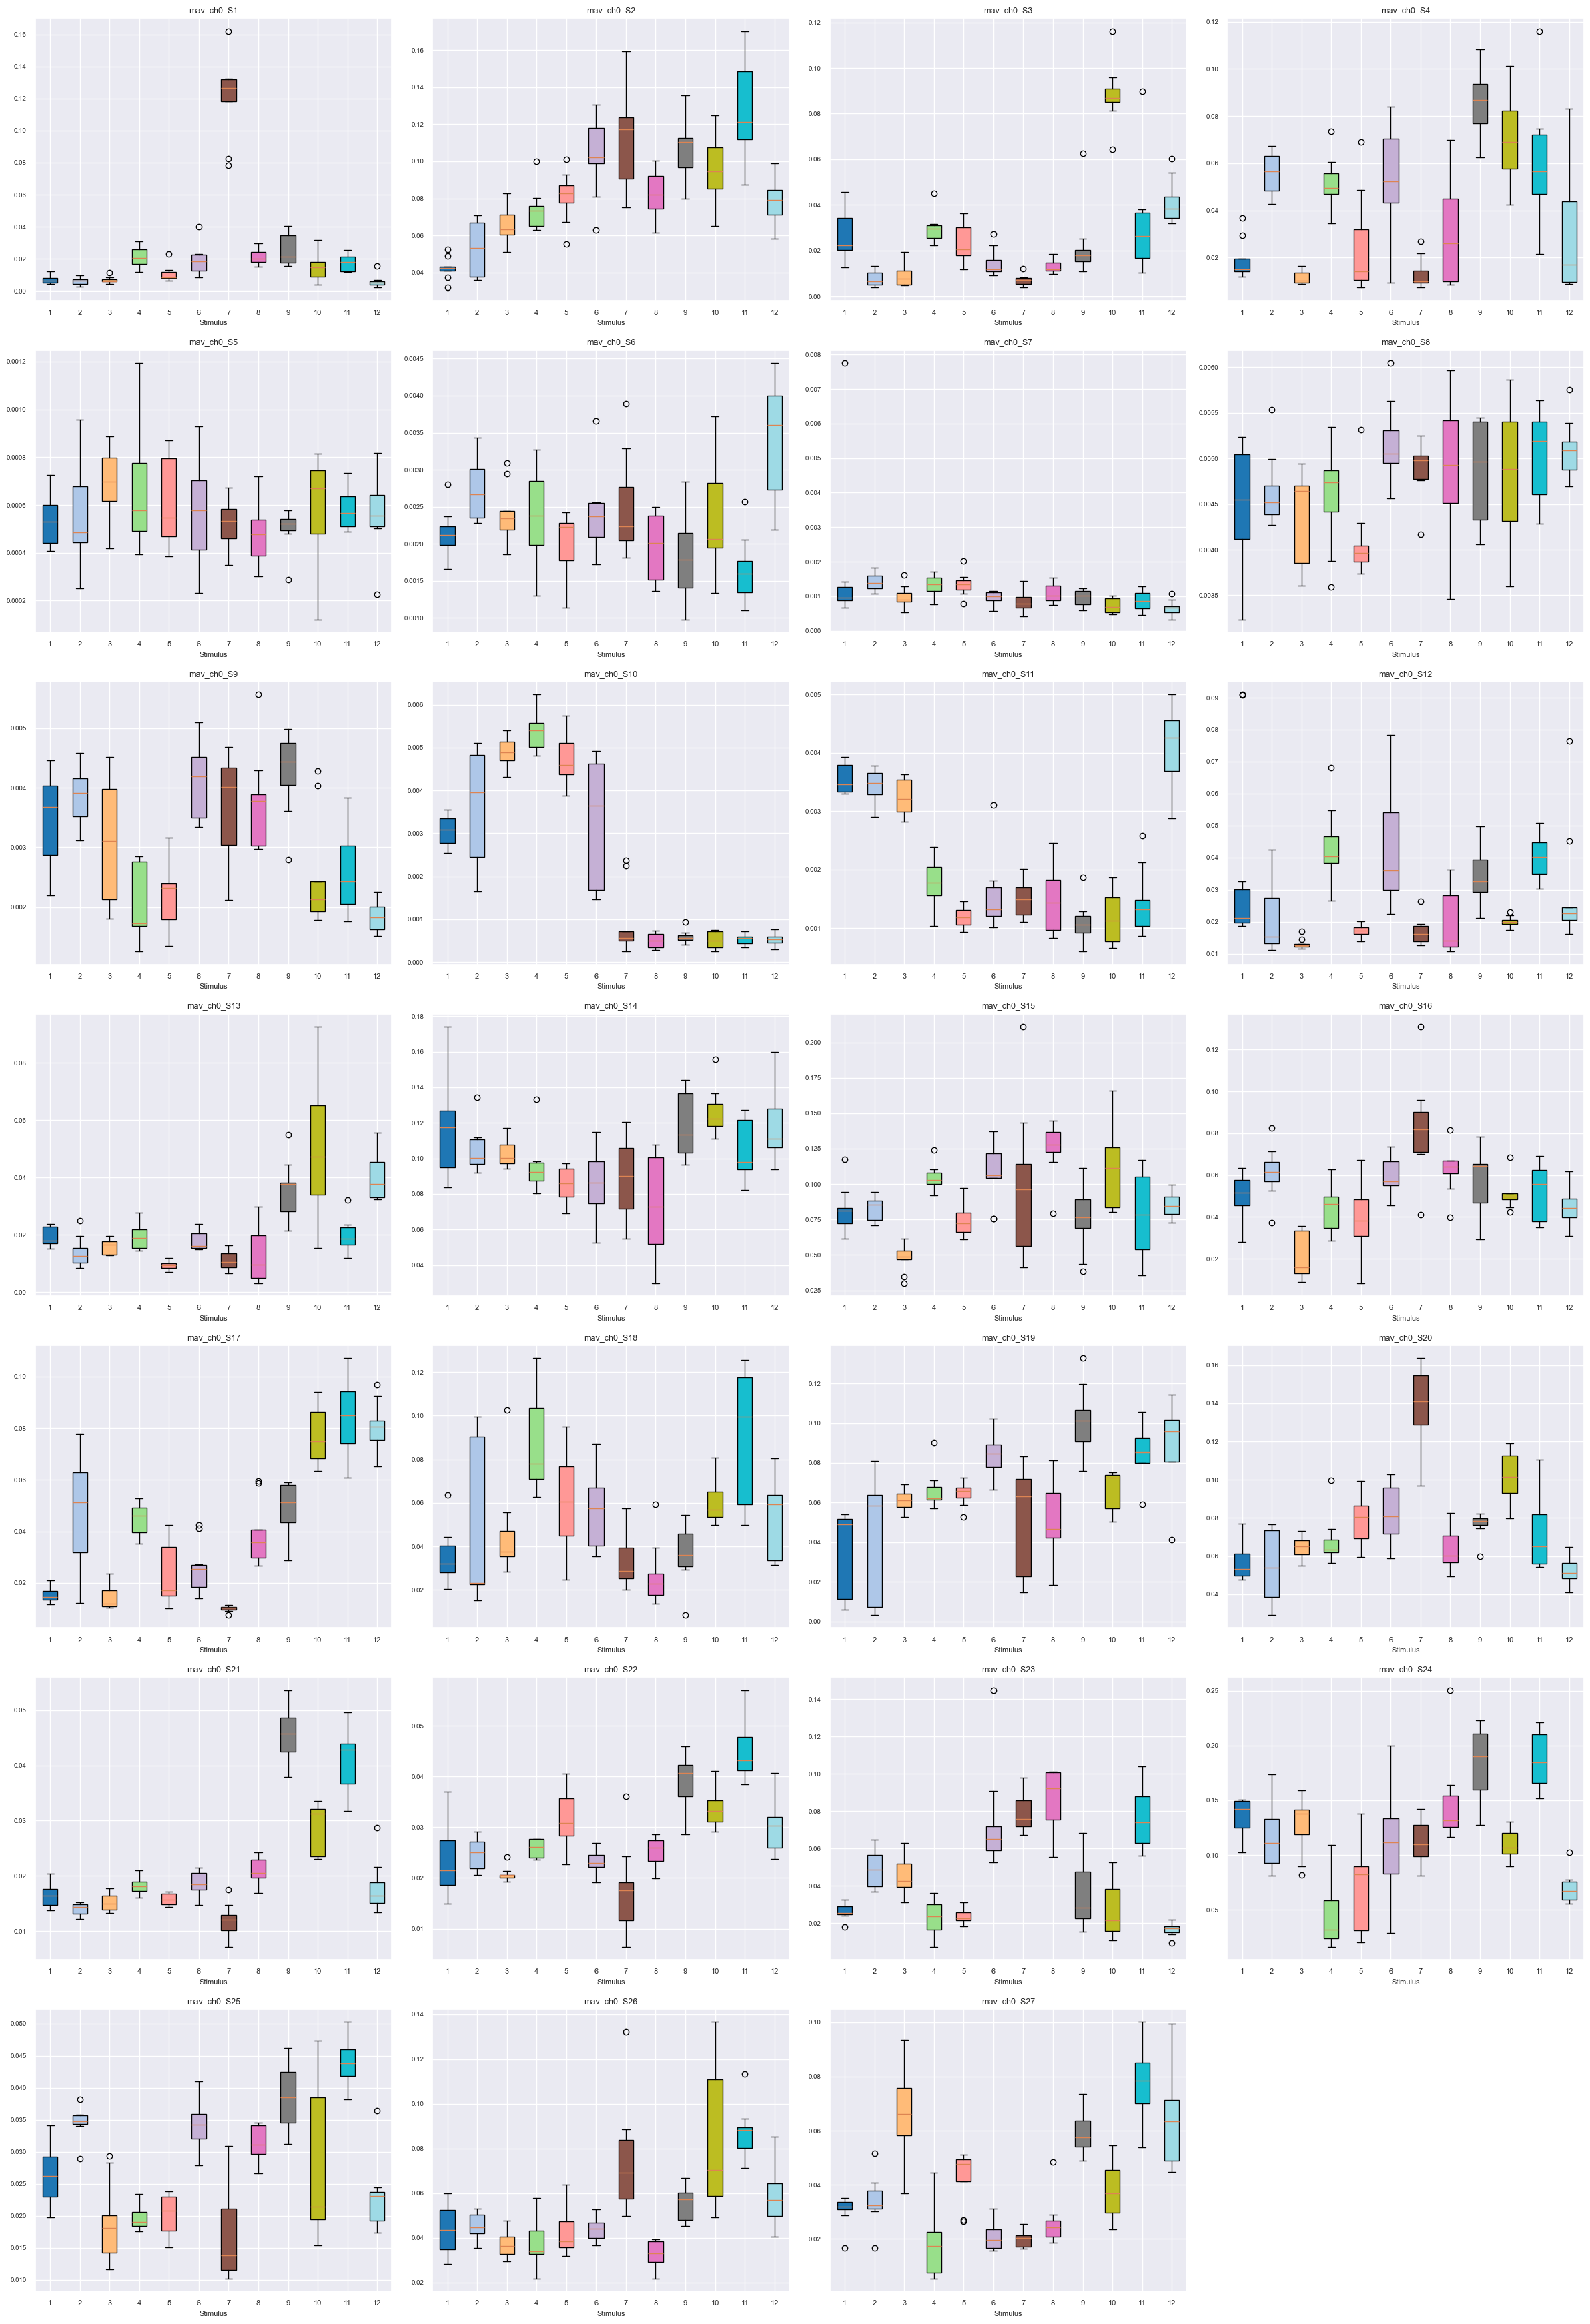

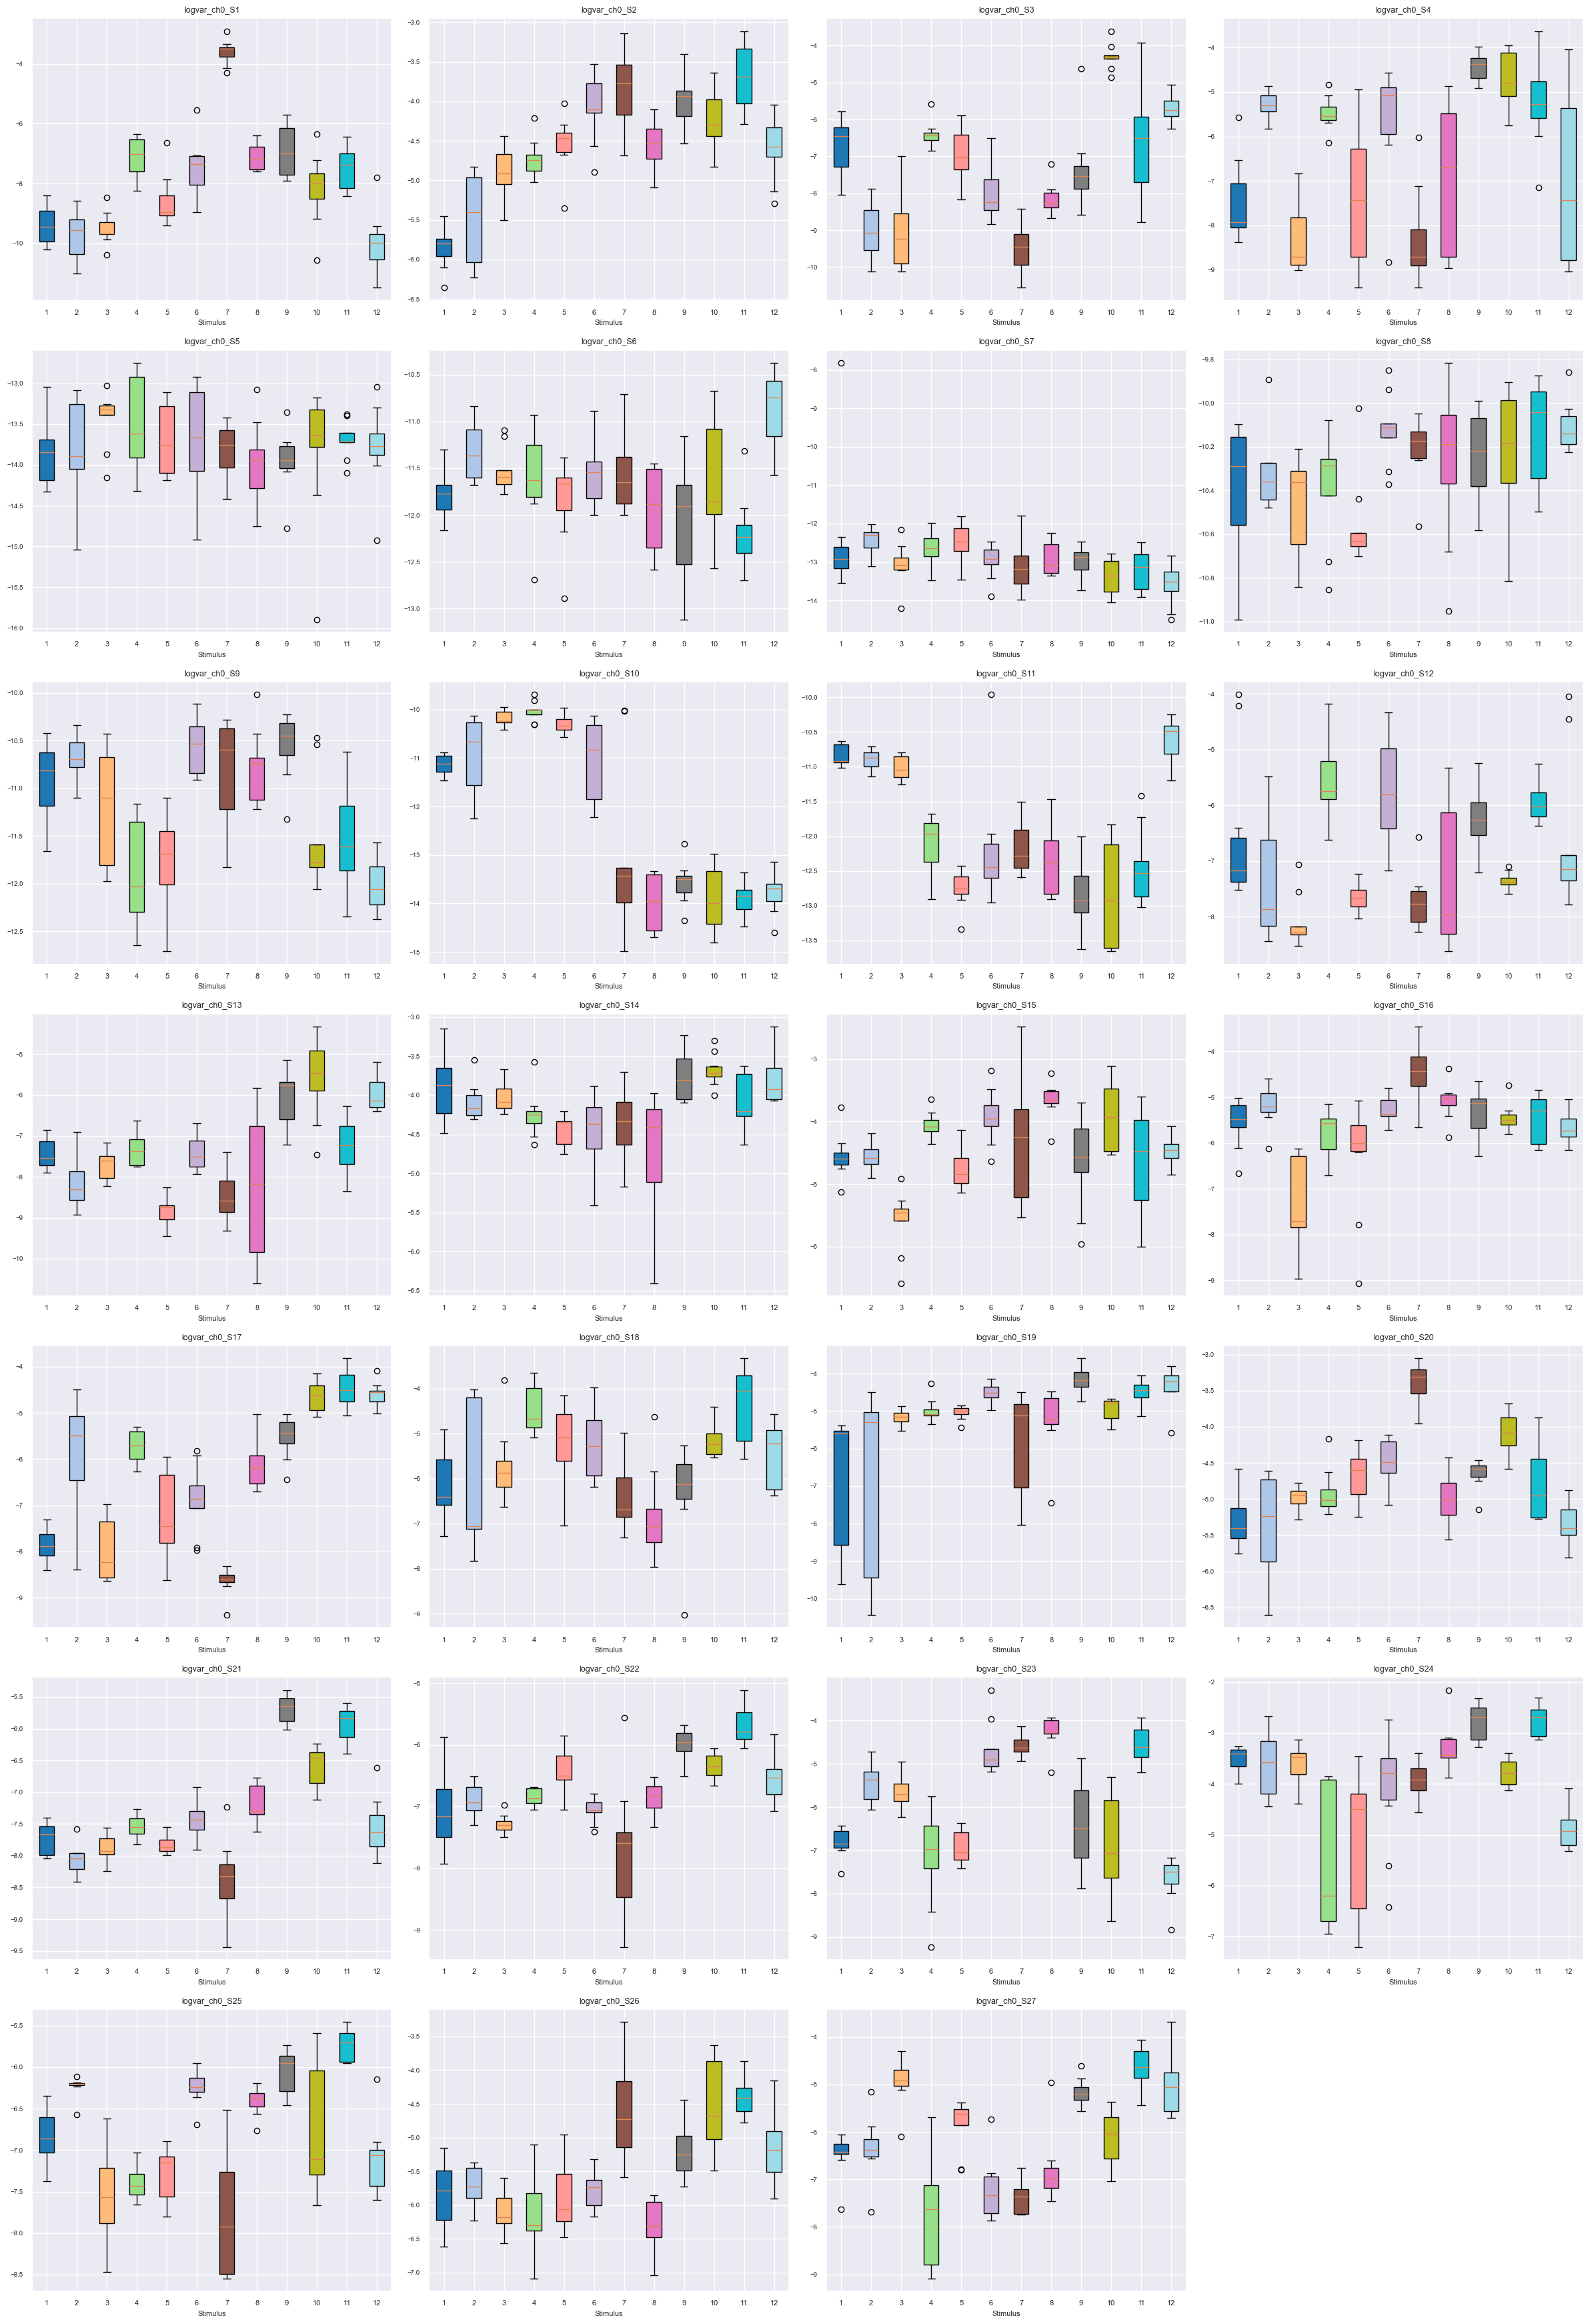

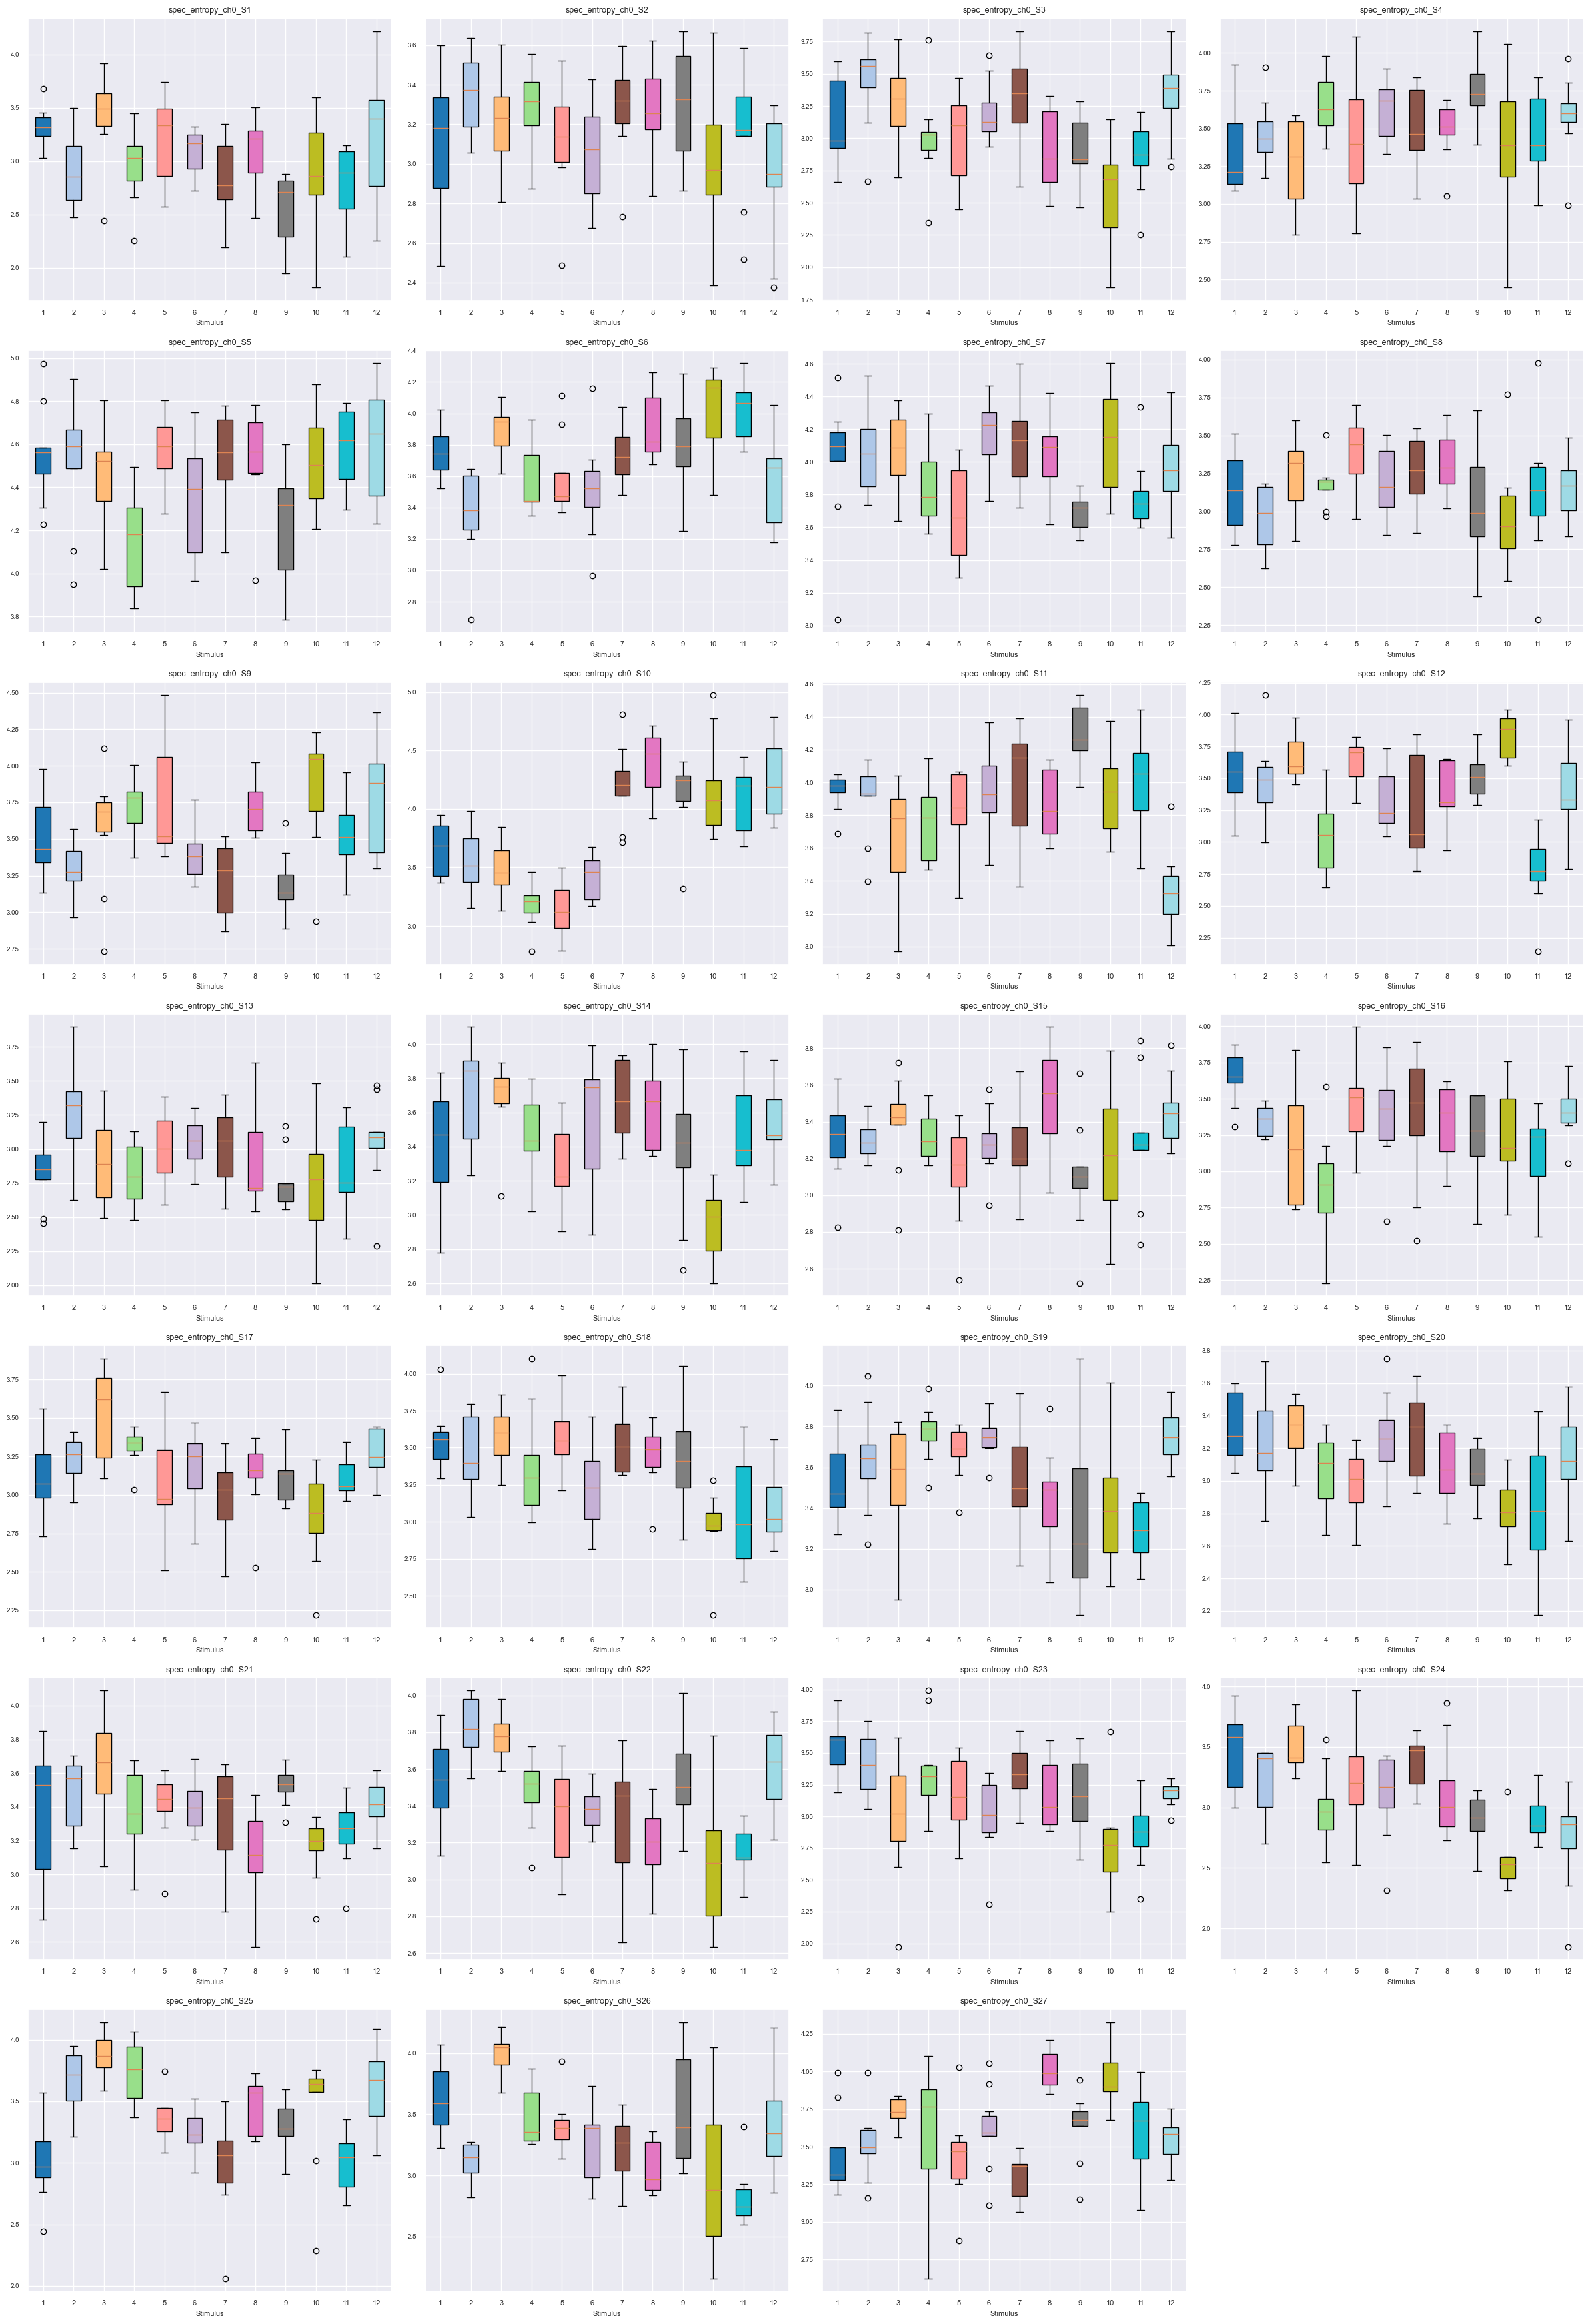

In [36]:

plot_feature_per_subject(all_subjects_data, feature_list, channel=0)

Now we are going to try classifying by training on 26 subjects and then testing it on only one subject.

In [37]:
#Train on subjects S1 to S26, test on S27
X_train_sub = []
y_train_sub = []
for i in range(len(all_subjects_data)-1):
    X = all_subjects_data[f'S{i+1}']['X']
    y = all_subjects_data[f'S{i+1}']['y']
    X_train_sub.append(X)
    y_train_sub.append(y)
    print(f"S{i+1} -> X shape: {X.shape}, y shape: {y.shape}")
X_train_sub = np.concatenate(X_train_sub, axis=0)
y_train_sub = np.concatenate(y_train_sub, axis=0)
print("Final training set shape:", X_train_sub.shape, y_train_sub.shape)

X_test_sub = all_subjects_data[f'S{27}']['X']
y_test_sub = all_subjects_data[f'S{27}']['y']

S1 -> X shape: (108, 50), y shape: (108,)
S2 -> X shape: (113, 50), y shape: (113,)
S3 -> X shape: (106, 50), y shape: (106,)
S4 -> X shape: (101, 50), y shape: (101,)
S5 -> X shape: (107, 50), y shape: (107,)
S6 -> X shape: (105, 50), y shape: (105,)
S7 -> X shape: (108, 50), y shape: (108,)
S8 -> X shape: (103, 50), y shape: (103,)
S9 -> X shape: (109, 50), y shape: (109,)
S10 -> X shape: (110, 50), y shape: (110,)
S11 -> X shape: (106, 50), y shape: (106,)
S12 -> X shape: (110, 50), y shape: (110,)
S13 -> X shape: (110, 50), y shape: (110,)
S14 -> X shape: (107, 50), y shape: (107,)
S15 -> X shape: (108, 50), y shape: (108,)
S16 -> X shape: (103, 50), y shape: (103,)
S17 -> X shape: (108, 50), y shape: (108,)
S18 -> X shape: (104, 50), y shape: (104,)
S19 -> X shape: (106, 50), y shape: (106,)
S20 -> X shape: (103, 50), y shape: (103,)
S21 -> X shape: (107, 50), y shape: (107,)
S22 -> X shape: (109, 50), y shape: (109,)
S23 -> X shape: (110, 50), y shape: (110,)
S24 -> X shape: (108

In [38]:
# scaling
X_train_sub_z = scaler.fit_transform(X_train_sub)   
X_test_sub_z  = scaler.transform(X_test_sub)

#grid search for hyperparameters
print("\n WAIT, performing GridSearchCV...")
grid.fit(X_train_sub_z, y_train_sub)

print("\nBest hyperparameters:", grid.best_params_)
print("Best CV score (weighted F1):", grid.best_score_)


 WAIT, performing GridSearchCV...

Best hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 45}
Best CV score (weighted F1): 0.29222541139302965


In [39]:
#using the best model found
gb_sub = grid.best_estimator_
gb_sub.fit(X_train_sub_z, y_train_sub)

# evaluate on S27
y_pred_sub = gb_sub.predict(X_test_sub_z)

# evaluation of performance of the model
test_accuracy_sub = accuracy_score(y_test_sub, y_pred_sub)
test_f1_sub = f1_score(y_test_sub, y_pred_sub, average="weighted")

print("\nFINAL TEST PERFORMANCE ON SUBJECT 27")
print("Test Accuracy: {:.4f}".format(test_accuracy_sub))
print("Test Weighted F1: {:.4f}".format(test_f1_sub))



FINAL TEST PERFORMANCE ON SUBJECT 27
Test Accuracy: 0.1835
Test Weighted F1: 0.1203


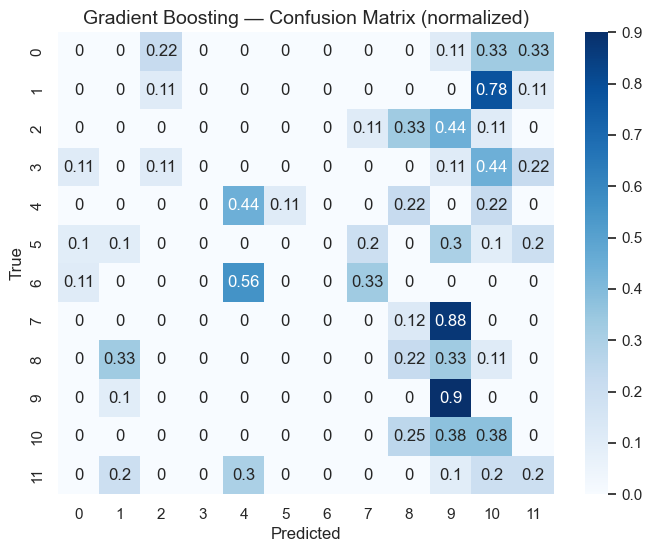

In [40]:
cm = confusion_matrix(y_test_sub, y_pred_sub, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")#, fmt=".2f")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Gradient Boosting — Confusion Matrix (normalized)", fontsize=14)
plt.show()

In [41]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
X_sub = []
y_sub = []
groups = []
for i in range(len(all_subjects_data)):
    X = all_subjects_data[f'S{i+1}']['X']
    y = all_subjects_data[f'S{i+1}']['y']
    groups.append(np.full(X.shape[0], i+1))
    X_sub.append(X)
    y_sub.append(y)
    print(f"S{i+1} -> X shape: {X.shape}, y shape: {y.shape}")
X_sub = np.concatenate(X_sub, axis=0)
y_sub = np.concatenate(y_sub, axis=0)
groups = np.concatenate(groups, axis=0)


S1 -> X shape: (108, 50), y shape: (108,)
S2 -> X shape: (113, 50), y shape: (113,)
S3 -> X shape: (106, 50), y shape: (106,)
S4 -> X shape: (101, 50), y shape: (101,)
S5 -> X shape: (107, 50), y shape: (107,)
S6 -> X shape: (105, 50), y shape: (105,)
S7 -> X shape: (108, 50), y shape: (108,)
S8 -> X shape: (103, 50), y shape: (103,)
S9 -> X shape: (109, 50), y shape: (109,)
S10 -> X shape: (110, 50), y shape: (110,)
S11 -> X shape: (106, 50), y shape: (106,)
S12 -> X shape: (110, 50), y shape: (110,)
S13 -> X shape: (110, 50), y shape: (110,)
S14 -> X shape: (107, 50), y shape: (107,)
S15 -> X shape: (108, 50), y shape: (108,)
S16 -> X shape: (103, 50), y shape: (103,)
S17 -> X shape: (108, 50), y shape: (108,)
S18 -> X shape: (104, 50), y shape: (104,)
S19 -> X shape: (106, 50), y shape: (106,)
S20 -> X shape: (103, 50), y shape: (103,)
S21 -> X shape: (107, 50), y shape: (107,)
S22 -> X shape: (109, 50), y shape: (109,)
S23 -> X shape: (110, 50), y shape: (110,)
S24 -> X shape: (108

In [42]:
#Leaving one subject out cross-validation
logo = LeaveOneGroupOut()
logo.get_n_splits(X_sub, y_sub, groups)
f1_scores = []
accuracies = []
all_y_true = []
all_y_pred = []

for i, (train_index, test_index) in enumerate(logo.split(X_sub, y_sub, groups)):
    X_train_sub, X_test_sub = X_sub[train_index], X_sub[test_index]
    y_train_sub, y_test_sub = y_sub[train_index], y_sub[test_index]
    print(f"LOSO Iteration {i+1}: Train shape: {X_train_sub.shape}, Test shape: {X_test_sub.shape}")
    # scaling
    X_train_sub_z = scaler.fit_transform(X_train_sub)   
    X_test_sub_z  = scaler.transform(X_test_sub)
    #gb
    gb_sub = GradientBoostingClassifier()
    gb_sub.fit(X_train_sub_z, y_train_sub)
    # evaluate on test set
    y_pred_sub = gb_sub.predict(X_test_sub_z)
    all_y_true.extend(y_test_sub)
    all_y_pred.extend(y_pred_sub)
    # evaluation of performance of the model
    test_accuracy_sub = accuracy_score(y_test_sub, y_pred_sub)
    test_f1_sub = f1_score(y_test_sub, y_pred_sub, average="weighted")
    print(f"Subject {i+1} — Test Accuracy: {test_accuracy_sub:.4f}, Test Weighted F1: {test_f1_sub:.4f}\n")
    f1_scores.append(test_f1_sub)
    accuracies.append(test_accuracy_sub)
mean_f1 = np.mean(f1_scores)
mean_accuracy = np.mean(accuracies)
print(f"LOSO Cross-Validation — Mean Test Accuracy: {mean_accuracy:.4f}, Mean Weighted F1: {mean_f1:.4f}")


LOSO Iteration 1: Train shape: (2775, 50), Test shape: (108, 50)
Subject 1 — Test Accuracy: 0.3426, Test Weighted F1: 0.2910

LOSO Iteration 2: Train shape: (2770, 50), Test shape: (113, 50)
Subject 2 — Test Accuracy: 0.1062, Test Weighted F1: 0.0474

LOSO Iteration 3: Train shape: (2777, 50), Test shape: (106, 50)
Subject 3 — Test Accuracy: 0.3774, Test Weighted F1: 0.3479

LOSO Iteration 4: Train shape: (2782, 50), Test shape: (101, 50)
Subject 4 — Test Accuracy: 0.2475, Test Weighted F1: 0.2047

LOSO Iteration 5: Train shape: (2776, 50), Test shape: (107, 50)
Subject 5 — Test Accuracy: 0.2243, Test Weighted F1: 0.2003

LOSO Iteration 6: Train shape: (2778, 50), Test shape: (105, 50)
Subject 6 — Test Accuracy: 0.2381, Test Weighted F1: 0.1837

LOSO Iteration 7: Train shape: (2775, 50), Test shape: (108, 50)
Subject 7 — Test Accuracy: 0.2407, Test Weighted F1: 0.2035

LOSO Iteration 8: Train shape: (2780, 50), Test shape: (103, 50)
Subject 8 — Test Accuracy: 0.2524, Test Weighted F1: 

In [43]:
std_f1 = np.std(f1_scores)
std_accuracy = np.std(accuracies)
print("Std F1 in LOSO:", std_f1)
print("Std accuracy in LOSO:", std_accuracy)
print("Max accuracy in LOSO:", np.max(accuracies))
print("Min accuracy in LOSO:", np.min(accuracies))

print(len(accuracies))
for i in range (len(accuracies)):
    print(f"Subject {i+1} accuracy: {accuracies[i]:.4f}")

Std F1 in LOSO: 0.10357149567218445
Std accuracy in LOSO: 0.09830439397098834
Max accuracy in LOSO: 0.5370370370370371
Min accuracy in LOSO: 0.10619469026548672
27
Subject 1 accuracy: 0.3426
Subject 2 accuracy: 0.1062
Subject 3 accuracy: 0.3774
Subject 4 accuracy: 0.2475
Subject 5 accuracy: 0.2243
Subject 6 accuracy: 0.2381
Subject 7 accuracy: 0.2407
Subject 8 accuracy: 0.2524
Subject 9 accuracy: 0.1193
Subject 10 accuracy: 0.3182
Subject 11 accuracy: 0.1604
Subject 12 accuracy: 0.2545
Subject 13 accuracy: 0.2182
Subject 14 accuracy: 0.2804
Subject 15 accuracy: 0.2593
Subject 16 accuracy: 0.3010
Subject 17 accuracy: 0.5370
Subject 18 accuracy: 0.3173
Subject 19 accuracy: 0.1604
Subject 20 accuracy: 0.3301
Subject 21 accuracy: 0.1589
Subject 22 accuracy: 0.2018
Subject 23 accuracy: 0.3000
Subject 24 accuracy: 0.1944
Subject 25 accuracy: 0.4466
Subject 26 accuracy: 0.4216
Subject 27 accuracy: 0.2018


27 27


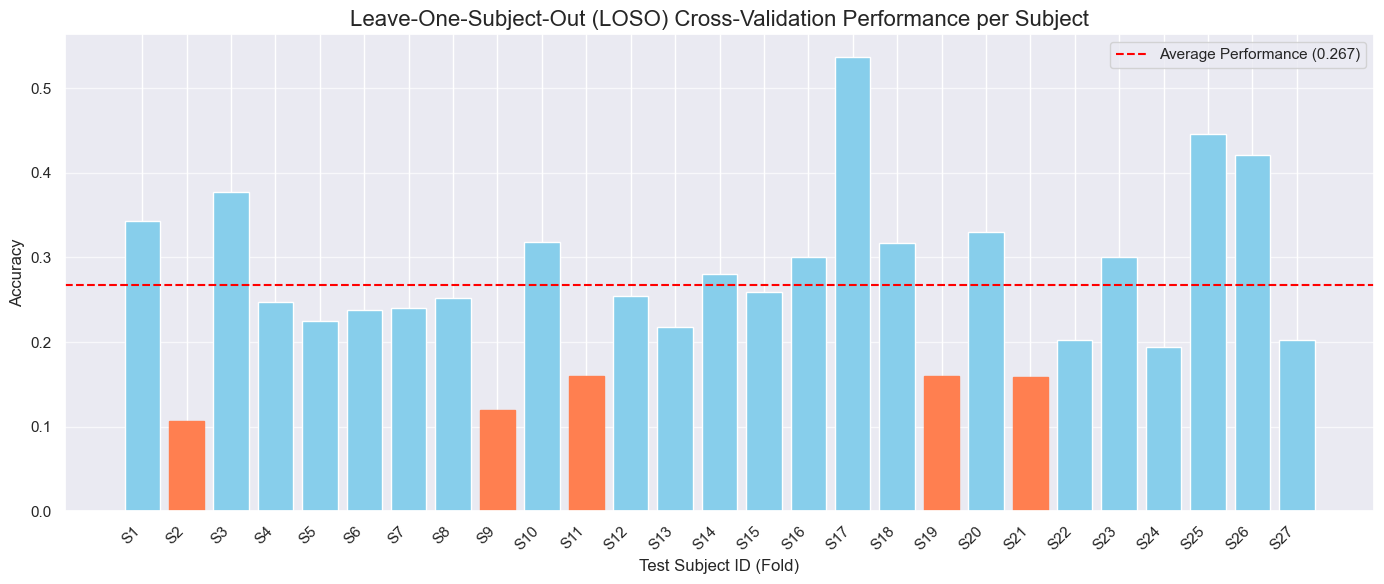

In [44]:

# subjects in fold order (S1..S27)
subject_ids = [f"S{i+1}" for i in range(len(accuracies))]

print(len(accuracies), len(subject_ids))

data = pd.DataFrame({
    'Subject': subject_ids,
    'Accuracy': accuracies
})

plt.figure(figsize=(14, 6))

bars = plt.bar(
    data['Subject'],
    data['Accuracy'],
    color='skyblue'
)

# mean line
plt.axhline(
    mean_accuracy,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Average Performance ({mean_accuracy:.3f})'
)

# outliers (below mean - 1 std)
std_dev = np.std(accuracies)
outlier_threshold = mean_accuracy - std_dev

for bar, score in zip(bars, accuracies):
    if score < outlier_threshold:
        bar.set_color('coral')

plt.title('Leave-One-Subject-Out (LOSO) Cross-Validation Performance per Subject', fontsize=16)
plt.xlabel('Test Subject ID (Fold)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()


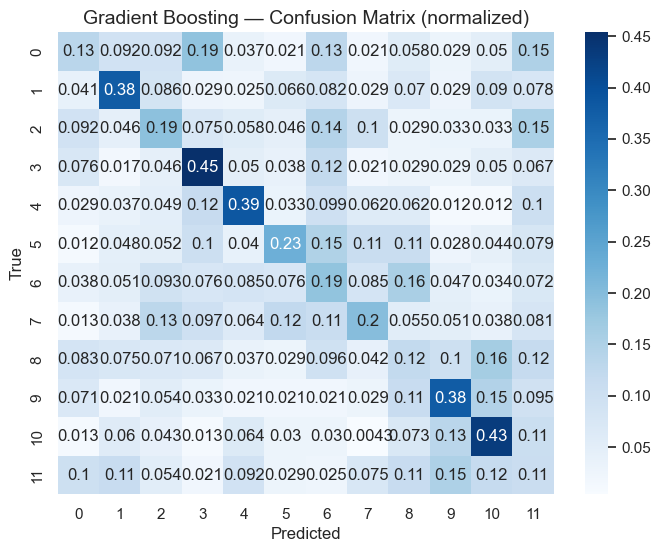

In [45]:
#complexive confusion matrix for LOSO
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_true, all_y_pred, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Gradient Boosting — Confusion Matrix (normalized)", fontsize=14)
plt.show()

Now let's analyze how the performance of the model changes depending on how many subjects we give in training. For testing we will still use subject 27.

In [46]:
#testing on S27 while progressively adding subjects to the training set
X_test_sub = all_subjects_data[f'S{27}']['X']
y_test_sub = all_subjects_data[f'S{27}']['y']
X_train_app = []
y_train_app = []
accuracies = []
f1_scores = []
for i in range(len(all_subjects_data)-1):
    X = all_subjects_data[f'S{i+1}']['X']
    y = all_subjects_data[f'S{i+1}']['y']
    X_train_app.append(X)
    y_train_app.append(y)
    X_train_sub = np.concatenate(X_train_app, axis=0)
    y_train_sub = np.concatenate(y_train_app, axis=0)
    X_train_sub_z = scaler.fit_transform(X_train_sub)   
    X_test_sub_z  = scaler.transform(X_test_sub)
    #gb
    gb_sub = GradientBoostingClassifier()
    gb_sub.fit(X_train_sub_z, y_train_sub)
    # evaluate on test set
    y_pred_sub = gb_sub.predict(X_test_sub_z)
    accuracies.append(accuracy_score(y_test_sub, y_pred_sub))
    f1_scores.append(f1_score(y_test_sub, y_pred_sub, average='weighted'))
    print(f"Training till S{i+1} — Test Accuracy on S27: {accuracies[-1]:.4f}, Test Weighted F1: {f1_scores[-1]:.4f}")


Training till S1 — Test Accuracy on S27: 0.0459, Test Weighted F1: 0.0190
Training till S2 — Test Accuracy on S27: 0.0550, Test Weighted F1: 0.0553
Training till S3 — Test Accuracy on S27: 0.0917, Test Weighted F1: 0.0744
Training till S4 — Test Accuracy on S27: 0.1560, Test Weighted F1: 0.1180
Training till S5 — Test Accuracy on S27: 0.1468, Test Weighted F1: 0.0914
Training till S6 — Test Accuracy on S27: 0.1468, Test Weighted F1: 0.0815
Training till S7 — Test Accuracy on S27: 0.1468, Test Weighted F1: 0.0979
Training till S8 — Test Accuracy on S27: 0.1560, Test Weighted F1: 0.1224
Training till S9 — Test Accuracy on S27: 0.1927, Test Weighted F1: 0.1423
Training till S10 — Test Accuracy on S27: 0.1468, Test Weighted F1: 0.1126
Training till S11 — Test Accuracy on S27: 0.1376, Test Weighted F1: 0.1099
Training till S12 — Test Accuracy on S27: 0.1835, Test Weighted F1: 0.1191
Training till S13 — Test Accuracy on S27: 0.1743, Test Weighted F1: 0.0975
Training till S14 — Test Accuracy 

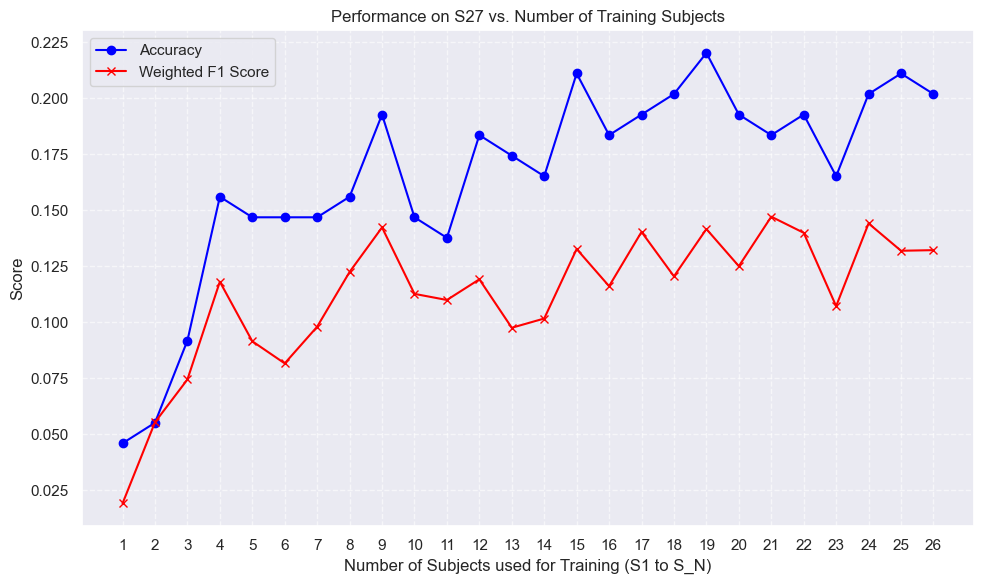

In [47]:
#how accuracy and f1-score changes while adding subjects to the training set
subjects_count = np.arange(1, len(accuracies) + 1)

plt.figure(figsize=(10, 6))

plt.plot(subjects_count, accuracies, marker='o', label='Accuracy', color='blue')

plt.plot(subjects_count, f1_scores, marker='x', label='Weighted F1 Score', color='red')

plt.title('Performance on S27 vs. Number of Training Subjects')
plt.xlabel('Number of Subjects used for Training (S1 to S_N)')
plt.ylabel('Score')
plt.xticks(subjects_count) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Part 3: Regression for joint angles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #sets the matplotlib style to seaborn style

from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch
import pandas as pd
import math

np.random.seed(42)

In [ ]:
db8_path = "S1_E1_A1.mat"
mat = loadmat(db8_path)

mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'subject', 'exercise', 'emg', 'acc', 'gyro', 'mag', 'glove', 'stimulus', 'repetition', 'restimulus', 'rerepetition'])

In [ ]:
emg_raw   = mat["emg"]  
glove_raw = mat["glove"]

print("EMG shape:", emg_raw.shape)
print("Angles shape:", glove_raw.shape)

EMG shape: (2292526, 16)
Angles shape: (2292526, 18)


In [ ]:
joint_indices = [2, 5, 7, 10, 13]

angles = glove_raw[:, joint_indices]
print("Selected angles shape:", angles.shape)  # (N, 5)

Selected angles shape: (2292526, 5)


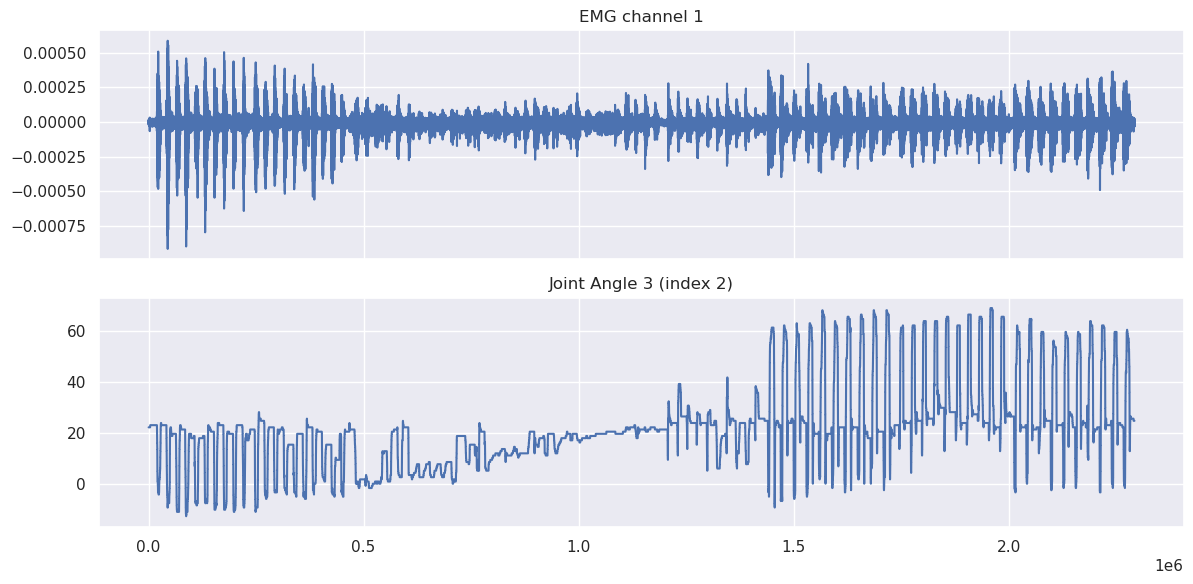

In [ ]:
import matplotlib.pyplot as plt

time = np.arange(angles.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time, emg_raw[:, 0])
axes[0].set_title("EMG channel 1")

axes[1].plot(time, angles[:, 0])
axes[1].set_title("Joint Angle 3 (index 2)")

plt.tight_layout()
plt.show()

In [ ]:
emg = emg_raw - np.mean(emg_raw, axis=0)

In [ ]:
from scipy.signal import butter, filtfilt

def highpass_filter(data, fs, cutoff=20.0, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='highpass')
    return filtfilt(b, a, data, axis=0)

In [ ]:
# Step: Preprocess EMG
emg_demeaned = emg_raw - emg_raw.mean(axis=0)
emg_hp = highpass_filter(emg_demeaned, fs=2000)

print(emg_hp.shape)

(2292526, 16)


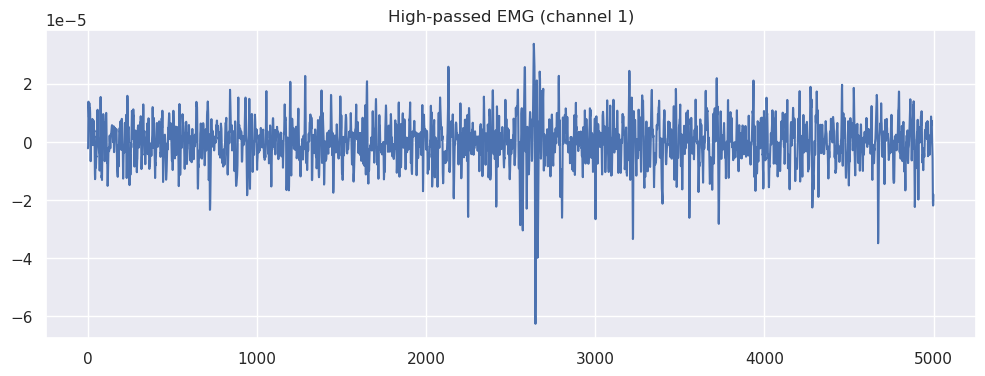

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(emg_hp[:5000, 0])
plt.title("High-passed EMG (channel 1)")
plt.show()


Split

Time-series splitting

Unlike Part 1 and 2, the data in Part 3 is a continuous EMG–kinematics recording.
Because consecutive samples are highly correlated, randomly shuffling the data would cause temporal leakage, where the model sees future information during training.

To avoid this, we employed a chronological split:

Train: first 70% of the time-series

Validation: next 15%

Test: final 15%

This ensures that the model is always evaluated on future unseen time periods, which reflects the real-world setting of predicting joint angles from past EMG activity.

In [ ]:
N = emg_hp.shape[0]
train_end = int(0.70 * N)
val_end   = int(0.85 * N)

X_train_raw = emg_hp[:train_end]
y_train     = angles[:train_end]

X_val_raw   = emg_hp[train_end:val_end]
y_val       = angles[train_end:val_end]

X_test_raw  = emg_hp[val_end:]
y_test      = angles[val_end:]

print(X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

(1604768, 16) (343879, 16) (343879, 16)


Sliding window

EMG features typically require a short window (150–250 ms) to stabilize amplitude-based estimators such as RMS, MAV, WL and ZC.
A 200 ms window is widely used in EMG-based regression.
The step size (50 ms) provides an output frequency of 20 Hz, sufficient for smooth prosthetic control without producing redundant overlap.

In [ ]:
def sliding_window(emg_signal, angles_signal, window_size, step_size):
    """
    emg_signal: (N, n_channels)
    angles_signal: (N, 5)
    window_size: int (samples)
    step_size: int (samples)
    returns:
        X_windows: list of arrays (window_size, n_channels)
        Y_targets: array (n_windows, 5)
    """
    X_windows = []
    Y_targets = []

    N = emg_signal.shape[0]
    start = 0

    while start + window_size <= N:
        end = start + window_size
        X_windows.append(emg_signal[start:end])
        # pick target at END of the window (standard choice)
        Y_targets.append(angles_signal[end - 1])
        start += step_size

    return np.array(X_windows), np.array(Y_targets)

In [ ]:
fs = 2000
window_size = int(0.2 * fs)   # 400
step_size   = int(0.05 * fs)  # 100

X_train_w, y_train_w = sliding_window(X_train_raw, y_train, window_size, step_size)
X_val_w,   y_val_w   = sliding_window(X_val_raw, y_val, window_size, step_size)
X_test_w,  y_test_w  = sliding_window(X_test_raw, y_test, window_size, step_size)

print("Train windows:", X_train_w.shape, y_train_w.shape)
print("Val windows:", X_val_w.shape, y_val_w.shape)
print("Test windows:", X_test_w.shape, y_test_w.shape)

Train windows: (16044, 400, 16) (16044, 5)
Val windows: (3435, 400, 16) (3435, 5)
Test windows: (3435, 400, 16) (3435, 5)


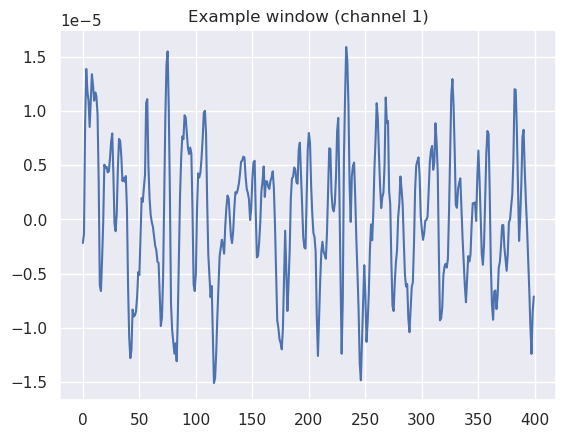

Target joint angles: [22.320053 33.585068 21.458416 20.117695 22.531336]


In [ ]:
plt.plot(X_train_w[0][:,0])
plt.title("Example window (channel 1)")
plt.show()

print("Target joint angles:", y_train_w[0])

Feature extraction

In [ ]:
def extract_features_from_window(window, feature_list):
    """
    window: shape (window_size, n_channels)
    returns: feature vector (len(feature_list) * n_channels,)
    """
    feats = []
    for feat_func in feature_list:
        feat_val = feat_func(window)  # shape (n_channels,)
        feats.append(feat_val)
    return np.concatenate(feats, axis=0)

In [ ]:
def build_feature_matrix(X_windows, feature_list):
    all_features = []
    for w in X_windows:
        fv = extract_features_from_window(w, feature_list)
        all_features.append(fv)
    return np.array(all_features)

In [ ]:
import numpy as np
from scipy.signal import welch

# 1. RMS
def rms(x):
    # x: (window_size, n_channels)
    return np.sqrt(np.mean(x**2, axis=0))

# 2. Waveform Length (WL)
def wl(x):
    return np.sum(np.abs(np.diff(x, axis=0)), axis=0)

# 3. MAV (Mean Absolute Value)
def mav(x):
    return np.mean(np.abs(x), axis=0)

# 4. Log-variance
def logvar(x):
    return np.log(np.var(x, axis=0) + 1e-8)

# 5. Spectral Entropy
def spec_entropy(x):
    ent = []
    for ch in range(x.shape[1]):
        f, Pxx = welch(x[:, ch])
        Pxx_norm = Pxx / np.sum(Pxx)
        entropy = -np.sum(Pxx_norm * np.log(Pxx_norm + 1e-12))
        ent.append(entropy)
    return np.array(ent)

feature_list = [rms, wl, mav, logvar, spec_entropy]

In [ ]:
X_train_feat = build_feature_matrix(X_train_w, feature_list)
X_val_feat   = build_feature_matrix(X_val_w,   feature_list)
X_test_feat  = build_feature_matrix(X_test_w,  feature_list)

print("Feature matrix shapes:")
print(X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)

Feature matrix shapes:
(16044, 80) (3435, 80) (3435, 80)


In [ ]:
# Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_feat)
X_val_norm   = scaler.transform(X_val_feat)
X_test_norm  = scaler.transform(X_test_feat)

In [ ]:
# Correlation
feature_df = pd.DataFrame(X_train_feat)

corr_matrix = feature_df.corr()
corr_matrix.shape

(80, 80)

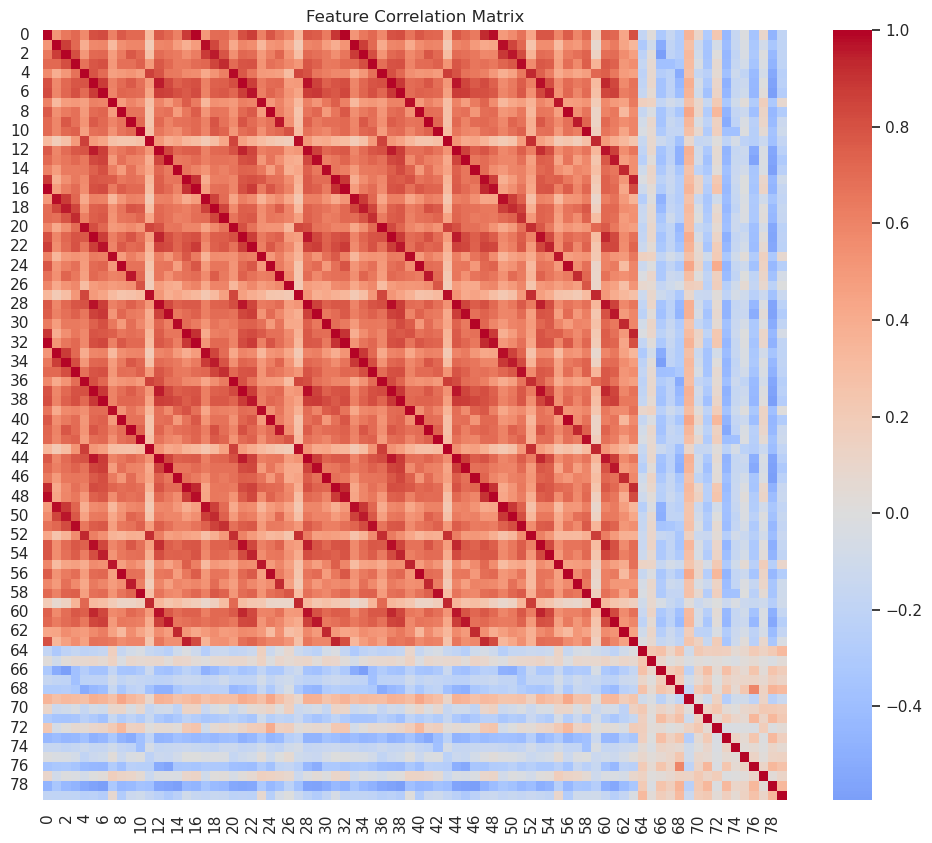

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

1. Strong correlations among amplitude-based features (upper-left block)

RMS, MAV, WL and Log-Variance are all amplitude-related features, so they naturally measure similar properties of the EMG signal.
This leads to high positive correlations between these features across all channels.

2. Block structure every 16 columns/rows

Each block corresponds to one feature computed over all 16 EMG channels.
The repeated diagonal patterns indicate that channels behave similarly across different features, which is expected because muscles often activate together.

3. Spectral entropy (last block) is weakly or negatively correlated with amplitude features

Spectral entropy captures the frequency distribution of the EMG signal rather than its amplitude.
Because of this, it provides complementary information and shows much lower correlation with amplitude-based features.

4. Some redundancy exists among the features

Since many features carry overlapping information, the model may rely on a smaller subset without losing much performance.

Regression

In [ ]:
# Regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gbr_base = GradientBoostingRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

model = MultiOutputRegressor(gbr_base, n_jobs=-1)

In [ ]:
model.fit(X_train_norm, y_train_w)

MultiOutputRegressor(estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                         n_estimators=120,
                                                         random_state=42,
                                                         subsample=0.8),
                     n_jobs=-1)

In [ ]:
y_val_pred  = model.predict(X_val_norm)
y_test_pred = model.predict(X_test_norm)

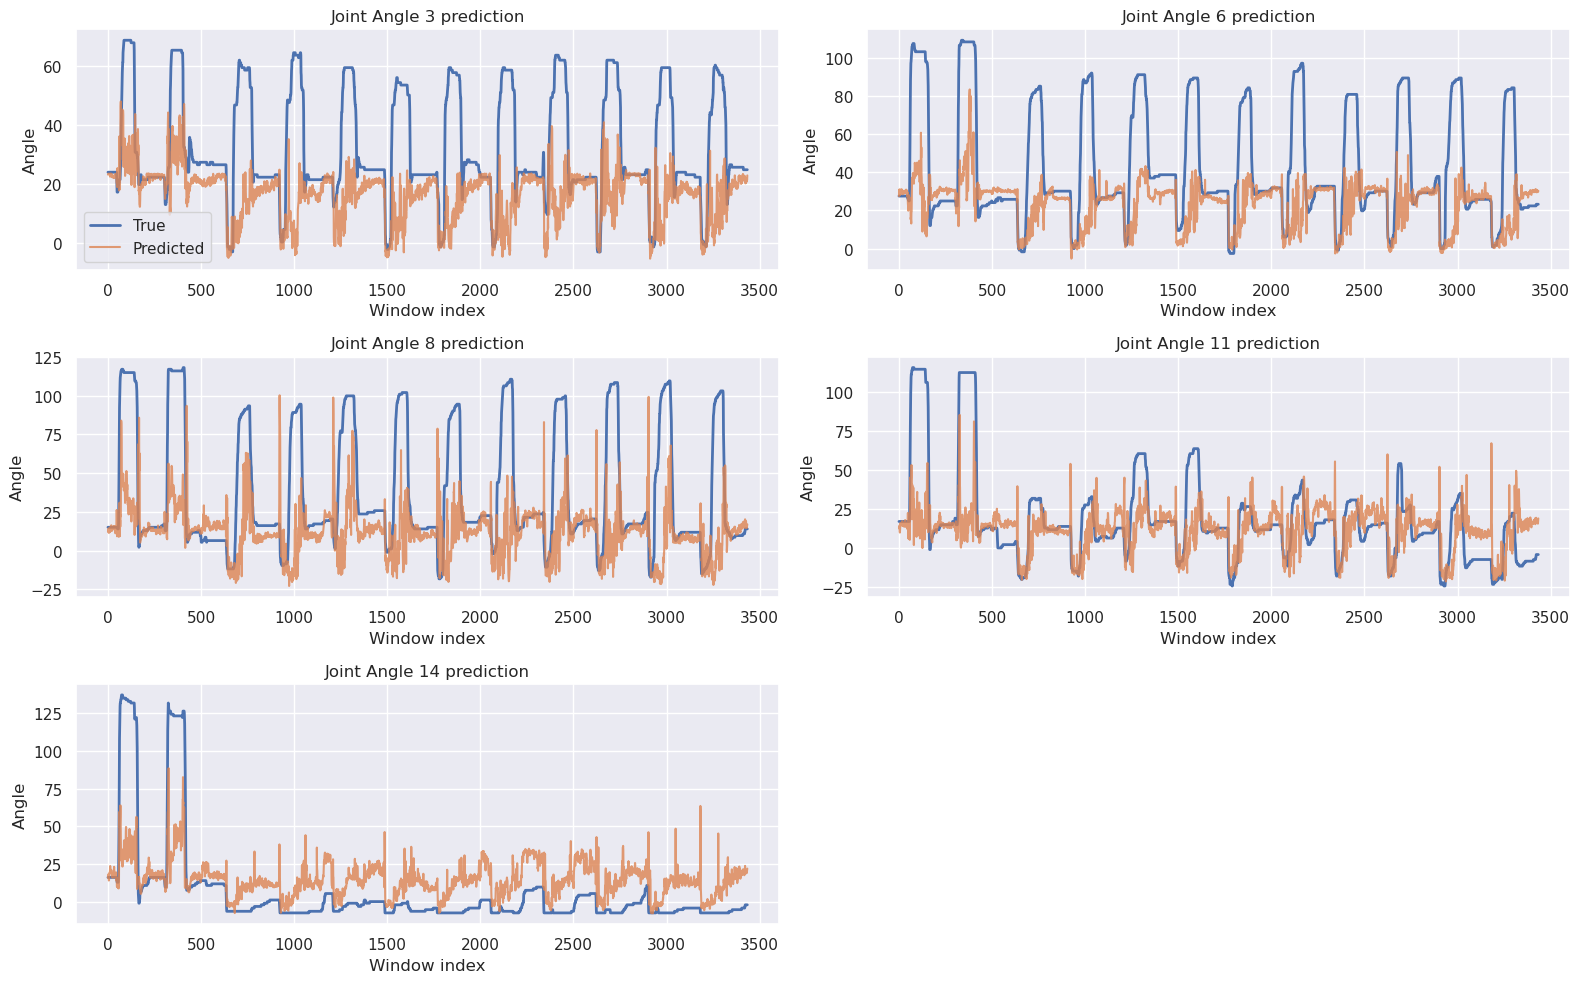

In [ ]:
joint_names = ["Angle 3", "Angle 6", "Angle 8", "Angle 11", "Angle 14"]

plt.figure(figsize=(16, 10))

for i in range(5):
    plt.subplot(3, 2, i+1)  # 3 rows x 2 cols，最后一个空白
    plt.plot(y_test_w[:, i], label="True", linewidth=2)
    plt.plot(y_test_pred[:, i], label="Predicted", alpha=0.8)
    plt.title(f"Joint {joint_names[i]} prediction")
    plt.xlabel("Window index")
    plt.ylabel("Angle")
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

Across all five joints, the model captures the overall timing of the movements but consistently underestimates the amplitude. The predictions are smoother than the ground truth and do not reproduce sharp transitions—an expected limitation of gradient boosting, which learns a static mapping and cannot fully model the fast dynamics of finger motion.

Eval

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_val, rmse_val, r2_val = evaluate_regression(y_val_w, y_val_pred)
mae_test, rmse_test, r2_test = evaluate_regression(y_test_w, y_test_pred)

print("Validation:")
print(" MAE :", mae_val)
print(" RMSE:", rmse_val)
print(" R²  :", r2_val)

print("\nTest:")
print(" MAE :", mae_test)
print(" RMSE:", rmse_test)
print(" R²  :", r2_test)

Validation:
 MAE : 22.621095838896743
 RMSE: 36.661123518583445
 R²  : 0.03735171086350919

Test:
 MAE : 20.535185795731017
 RMSE: 32.99126216388871
 R²  : -0.2665115610173846


These results show that while the model captures the timing of the movements, it fails to accurately predict the magnitude of the joint angles. The negative R² on the test set indicates that the model performs worse than predicting the mean angle, which is expected because gradient boosting cannot model the fast, nonlinear finger dynamics or the sharp transitions present in the true kinematics.

Nevertheless, the model still extracts meaningful motor information from EMG—reflected in the clear periodicity of the predicted signals—but its precision is limited. This level of performance is typical for tree-based baselines in EMG-to-kinematics regression.

Across angle:

The regression performance is not uniform across finger angles: some joints are predicted more reliably than others. Differences arise from unequal EMG visibility of the muscles controlling each finger, varying movement amplitudes, and joint-specific biomechanics that tree-based regressors cannot fully model.